# Retirement Readiness — Exploratory Data Analysis

## Project Overview

This notebook presents the exploratory data analysis (EDA) for the **Retirement Readiness Predictor**, a machine learning project that estimates a customer's **Expected_Retirement_Fund** using demographic, financial, and behavioral information.

The analysis is performed on a synthetic dataset containing **30,000 pre-retirement customers** and **32 features** designed to simulate realistic retirement planning scenarios.

The objective of this notebook is to understand the dataset, evaluate its suitability for predictive modeling, identify potential data quality issues, and uncover business insights that will guide feature engineering, preprocessing, and model development.

---

## Objectives of the Exploratory Data Analysis

Before building any machine learning model, it is essential to understand the data and verify that it supports the intended prediction task.

This exploratory analysis focuses on four objectives:

1. **Assess data quality** by examining missing values, duplicate records, outliers, feature distributions, and overall dataset integrity.

2. **Identify machine learning risks** such as target leakage, multicollinearity, redundant variables, and other issues that could produce misleading model performance.

3. **Understand the relationships** between customer characteristics and the expected retirement fund in order to identify meaningful predictors and potential feature engineering opportunities.

4. **Generate business insights** that explain how customer demographics, financial behaviour, and saving patterns influence long-term retirement readiness.

The findings from this notebook directly inform the preprocessing pipeline and the modeling strategy developed in the subsequent stages of the project.

---

# Key Findings

| # | Finding | Why It Matters |
|---|---------|----------------|
| 1 | **Funding_Gap**, **Readiness_Score**, and **RetirementReady** are deterministic transformations of the prediction target. | These variables introduce **target leakage** and must be excluded from model training while remaining valuable business KPIs. |
| 2 | The dataset represents a single, consistent customer population consisting entirely of **pre-retirement individuals**. | Every observation corresponds to the same prediction problem, making the regression task well defined and easier to interpret. |
| 3 | Multicollinearity has been substantially reduced, with only two feature pairs exhibiting correlations above \|r\| = 0.90. | Linear models can be trained with minimal concern for redundant information. |
| 4 | Wealth accumulation and saving behaviour are stronger predictors of retirement outcomes than age alone. | Financial variables should be the primary focus during feature engineering and model development. |
| 5 | The relationship between age and the target is strongly non-linear rather than linear. | Tree-based algorithms or engineered non-linear features are likely to outperform simple linear models. |
| 6 | Missing values are sparse and consistent with a Missing Completely At Random (MCAR) mechanism. | Standard imputation techniques are appropriate and unlikely to introduce systematic bias. |
| 7 | A small number of duplicate customer records exist. | Duplicate observations should be removed before creating training and testing datasets to prevent data leakage. |

---

## About the Dataset

The dataset used throughout this notebook is synthetic and was created specifically for educational purposes and machine learning experimentation.

Although the financial relationships were designed to resemble realistic retirement planning behaviour, the dataset should **not** be interpreted as representing the true characteristics of any real customer population.

Where appropriate, this notebook distinguishes between:

- relationships intentionally introduced during data generation,
- patterns discovered through exploratory analysis, and
- insights that are meaningful for the machine learning pipeline.

This distinction is important because one of the primary objectives of EDA is understanding **how the data was generated**, **what information it contains**, and **which patterns can be trusted when developing predictive models.**


## Notebook Roadmap

This notebook is organized into the following sections:

1. Dataset Overview
2. Data Quality Assessment
3. Target Analysis
4. Feature Analysis
5. Correlation Analysis
6. Business Insights
7. Feature Engineering Opportunities
8. Machine Learning Readiness
9. Executive Summary


## Notebook Conventions

To keep the notebook consistent and reproducible:

- All static figures are automatically exported to the `figures/` directory at 300 DPI for use in the project documentation.
- A consistent visualization style and color palette are used throughout the notebook.
- Interactive Plotly visualizations are optional and are intended only for local exploration. Every key finding is supported by a static Matplotlib/Seaborn figure that renders correctly on GitHub.


In [4]:
# --- Core libraries -------------------------------------------------------
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# Plotly is optional. It adds interactive views when running locally, but GitHub's
# notebook renderer cannot display it, so nothing in this analysis depends on it.
try:
    import plotly.express as px
    import plotly.io as pio
    pio.templates.default = "plotly_white"
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False

# --- Display options ------------------------------------------------------
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

# --- Consistent visual identity ------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 100,
    "savefig.dpi": 300,          # high-resolution exports for GitHub / decks
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.edgecolor": "#CCCCCC",
    "grid.color": "#E8E8E8",
    "font.size": 10,
})

# A small named palette keeps colour meaning stable across the whole notebook.
NAVY = "#1F3B73"     # primary series
TEAL = "#2A9D8F"     # positive / "good" outcomes
AMBER = "#E9A13B"    # highlight / secondary series
CORAL = "#E76F51"    # warning / negative outcomes
SLATE = "#6C757D"    # annotation text
SEQUENTIAL_CMAP = "mako"

# --- Figure export --------------------------------------------------------
FIGURES_DIR = globals().get("FIGURES_DIR", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

def save_fig(filename):
    "Save the current figure to figures/<filename>.png at 300 DPI."
    plt.tight_layout()
    full_path = os.path.join(FIGURES_DIR, f"{filename}.png")
    plt.savefig(full_path, dpi=300, bbox_inches="tight", facecolor="white")

print("pandas     ", pd.__version__)
print("numpy      ", np.__version__)
print("matplotlib ", matplotlib.__version__)
print("seaborn    ", sns.__version__)
print("plotly     ", "available" if HAS_PLOTLY else "not installed (static figures only)")

pandas      2.2.2
numpy       2.0.2
matplotlib  3.10.0
seaborn     0.13.2
plotly      available


In [5]:
# Load the dataset. Everything downstream reads from `df`.
# No cell modifies `df` in place, so the notebook can be re-run top to bottom safely.
DATA_PATH = "/content/retirement_dataset_v2.csv"
df = pd.read_csv(DATA_PATH)

# Naming the target once, here, means later cells never hard-code the string.
# If the target ever changes, this is the only line that needs editing.
TARGET = "Expected_Retirement_Fund"

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Target: {TARGET}")

Loaded 30,000 rows x 32 columns
Target: Expected_Retirement_Fund


# 1. Dataset Overview

### What are we doing?

We start by establishing exactly what is in the dataset. The goal is to understand its size, structure, feature types, and basic quality before interpreting relationships.


In [6]:
# --- Dimensions and memory ------------------------------------------------
n_rows, n_cols = df.shape
memory_mb = df.memory_usage(deep=True).sum() / 1024**2

n_numeric = df.select_dtypes(include=np.number).shape[1]
n_categorical = df.select_dtypes(include="object").shape[1]

print(f"Rows:                {n_rows:,}")
print(f"Columns:             {n_cols}")
print(f"Cells:               {n_rows * n_cols:,}")
print(f"Memory (deep):       {memory_mb:.2f} MB")
print(f"Numeric columns:     {n_numeric}")
print(f"Categorical columns: {n_categorical}")

Rows:                30,000
Columns:             32
Cells:               960,000
Memory (deep):       16.68 MB
Numeric columns:     25
Categorical columns: 7


In [7]:
# --- A compact structural profile: type, cardinality, missingness, example -
# Building this as an explicit dict keeps each column of the summary readable,
# rather than chaining several transformations together.
overview = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_unique": df.nunique(),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "example": df.iloc[0].values,
})
overview.index.name = "column"
overview

,dtype,n_unique,n_missing,pct_missing,example
column,,,,,
CustomerID,int64,29850,0,0.0000,1
Age,int64,48,0,0.0000,36
Gender,object,4,0,0.0000,Female
Education,object,5,0,0.0000,Master
MaritalStatus,object,4,0,0.0000,Single
NumberOfChildren,int64,6,0,0.0000,1
EmploymentStatus,object,4,0,0.0000,Full-time
YearsExperience,int64,50,0,0.0000,12
AnnualSalary,float64,28511,472,1.5700,"225,110.3400"


### Reading the structural profile

Four things stand out immediately and set up the rest of the notebook:

- **`CustomerID` has 29,850 unique values across 30,000 rows.** That is not a rounding
  artefact — 150 IDs appear twice. Section 2 confirms these are *exact* duplicate rows, not two
  genuine customers who happen to share an ID.
- **Exactly 12 columns carry missing values, all between 1.40% and 1.58%.** That uniformity is
  the fingerprint of values being blanked at random rather than data genuinely being
  unobservable. Section 5 tests this properly rather than assuming it.
- **`Funding_Gap` is the only column that can be negative.** 15,855 customers (52.85%) have a
  negative gap, meaning they are projected to fall short of their goal. That is a business
  finding *and* a warning sign — a column whose sign encodes the answer is usually derived from
  it, which Section 11 confirms.
- **No column is constant and none is entirely null**, so nothing can be dropped on those
  grounds alone.

### What each feature group represents

| Group | Columns | What it captures |
|---|---|---|
| **Identifier** | `CustomerID` | Row key. Carries no information; must never be a feature. |
| **Demographics** | `Age`, `Gender`, `Education`, `MaritalStatus`, `NumberOfChildren`, `EmploymentStatus`, `YearsExperience` | Who the customer is. Stable, fully observed, low cardinality. |
| **Income & cash flow** | `AnnualSalary`, `AnnualBonus`, `MonthlyExpenses`, `SavingsRate` | Money in and money out. Among the strongest predictors in the dataset. |
| **Balance sheet** | `Savings`, `CheckingBalance`, `EmergencyFund`, `InvestmentBalance`, `RetirementAccountBalance`, `Debt`, `MortgageBalance`, `OwnHouse`, `CreditScore` | Accumulated stock of wealth and liabilities. Heavily right-skewed. |
| **Preferences & assumptions** | `RiskTolerance`, `FinancialKnowledge`, `EmployerPension`, `DesiredRetirementAge`, `ExpectedAnnualReturn`, `ExpectedInflation` | Behavioural inputs and the projection assumptions the planning engine uses. |
| **Outcome & business KPIs** | `Retirement_Fund_Goal`, `Expected_Retirement_Fund`, `Readiness_Score`, `Funding_Gap`, `RetirementReady` | The target plus three KPIs computed *from* it. Section 11 deals with these. |

The last group is the one to watch. `Readiness_Score`, `Funding_Gap`, and `RetirementReady` are
genuinely useful **business reporting metrics** — but they are outputs of the planning engine,
not inputs to it. Section 11 separates *machine learning features* from *business KPIs*
explicitly, because conflating the two is the fastest way to build a model that scores 0.99 and
delivers nothing.


In [8]:
# --- First rows: what a record actually looks like ------------------------
df.head()

column,CustomerID,Age,Gender,Education,MaritalStatus,NumberOfChildren,EmploymentStatus,YearsExperience,AnnualSalary,AnnualBonus,Savings,CheckingBalance,EmergencyFund,InvestmentBalance,RetirementAccountBalance,Debt,MortgageBalance,OwnHouse,CreditScore,MonthlyExpenses,RiskTolerance,FinancialKnowledge,SavingsRate,EmployerPension,DesiredRetirementAge,ExpectedAnnualReturn,ExpectedInflation,Retirement_Fund_Goal,Expected_Retirement_Fund,Readiness_Score,Funding_Gap,RetirementReady
0,1,36,Female,Master,Single,1,Full-time,12,"225,110.3400","52,504.8700","250,544.1800","10,794.5600","91,374.3800","93,887.4400","308,659.9800",0.0000,"965,342.7600",Yes,788,"11,458.6800",81,Expert,0.1449,No,64,0.1158,0.0247,"7,827,945.5300","8,846,356.8900",1.1301,"1,018,411.3600",1
1,2,44,Female,Bachelor,Married,1,Self-employed,21,"224,888.2900","27,020.8000","245,972.3400","29,685.7500","68,996.6300","102,636.1800","685,005.8400",0.0000,"393,563.2200",Yes,737,"10,786.4700",68,Moderate,0.0998,No,64,0.0887,0.0312,"5,796,318.6800","5,576,808.1500",0.9621,"-219,510.5300",0
2,3,34,Female,Bachelor,Married,0,Full-time,11,"65,773.5400","6,248.8200","5,336.3600","5,478.3800","4,909.4500",0.0000,"84,386.5000","55,758.1900",0.0000,No,607,"4,742.0900",71,Moderate,0.0000,Yes,65,0.0830,0.0275,"2,779,298.0200","1,508,184.2400",0.5426,"-1,271,113.7800",0
3,4,32,Male,Bachelor,Married,0,Full-time,9,"85,772.5100","15,384.7600","101,915.1500","5,804.7900","21,945.4100","39,423.9200","75,107.5500","18,671.6600",0.0000,No,740,"5,588.7100",59,Moderate,0.1007,Yes,67,0.0840,0.0329,"3,946,595.3700","5,883,454.8500",1.4908,"1,936,859.4800",1
4,5,61,Female,Bachelor,Single,3,Full-time,39,"205,162.3400","45,162.9900","675,676.9800","50,418.8800","51,021.1000","586,158.7800","1,663,755.0700","3,604.4200",0.0000,Yes,735,"8,191.7200",53,High,0.0756,Yes,64,0.0727,0.0264,"3,014,876.1000","4,470,248.9400",1.4827,"1,455,372.8400",1


In [9]:
# --- A random sample is more honest than head(): the file may be sorted ----
df.sample(8, random_state=42)

column,CustomerID,Age,Gender,Education,MaritalStatus,NumberOfChildren,EmploymentStatus,YearsExperience,AnnualSalary,AnnualBonus,Savings,CheckingBalance,EmergencyFund,InvestmentBalance,RetirementAccountBalance,Debt,MortgageBalance,OwnHouse,CreditScore,MonthlyExpenses,RiskTolerance,FinancialKnowledge,SavingsRate,EmployerPension,DesiredRetirementAge,ExpectedAnnualReturn,ExpectedInflation,Retirement_Fund_Goal,Expected_Retirement_Fund,Readiness_Score,Funding_Gap,RetirementReady
2308,2309,43,Female,PhD,Single,0,Full-time,16,"311,063.9000","38,357.3600","862,525.5000","73,262.1700","148,348.0500","521,798.9200","483,567.3500",0.0000,"1,103,771.7600",Yes,830,"16,398.0200",77,Expert,0.1566,No,65,0.0904,0.0208,"6,497,062.4500","10,286,401.4300",1.5832,"3,789,338.9800",1
22404,22405,60,Female,Master,Married,1,Full-time,37,"242,280.7200","41,643.5800","2,422,100.8600","66,550.0900","75,351.4500","2,760,737.5700","2,563,319.8000","70,036.1500",0.0000,Yes,766,"8,452.1800",45,Expert,0.1272,Yes,61,0.0625,0.0275,"2,795,135.3900","9,383,385.1800",3.3570,"6,588,249.7900",1
23397,23398,42,Female,Master,Single,2,Full-time,19,"204,546.5300","20,328.3100","353,980.3300","21,181.6900","89,856.3000","193,305.4100","787,686.3500","15,707.0400","622,482.3100",Yes,751,"10,287.7400",82,Expert,0.1486,Yes,59,0.1079,0.0308,"6,443,224.0100","4,789,706.9000",0.7434,"-1,653,517.1100",0
25058,25059,29,Male,Master,Single,0,Full-time,5,"96,404.2200","13,977.3300","33,397.2000","6,947.1700","19,405.3600","12,282.4200","82,295.3600",0.0000,0.0000,No,707,"4,954.8100",85,Expert,0.1502,No,64,0.1100,0.0361,"5,139,898.1400","3,552,388.2000",0.6911,"-1,587,509.9400",0
2664,2665,49,Female,Bachelor,Married,1,Part-time,17,"26,576.1900",133.7700,"5,561.2800","2,764.6800","3,740.4900","2,447.1500","62,859.4900","28,824.7900",0.0000,No,574,"3,483.6400",53,Moderate,0.0955,No,66,0.0738,0.0307,"1,253,823.3900","413,862.2900",0.3301,"-839,961.1000",0
8511,8512,42,Male,High School,Single,0,Full-time,23,"113,812.2800","8,940.6100","89,435.3200","21,744.5200","16,815.3700","38,496.8800","326,849.8900","14,008.4900",0.0000,No,701,"6,450.8700",40,Low,0.0601,Yes,68,0.0719,0.0379,"4,548,955.2200","3,443,861.6200",0.7571,"-1,105,093.6000",0
5148,5149,46,Male,College,Divorced,0,Full-time,26,"166,146.0300","11,195.0000","164,156.1400","11,993.6000","21,524.6900","146,488.6100","375,555.4600","11,652.1000","500,312.9500",Yes,702,"8,052.1000",58,Moderate,0.0726,No,63,0.0655,0.0288,"3,304,866.8000","2,730,573.3700",0.8262,"-574,293.4300",0
7790,7791,45,Male,Bachelor,Divorced,1,Self-employed,22,"87,262.4500","6,867.0100","75,314.7100","5,484.5200","23,830.8900","43,224.0200","298,084.2900",NaN,0.0000,No,739,"5,515.2100",62,High,0.0895,No,68,0.0897,0.0349,"2,799,825.5600","1,791,928.5400",0.6400,"-1,007,897.0200",0


### What are we checking?

This step turns the previous EDA observation into a modeling decision. The result below is kept in context rather than treated as a standalone statistic.

The random sample confirms the file is **ordered by `CustomerID` but not by any feature** —
ages, employment statuses, and balances are interleaved throughout. This matters because it
means row order carries no hidden signal we could accidentally exploit, and a random split will
not need stratifying on anything structural.


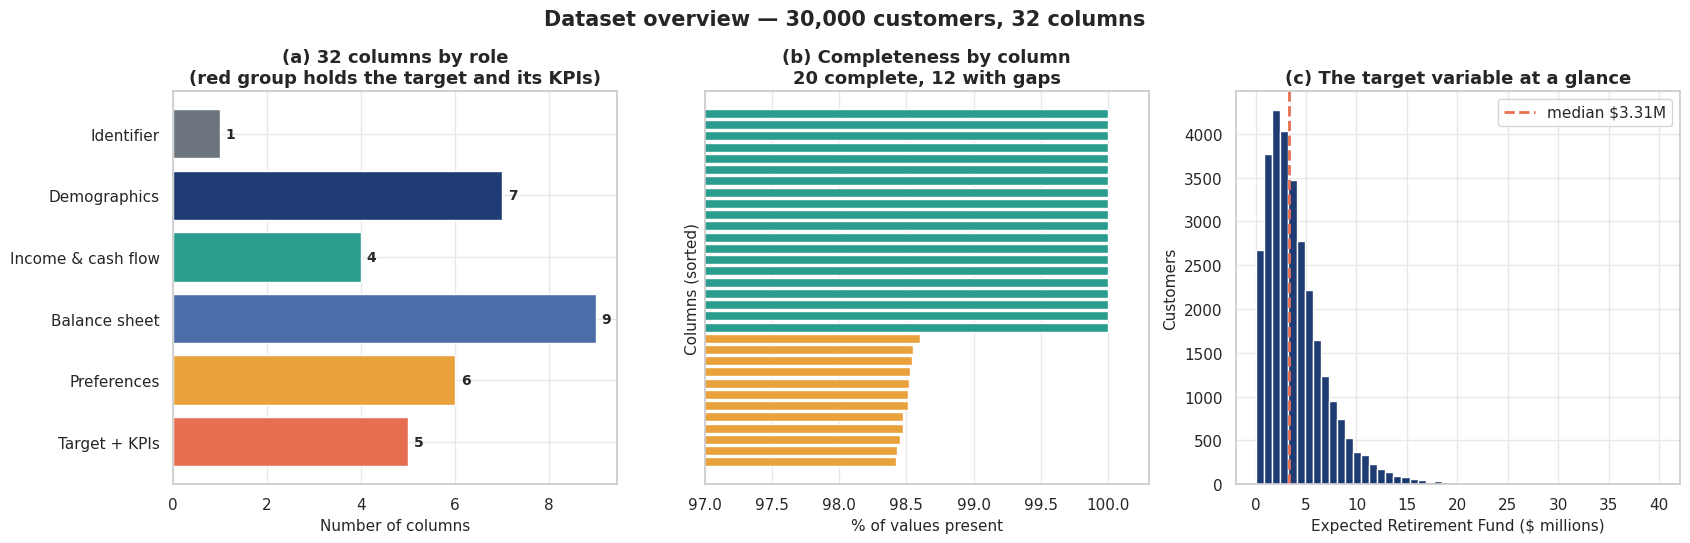

In [10]:
# --- Figure: a one-glance summary of the dataset --------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# (a) How the 32 columns break down by role. Grouping by ROLE rather than dtype
#     is more useful here, because the leakage group is what drives our decisions.
column_groups = {
    "Identifier": 1,
    "Demographics": 7,
    "Income & cash flow": 4,
    "Balance sheet": 9,
    "Preferences": 6,
    "Target + KPIs": 5,
}
group_colors = [SLATE, NAVY, TEAL, "#4C6EA8", AMBER, CORAL]

axes[0].barh(list(column_groups.keys()), list(column_groups.values()),
             color=group_colors, edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_xlabel("Number of columns")
axes[0].set_title("(a) 32 columns by role\n(red group holds the target and its KPIs)")
for i, count in enumerate(column_groups.values()):
    axes[0].text(count + 0.12, i, str(count), va="center", fontweight="bold")

# (b) Completeness. Plotting the complement (% present) rather than % missing
#     makes the "this data is essentially complete" message immediate.
completeness = (1 - df.isna().mean()) * 100
completeness = completeness.sort_values()
bar_colors = np.where(completeness < 100, AMBER, TEAL)
axes[1].barh(range(len(completeness)), completeness, color=bar_colors,
             edgecolor="white")
axes[1].set_xlim(97, 100.3)
axes[1].set_yticks([])
axes[1].set_xlabel("% of values present")
axes[1].set_ylabel("Columns (sorted)")
axes[1].set_title(f"(b) Completeness by column\n"
                  f"{int((df.isna().mean() == 0).sum())} complete, "
                  f"{int((df.isna().mean() > 0).sum())} with gaps")

# (c) Target distribution preview, so the reader sees the outcome immediately.
axes[2].hist(df[TARGET] / 1e6, bins=50, color=NAVY, edgecolor="white")
axes[2].axvline(df[TARGET].median() / 1e6, color=CORAL, ls="--", lw=2,
                label=f"median ${df[TARGET].median()/1e6:.2f}M")
axes[2].set_xlabel("Expected Retirement Fund ($ millions)")
axes[2].set_ylabel("Customers")
axes[2].set_title("(c) The target variable at a glance")
axes[2].legend()

fig.suptitle("Dataset overview — 30,000 customers, 32 columns",
             fontsize=15, fontweight="bold")
save_fig("01_dataset_overview")
plt.show()

### What we learned

### What this tells us Panel (a) shows why the column-*role* breakdown matters more than the
dtype breakdown. The balance-sheet group is the largest at 9 columns, but the 5-column
**Target + KPIs** group in red is the one that determines whether this project succeeds. Four of
those five columns are mathematically tied to each other, and three must never reach the model.

Panel (b) shows 20 columns fully complete and 12 with small gaps, none below 98.4% present.
This is an unusually clean dataset by real-world standards.

Panel (c) previews the outcome: a right-skewed distribution with a long upper tail and a median
of USD 3.31M.

### Why it matters The single most consequential fact about this dataset is visible in panel
(a): a fifth of the columns in the outcome group are derived from the target. Everything else in
this notebook is ordinary EDA; that group is what separates a working model from a worthless one.

### ML takeaway Missingness will be a minor preprocessing step (panel b), the
target will need a transform (panel c), and the leakage columns will need removing (panel a).
Sections 5, 3, and 11 handle these respectively.


# 2. Data Quality Assessment

### What are we doing?

Before looking for predictive patterns, we check whether the records are reliable enough to model. Each issue is given a decision: fix it, keep it, or investigate it.


In [11]:
# --- Check 1: Missing values ----------------------------------------------
missing_summary = pd.DataFrame({
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(3),
})
# Keep only the affected columns; showing 20 rows of zeros helps nobody.
missing_summary = missing_summary[missing_summary.n_missing > 0]
missing_summary = missing_summary.sort_values("pct_missing", ascending=False)

total_missing_cells = df.isna().sum().sum()
rows_with_any_gap = df.isna().any(axis=1).sum()

print(f"Columns with missing values: {len(missing_summary)} of {df.shape[1]}")
print(f"Rows with at least one gap:  {rows_with_any_gap:,} "
      f"({rows_with_any_gap / len(df) * 100:.2f}%)")
print(f"Fully complete rows:         {len(df) - rows_with_any_gap:,}")
print(f"Total missing cells:         {total_missing_cells:,} "
      f"({total_missing_cells / df.size * 100:.3f}% of all cells)")
missing_summary

Columns with missing values: 12 of 32
Rows with at least one gap:  4,972 (16.57%)
Fully complete rows:         25,028
Total missing cells:         5,397 (0.562% of all cells)


,n_missing,pct_missing
column,,
MonthlyExpenses,473,1.5770
AnnualSalary,472,1.5730
SavingsRate,464,1.5470
CheckingBalance,458,1.5270
AnnualBonus,457,1.5230
Debt,447,1.4900
ExpectedAnnualReturn,446,1.4870
EmergencyFund,445,1.4830
Savings,441,1.4700


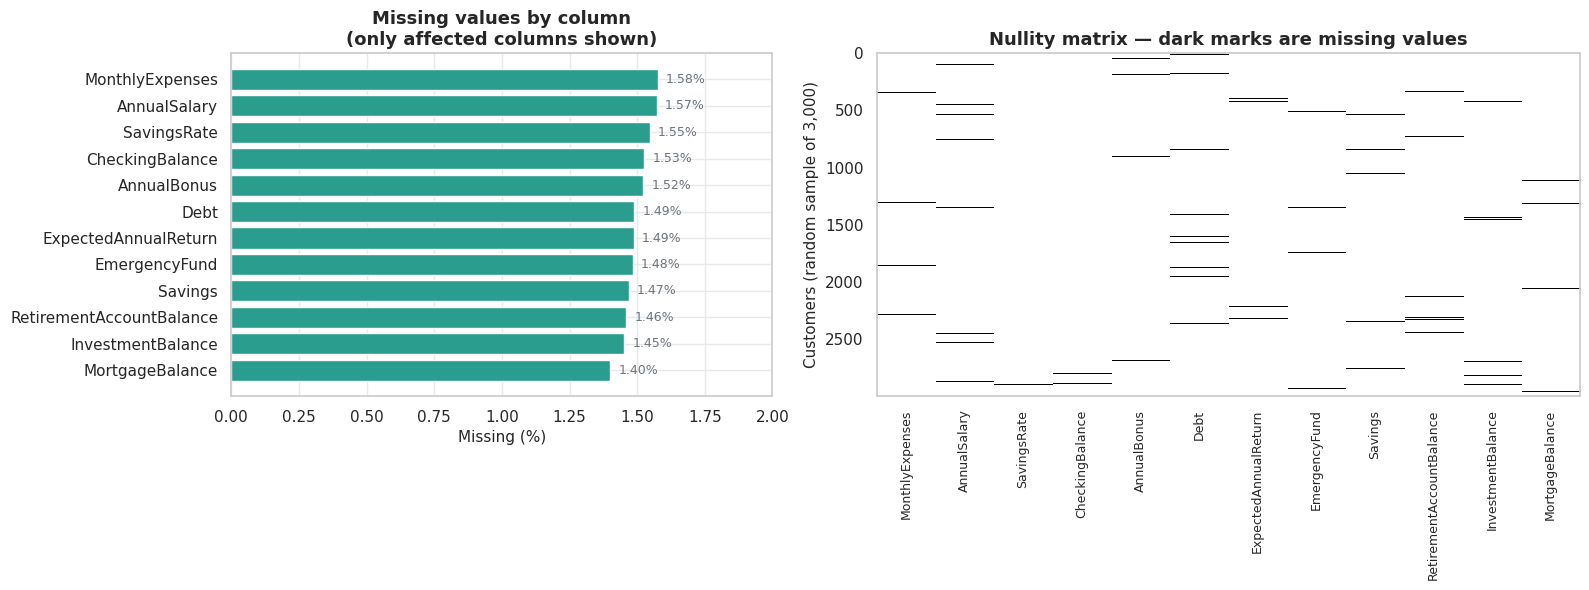

In [12]:
# --- Figure: two complementary views of missingness -----------------------
#   (left)  HOW MUCH is missing per column
#   (right) WHERE the gaps sit, which reveals whether they cluster in the same rows
fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={"width_ratios": [1, 1.3]})

axes[0].barh(missing_summary.index, missing_summary.pct_missing,
             color=TEAL, edgecolor="white")
axes[0].set_xlabel("Missing (%)")
axes[0].set_title("Missing values by column\n(only affected columns shown)")
axes[0].invert_yaxis()
axes[0].set_xlim(0, 2.0)
for y_position, pct in enumerate(missing_summary.pct_missing):
    axes[0].text(pct + 0.03, y_position, f"{pct:.2f}%",
                 va="center", fontsize=9, color=SLATE)

# The nullity matrix: each row of pixels is a customer, dark marks are gaps.
# We sample 3,000 rows so individual marks stay visible at this figure size.
nullity_sample = df[missing_summary.index].isna().sample(3000, random_state=0)
axes[1].imshow(nullity_sample.values, aspect="auto", cmap="binary",
               interpolation="nearest")
axes[1].set_xticks(range(len(missing_summary.index)))
axes[1].set_xticklabels(missing_summary.index, rotation=90, fontsize=9)
axes[1].set_ylabel("Customers (random sample of 3,000)")
axes[1].set_title("Nullity matrix — dark marks are missing values")
axes[1].grid(False)

save_fig("02_missing_values")
plt.show()

### What we learned

### What this tells us The left panel shows all 12 affected columns sitting in a tight band
between **1.40% and 1.58%** missing. Real-world missingness is almost never this uniform —
income is typically missing far more often than age. That uniformity is the first hint that
values were deleted at random by the data generator rather than reflecting a real-world refusal
or collection failure.

The right panel is the more informative view. If missingness were driven by a common cause —
a customer abandoning a financial questionnaire, or a failed data feed — we would see
**horizontal streaks**: single rows with many columns dark at once. Instead the marks are
scattered with no visible row structure.

### Why it matters The mechanism determines the fix. Under MCAR, simple imputation is
*unbiased* and nothing more sophisticated is needed. Under MAR or MNAR, median imputation would
systematically distort the data. Section 5 tests this numerically with a permutation test rather
than relying on the visual impression.

### ML takeaway Low. 0.56% of cells across 12 columns is a minor preprocessing
step. But note the trap: dropping incomplete rows would discard **4,972 customers (16.6%)** to
fix 0.56% of cells. Impute, do not delete.


In [13]:
# --- Check 2: Duplicate rows ----------------------------------------------
# Three counts, because the differences between them are diagnostic:
#   - identical on ALL columns   -> byte-identical copies (pipeline artefact)
#   - identical CustomerID       -> could be ID collisions between real people
#   - identical ignoring the ID  -> could be two people with identical profiles
n_exact_duplicates = df.duplicated().sum()
n_duplicate_ids = df["CustomerID"].duplicated().sum()
n_duplicates_ignoring_id = df.drop(columns="CustomerID").duplicated().sum()

print(f"Exact duplicate rows (all 32 columns):  {n_exact_duplicates}")
print(f"Duplicated CustomerID values:           {n_duplicate_ids}")
print(f"Duplicate rows ignoring CustomerID:     {n_duplicates_ignoring_id}")
print(f"Unique CustomerIDs: {df.CustomerID.nunique():,} of {len(df):,} rows")
print()

duplicated_ids = df.loc[df.duplicated(keep=False), "CustomerID"].unique()
print(f"{len(duplicated_ids)} CustomerIDs appear twice, "
      f"e.g. {sorted(duplicated_ids)[:6]}")
print("\nExample of a duplicated pair:")
df[df.CustomerID == sorted(duplicated_ids)[0]].iloc[:, :8]

Exact duplicate rows (all 32 columns):  150
Duplicated CustomerID values:           150
Duplicate rows ignoring CustomerID:     150
Unique CustomerIDs: 29,850 of 30,000 rows

150 CustomerIDs appear twice, e.g. [np.int64(428), np.int64(1213), np.int64(1578), np.int64(1720), np.int64(1749), np.int64(1940)]

Example of a duplicated pair:


column,CustomerID,Age,Gender,Education,MaritalStatus,NumberOfChildren,EmploymentStatus,YearsExperience
427,428,57,Female,College,Divorced,2,Full-time,35
7111,428,57,Female,College,Divorced,2,Full-time,35


### What we learned

### What this tells us All three counts land on exactly **150**, which pins down the diagnosis
precisely. Had `n_exact_duplicates` been lower than `n_duplicate_ids`, we would be looking at
genuine ID collisions between different people — a much harder problem. Because they are equal,
these are **150 byte-identical copies of existing customers**: a data pipeline artefact, most
likely a partial re-run appended to the file.

### Why it matters This is the highest-priority cleanup in the notebook despite affecting only
0.5% of rows, and the reason is *ordering*. If duplicates survive into a train/test split,
roughly 75 customers appear in **both** sets. The model then gets credit for recalling rows it
has already memorised, and every validation metric is optimistically biased.

### ML takeaway The bias is small in magnitude but silent in operation, which is
what makes it dangerous — nothing in the output will look wrong. `df.drop_duplicates()` must be
the **first** line of preprocessing, before `train_test_split()`.


In [14]:
# --- Check 3: Invalid and impossible values -------------------------------
# Financial data has hard logical floors and ceilings. We check each one
# explicitly rather than assuming the generator respected them.
money_columns = [
    "AnnualSalary", "AnnualBonus", "Savings", "CheckingBalance", "EmergencyFund",
    "InvestmentBalance", "RetirementAccountBalance", "Debt", "MortgageBalance",
    "MonthlyExpenses", "Retirement_Fund_Goal", "Expected_Retirement_Fund",
]

# Funding_Gap is deliberately excluded from the "no negatives" rule:
# a negative gap is meaningful (a projected shortfall), not an error.
integrity_checks = {
    "Negative monetary values":
        int((df[money_columns] < 0).sum().sum()),
    "Age below 18":
        int((df.Age < 18).sum()),
    "Started work before age 16":
        int(((df.Age - df.YearsExperience) < 16).sum()),
    "DesiredRetirementAge <= Age":
        int((df.DesiredRetirementAge <= df.Age).sum()),
    "SavingsRate outside [0, 1]":
        int(((df.SavingsRate < 0) | (df.SavingsRate > 1)).sum()),
    "ExpectedAnnualReturn outside [0, 0.5]":
        int(((df.ExpectedAnnualReturn < 0) | (df.ExpectedAnnualReturn > 0.5)).sum()),
    "ExpectedInflation outside [0, 0.2]":
        int(((df.ExpectedInflation < 0) | (df.ExpectedInflation > 0.2)).sum()),
    "CreditScore outside [300, 850]":
        int(((df.CreditScore < 300) | (df.CreditScore > 850)).sum()),
    "RiskTolerance outside [0, 100]":
        int(((df.RiskTolerance < 0) | (df.RiskTolerance > 100)).sum()),
    "Expected_Retirement_Fund <= 0":
        int((df.Expected_Retirement_Fund <= 0).sum()),
    "Retirement_Fund_Goal <= 0":
        int((df.Retirement_Fund_Goal <= 0).sum()),
}

integrity = pd.Series(integrity_checks, name="n_violations").to_frame()
integrity["status"] = np.where(integrity.n_violations == 0, "PASS", "REVIEW")
integrity

,n_violations,status
Negative monetary values,0,PASS
Age below 18,0,PASS
Started work before age 16,0,PASS
DesiredRetirementAge <= Age,0,PASS
"SavingsRate outside [0, 1]",0,PASS
"ExpectedAnnualReturn outside [0, 0.5]",0,PASS
"ExpectedInflation outside [0, 0.2]",0,PASS
"CreditScore outside [300, 850]",0,PASS
"RiskTolerance outside [0, 100]",0,PASS
Expected_Retirement_Fund <= 0,0,PASS


### What we learned

### What this tells us **All eleven integrity checks pass.** There are no negative balances, no
impossible ages, no out-of-range rates or scores, and no non-positive target values. Two results
are worth calling out specifically:

- **`Age − YearsExperience` has a minimum of 18**, so nobody entered the workforce as a child.
- **`DesiredRetirementAge` exceeds `Age` for every single row** (minimum difference: 1 year). In
  the earlier draft of this dataset, 2,506 customers had already passed their desired retirement
  age, which made that field mean two different things depending on the row. The redesign
  eliminated that ambiguity.

### Why it matters Clean domain constraints mean we can trust the raw values without building
defensive validation into the pipeline, and they remove a whole class of "is this a real value
or a sentinel?" questions. The `DesiredRetirementAge > Age` guarantee is what makes the
engineered `YearsUntilRetirement` feature (Section 10) well defined for every row.

### ML takeaway No corrective action needed. This is the section where a real
dataset usually generates a work list; here it generates none.


In [15]:
# --- Check 4 & 5: Constant and near-constant columns ----------------------
# Zero-variance columns carry no information. Near-constant columns carry very
# little and can produce unstable coefficients after one-hot encoding.
constant_columns = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"Constant (zero-variance) columns: "
      f"{constant_columns if constant_columns else 'none'}\n")

# Build the dominance table with a plain loop - clearer than a nested
# comprehension, and easy to explain line by line in an interview.
dominance_rows = []
for column in df.columns:
    value_counts = df[column].value_counts(dropna=False)
    share_of_rows = value_counts.iloc[0] / len(df) * 100
    dominance_rows.append({
        "column": column,
        "top_value": value_counts.index[0],
        "top_value_share_pct": round(share_of_rows, 2),
        "n_unique": df[column].nunique(dropna=False),
    })

dominance = pd.DataFrame(dominance_rows).set_index("column")
print("Columns where a single value covers more than 50% of rows:")
dominance[dominance.top_value_share_pct > 50].sort_values(
    "top_value_share_pct", ascending=False)

Constant (zero-variance) columns: none

Columns where a single value covers more than 50% of rows:


,top_value,top_value_share_pct,n_unique
column,,,
EmploymentStatus,Full-time,71.2300,4
OwnHouse,Yes,62.0800,2
MaritalStatus,Married,56.4000,4
RetirementReady,0,52.8500,2
EmployerPension,Yes,50.3500,2
Gender,Female,50.2400,4


### What we learned

### What this tells us No column is constant, so nothing is dropped for zero variance. Six
columns are dominated by a single value, and all six are ordinary population characteristics
rather than defects: `EmploymentStatus` at 71.2% full-time, `OwnHouse` at 62.1% owners,
`MaritalStatus` at 56.4% married, `RetirementReady` at 52.8% not-ready, `Gender` at 50.2%
female, and `EmployerPension` at 50.4% with a pension.

### Why it matters The one worth attention is **`EmploymentStatus`**: 71.2% full-time leaves
only 1,347 unemployed customers (4.5%). Any coefficient or split learned specifically for the
unemployed group rests on a thin slice of data — under 5-fold cross-validation, each fold sees
roughly 270 of them.

### ML takeaway Keep all six; none qualifies for removal on variance grounds. But
report error metrics for the unemployed sub-group separately. A pooled metric dominated by the
71% full-time majority can hide poor performance on the smallest group entirely — and that group
is precisely the one a retirement provider would most want to identify.


In [16]:
# --- Check 6: Suspicious value pile-ups (ceilings and structural zeros) ---
# A generator that clips extreme values leaves a tell-tale spike at a round number.
# Structural zeros are different: they mean "none", not "missing", and must survive.
ceiling_candidates = ["AnnualSalary", "Savings", "CheckingBalance",
                      "RetirementAccountBalance", "MortgageBalance", "Debt"]

ceiling_rows = []
for column in ceiling_candidates:
    max_value = df[column].max()
    ceiling_rows.append({
        "column": column,
        "max_value": max_value,
        "n_rows_at_max": int((df[column] == max_value).sum()),
        "n_zeros": int((df[column] == 0).sum()),
        "pct_zeros": round((df[column] == 0).mean() * 100, 2),
    })

ceilings = pd.DataFrame(ceiling_rows).set_index("column")
print("Round-number maxima indicate the generator clipped extreme values:\n")
ceilings

Round-number maxima indicate the generator clipped extreme values:



,max_value,n_rows_at_max,n_zeros,pct_zeros
column,,,,
AnnualSalary,"525,000.0000",16,839,2.8000
Savings,"3,500,000.0000",1,2643,8.8100
CheckingBalance,"150,000.0000",55,0,0.0000
RetirementAccountBalance,"12,000,000.0000",1,0,0.0000
MortgageBalance,"1,300,000.0000",78,11627,38.7600
Debt,"155,351.9100",1,8680,28.9300


### What we learned

### What this tells us Four maxima land on suspiciously round numbers — salary at exactly
**USD 525,000** (16 rows), savings at **USD 3,500,000**, checking at **USD 150,000** (55 rows), retirement
accounts at **USD 12,000,000**, and mortgages at **USD 1,300,000** (78 rows). Genuine continuous
financial data does not pile up on round numbers. These are **hard caps applied by the data
generator** — pre-applied winsorization.

The zero counts tell a different and more useful story. **38.8% of `MortgageBalance` values are
zero** and **28.9% of `Debt` values are zero**. These are not missing data; they are *structural
zeros* meaning "this customer has no mortgage" and "this customer is debt-free".

### Why it matters Two distinct consequences:

1. **The caps mean the extremes are already trimmed.** Anything Section 6 might flag as an
   "outlier" is a value the generator deliberately allowed. Trimming again would be trimming
   twice. The 55 customers at exactly USD 150,000 checking are *censored* — their true values are
   unknown and at least that large.
2. **The zeros are a real category, not noise.** Imputing them, or log-transforming without
   handling the point mass, would corrupt a meaningful distinction. Section 6 shows exactly how
   that backfires.

### ML takeaway Keep the caps, keep the zeros, and add two kinds of flag:
`IsCapped` indicators for the censored values, and `HasMortgage` / `HasDebt` indicators for the
structural zeros (Section 10).


# 3. Target Variable Analysis — `Expected_Retirement_Fund`

### What are we doing?

The target is the amount we ultimately want to predict. Here we examine its distribution, scale, skewness, and whether a transformation would make regression more appropriate.


In [17]:
# --- Summary statistics ---------------------------------------------------
target_values = df[TARGET]

target_stats = pd.Series({
    "count":             target_values.count(),
    "missing":           target_values.isna().sum(),
    "mean":              target_values.mean(),
    "std":               target_values.std(),
    "min":               target_values.min(),
    "1%":                target_values.quantile(0.01),
    "5%":                target_values.quantile(0.05),
    "25%":               target_values.quantile(0.25),
    "50% (median)":      target_values.median(),
    "75%":               target_values.quantile(0.75),
    "95%":               target_values.quantile(0.95),
    "99%":               target_values.quantile(0.99),
    "max":               target_values.max(),
    "IQR":               target_values.quantile(0.75) - target_values.quantile(0.25),
    "skewness":          target_values.skew(),
    "kurtosis (excess)": target_values.kurt(),
})

print(f"TARGET: {TARGET}\n" + "-" * 46)
for label, value in target_stats.items():
    print(f"{label:>20s}  {value:>18,.4f}")

print("\nSpread diagnostics")
print(f"{'mean / median':>20s}  "
      f"{target_values.mean() / target_values.median():>18.3f}")
print(f"{'max / median':>20s}  "
      f"{target_values.max() / target_values.median():>18.1f}")
print(f"{'p99 / p1':>20s}  "
      f"{target_values.quantile(0.99) / target_values.quantile(0.01):>18.1f}")
print(f"{'coeff. of variation':>20s}  "
      f"{target_values.std() / target_values.mean():>18.3f}")

TARGET: Expected_Retirement_Fund
----------------------------------------------
               count         30,000.0000
             missing              0.0000
                mean      4,047,429.9588
                 std      3,122,912.9707
                 min         57,489.4600
                  1%        206,886.1419
                  5%        589,877.0005
                 25%      1,860,789.9400
        50% (median)      3,310,527.9750
                 75%      5,374,246.8550
                 95%     10,015,251.5895
                 99%     14,897,083.6384
                 max     40,078,281.5900
                 IQR      3,513,456.9150
            skewness              1.8487
   kurtosis (excess)              6.1506

Spread diagnostics
       mean / median               1.223
        max / median                12.1
            p99 / p1                72.0
 coeff. of variation               0.772


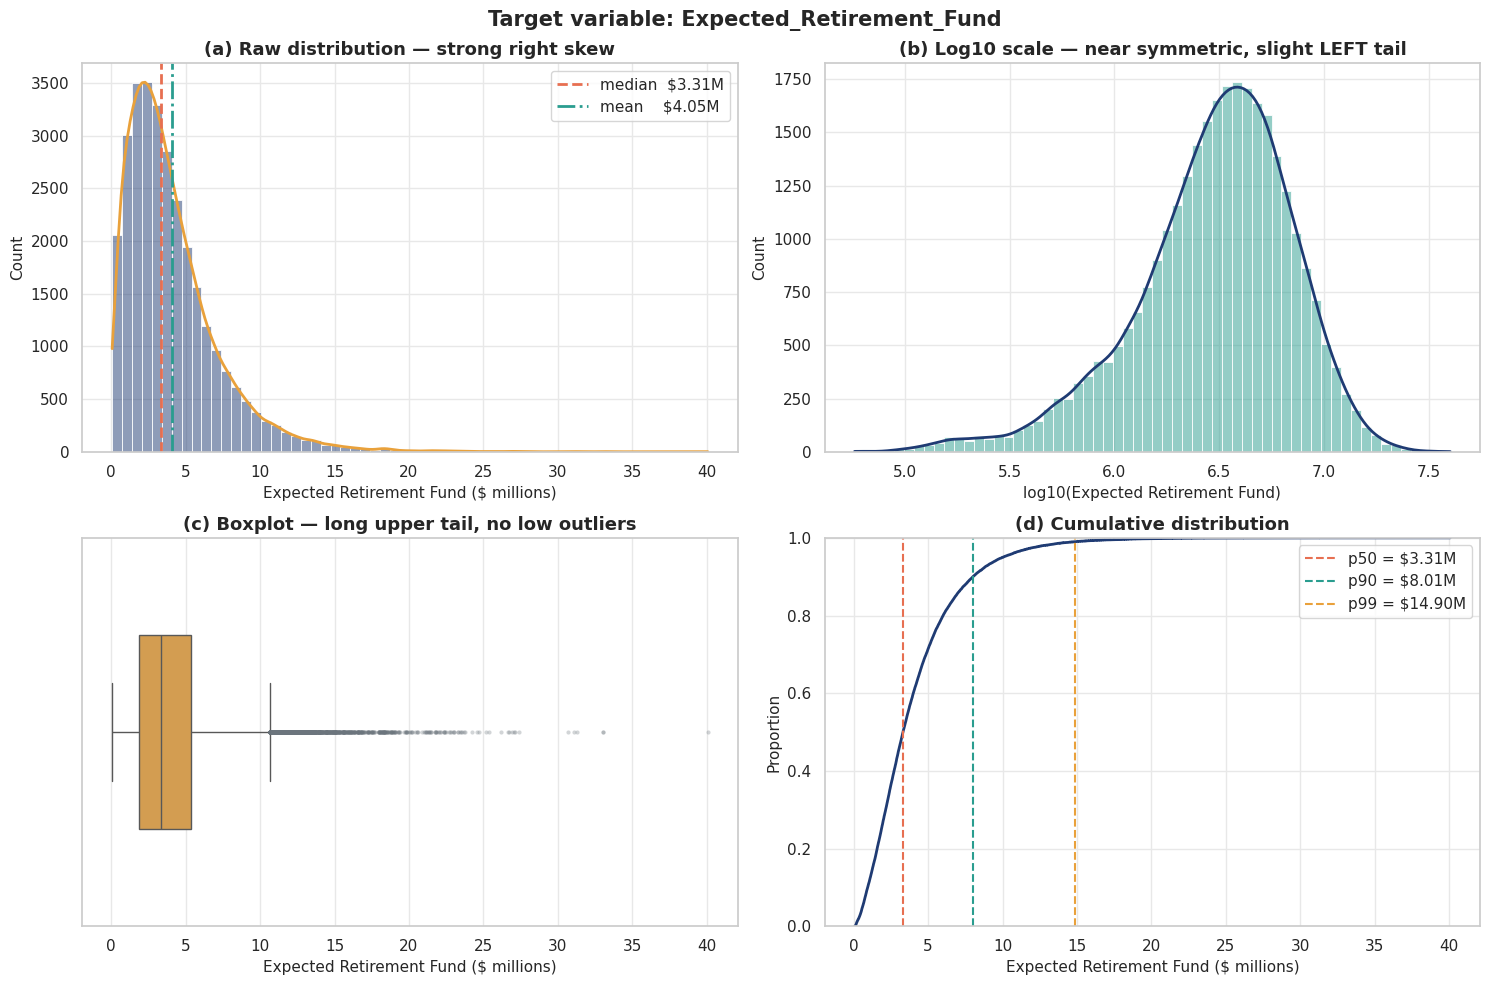

In [18]:
# --- Figure: four views of the target distribution ------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# (a) Histogram with KDE, raw dollars
sns.histplot(target_values / 1e6, bins=60, kde=True, color=NAVY, ax=axes[0, 0],
             edgecolor="white", line_kws={"linewidth": 2})
axes[0, 0].lines[0].set_color(AMBER)
axes[0, 0].axvline(target_values.median() / 1e6, color=CORAL, ls="--", lw=2,
                   label=f"median  ${target_values.median()/1e6:.2f}M")
axes[0, 0].axvline(target_values.mean() / 1e6, color=TEAL, ls="-.", lw=2,
                   label=f"mean    ${target_values.mean()/1e6:.2f}M")
axes[0, 0].set_xlabel("Expected Retirement Fund ($ millions)")
axes[0, 0].set_title("(a) Raw distribution — strong right skew")
axes[0, 0].legend()

# (b) Same data on a log10 scale
sns.histplot(np.log10(target_values), bins=60, kde=True, color=TEAL, ax=axes[0, 1],
             edgecolor="white", line_kws={"linewidth": 2})
axes[0, 1].lines[0].set_color(NAVY)
axes[0, 1].set_xlabel("log10(Expected Retirement Fund)")
axes[0, 1].set_title("(b) Log10 scale — near symmetric, slight LEFT tail")

# (c) Boxplot
sns.boxplot(x=target_values / 1e6, color=AMBER, ax=axes[1, 0], width=0.5,
            flierprops={"marker": "o", "markersize": 3, "alpha": 0.3,
                        "markerfacecolor": SLATE, "markeredgecolor": "none"})
axes[1, 0].set_xlabel("Expected Retirement Fund ($ millions)")
axes[1, 0].set_title("(c) Boxplot — long upper tail, no low outliers")

# (d) Empirical cumulative distribution
sns.ecdfplot(target_values / 1e6, color=NAVY, lw=2, ax=axes[1, 1])
for quantile, colour in [(0.5, CORAL), (0.9, TEAL), (0.99, AMBER)]:
    axes[1, 1].axvline(target_values.quantile(quantile) / 1e6, color=colour,
                       ls="--", lw=1.5,
                       label=f"p{int(quantile*100)} = "
                             f"${target_values.quantile(quantile)/1e6:.2f}M")
axes[1, 1].set_xlabel("Expected Retirement Fund ($ millions)")
axes[1, 1].set_title("(d) Cumulative distribution")
axes[1, 1].legend()

fig.suptitle("Target variable: Expected_Retirement_Fund",
             fontsize=15, fontweight="bold")
save_fig("03_target_distribution")
plt.show()

### What we learned

### What this tells us

*Shape.* Panel (a) shows a classic right-skewed wealth distribution. The mean (USD 4.05M) sits
**22% above** the median (USD 3.31M) — the standard signature of a long upper tail pulling the
average away from the typical customer. Skewness is **+1.85** and excess kurtosis **+6.15**, so
the distribution is both asymmetric and considerably heavier-tailed than a normal.

*No lower tail.* Panel (c) shows every flagged point on the *upper* side. The minimum is
**USD 57,489** — small, but positive and plausible. There is no cluster of zeros or negatives, so
the target needs no floor treatment.

*Range.* The largest projected fund is **USD 40.1M, 12.1× the median**. Panel (d) shows the
distribution is genuinely stretched: p99 (USD 14.9M) is **72× p1** (USD 207K).

### Why it matters A model optimised on raw dollars spends most of its capacity on the top few
percent of customers, because that is where the squared errors live. An error of USD 2M on a USD 30M
customer contributes 400× more to the loss than a USD 100K error on a USD 500K customer — even though
the second is proportionally worse.

### ML takeaway The distribution's shape directly determines the loss function and
the transform, which the next cell quantifies.

### Business reading The gap between mean and median is the practical takeaway for a retirement
provider: planning around the USD 4.05M average would systematically overstate what a typical
customer will have. The median customer is projected to reach **USD 3.31M**, and a quarter will not
exceed **USD 1.86M**.


In [19]:
# --- Does a log transform actually help? Quantify it, do not assume -------
log_target = np.log(target_values)

transform_comparison = pd.DataFrame({
    "raw_target": [
        target_values.skew(),
        target_values.kurt(),
        target_values.std() / target_values.mean(),
        target_values.max() / target_values.median(),
    ],
    "log_target": [
        log_target.skew(),
        log_target.kurt(),
        log_target.std() / log_target.mean(),
        log_target.max() / log_target.median(),
    ],
}, index=["skewness", "excess_kurtosis", "coeff_of_variation", "max_over_median"])

print("Effect of the natural-log transform on target shape:\n")
print(transform_comparison.round(4).to_string())


def count_iqr_outliers(series):
    "Return (n_below_lower_fence, n_above_upper_fence) using the 1.5 x IQR rule."
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    return int((series < lower_fence).sum()), int((series > upper_fence).sum())


raw_low, raw_high = count_iqr_outliers(target_values)
log_low, log_high = count_iqr_outliers(log_target)

print(f"\n1.5 x IQR outliers, raw target: {raw_low + raw_high:,} "
      f"({(raw_low + raw_high) / len(target_values) * 100:.2f}%)  "
      f"[{raw_low} low, {raw_high} high]")
print(f"1.5 x IQR outliers, log target: {log_low + log_high:,} "
      f"({(log_low + log_high) / len(target_values) * 100:.2f}%)  "
      f"[{log_low} low, {log_high} high]")

Effect of the natural-log transform on target shape:

                    raw_target  log_target
skewness                1.8487     -0.7807
excess_kurtosis         6.1506      0.9685
coeff_of_variation      0.7716      0.0580
max_over_median        12.1063      1.1661

1.5 x IQR outliers, raw target: 1,234 (4.11%)  [0 low, 1234 high]
1.5 x IQR outliers, log target: 744 (2.48%)  [732 low, 12 high]


### Should we transform the target? Yes — but read the fine print.

### What this tells us The log transform cuts skewness from **+1.849 to −0.781** and excess
kurtosis from **+6.151 to +0.969**. Total IQR-flagged outliers fall from **1,234 (4.11%) to 744
(2.48%)**.

But the *composition* of those flags changes completely, and that is the part worth noticing:

| | Low-side flags | High-side flags |
|---|---|---|
| Raw target | 0 | **1,234** |
| Log target | **732** | 12 |

The transform does not merely shrink the tail — it **moves it to the other side**. The residual
skew of −0.781 is a *left* skew, meaning the transform slightly overcorrects. The 732 low-side
flags are customers with genuinely small projected funds who look unremarkable on a dollar scale
and extreme on a log scale.

### Why it matters Log-transforming is still the right call: −0.78 skew is far more tractable
than +1.85, and cutting the outlier count by 40% is a real gain. But anyone reporting "the log
transform removed the outliers" would be wrong. It replaced 1,234 upper-tail flags with 732
lower-tail ones.

### ML takeaway Train on `log(Expected_Retirement_Fund)`, predict, then
exponentiate back to dollars. Two caveats that are easy to miss and matter a great deal:

1. **Log-space squared error minimises *relative* error, not absolute error.** A model 10% wrong
   on a USD 500K customer and 10% wrong on a USD 10M customer is scored identically in log space, even
   though the second error is USD 950K larger. Which is correct depends on the business question:
   *"How accurate is this individual customer's projection?"* → relative error, log target is
   right. *"What is our total balance-sheet exposure?"* → absolute dollars, train on the raw
   scale.
2. **Back-transforming with `exp()` alone yields the conditional median, not the mean**, and
   will systematically under-predict aggregate totals. If aggregate dollars are the goal, apply
   Duan's smearing estimator or model the raw scale directly.

Report **both** RMSE in dollars and MAPE so this trade-off stays visible rather than hidden
inside a metric choice.


# 4. Univariate Analysis

### What are we doing?

We now examine the predictors one at a time. The purpose is not just to describe them, but to identify transformations, unusual distributions, and variables that may need special treatment.


In [20]:
# --- Numeric summary with shape diagnostics -------------------------------
# RetirementReady is excluded here: it is a 0/1 flag, so "skewness" of it is
# not a meaningful shape statistic. CustomerID is excluded as a row key.
numeric_cols = df.select_dtypes(include=np.number).columns.drop(
    ["CustomerID", "RetirementReady"])

summary = df[numeric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).T
summary["skew"] = df[numeric_cols].skew()
summary["kurtosis"] = df[numeric_cols].kurt()
summary["pct_zero"] = (df[numeric_cols] == 0).mean() * 100


# Labelling each variable by how much transformation it is likely to need makes
# the table scannable, and gives us a shared vocabulary for the sections below.
def describe_shape(skew_value):
    "Map a skewness value to a plain-language shape label."
    absolute_skew = abs(skew_value)
    if absolute_skew < 0.5:
        return "symmetric"
    if absolute_skew < 1.0:
        return "moderate skew"
    if absolute_skew < 2.0:
        return "high skew"
    return "extreme skew"


summary["shape"] = summary["skew"].apply(describe_shape)
summary = summary.sort_values("skew", ascending=False)
summary[["mean", "50%", "std", "skew", "kurtosis", "pct_zero", "shape"]].round(3)

,mean,50%,std,skew,kurtosis,pct_zero,shape
column,,,,,,,
InvestmentBalance,"119,897.5680","52,915.2450","190,008.9870",4.2650,33.5090,3.9830,extreme skew
CheckingBalance,"14,687.0350","9,648.5200","16,461.1550",3.7250,19.7220,0.0000,extreme skew
Savings,"211,604.6620","116,830.9000","282,081.2320",3.0980,15.7040,8.8100,extreme skew
RetirementAccountBalance,"825,845.0790","541,361.3000","912,287.1880",2.3460,8.8410,0.0000,extreme skew
Expected_Retirement_Fund,"4,047,429.9590","3,310,527.9750","3,122,912.9710",1.8490,6.1510,0.0000,high skew
Funding_Gap,"266,259.3030","-132,987.1400","2,677,522.1680",1.5880,6.4170,0.0000,high skew
AnnualBonus,"17,201.1880","13,469.3400","15,742.4770",1.5810,3.8020,4.4300,high skew
Readiness_Score,1.0860,0.9550,0.6930,1.5600,4.8820,0.0000,high skew
Debt,"14,256.0780","10,243.6400","15,906.8790",1.4900,2.8390,28.9330,high skew


### The three families

Sorting by skewness makes the structure obvious.

**Family 1 — Balance-sheet stocks (extreme right skew, skew 0.9 to 4.3).**
`InvestmentBalance` (+4.26), `CheckingBalance` (+3.73), `Savings` (+3.10),
`RetirementAccountBalance` (+2.35), `AnnualBonus` (+1.58), `Funding_Gap` (+1.59),
`Debt` (+1.49), `MortgageBalance` (+1.18), `EmergencyFund` (+0.93). Excess kurtosis reaches
**+33.5** for `InvestmentBalance`. These are accumulated wealth stocks, and their shape is
exactly what wealth distributions look like in reality — most people hold modest amounts, a few
hold enormous ones.

**Family 2 — Flows and rates (mild skew, |skew| < 1.0).**
`AnnualSalary` (+0.80), `MonthlyExpenses` (+0.70), `SavingsRate` (+0.00),
`ExpectedAnnualReturn` (+0.10), `ExpectedInflation` (+0.17). These are per-period quantities and
rates, and they are far better behaved. Scaling is enough; no transformation needed.
`SavingsRate` is the most symmetric variable in the entire dataset at skew **+0.0033**.

**Family 3 — Demographics and scores (symmetric or mildly left-skewed).**
`Age` (−0.34), `YearsExperience` (−0.24), `RiskTolerance` (−0.03),
`DesiredRetirementAge` (+0.07). All near-symmetric with *negative* excess kurtosis, meaning
flatter than a normal — the generator drew them from bounded, near-uniform ranges. Use as-is.

**The one variable that does not fit any family: `CreditScore`.** Skew **−1.41** with excess
kurtosis **+3.12** — the only strongly *left*-skewed variable in the dataset. This is the correct
shape for a credit score: the scale is hard-capped at 850, so scores bunch against the ceiling
while a thin tail of poor scores stretches down to 351. It needs no transformation, but it is
the one variable where a *left*-tail treatment would be considered rather than a right-tail one.


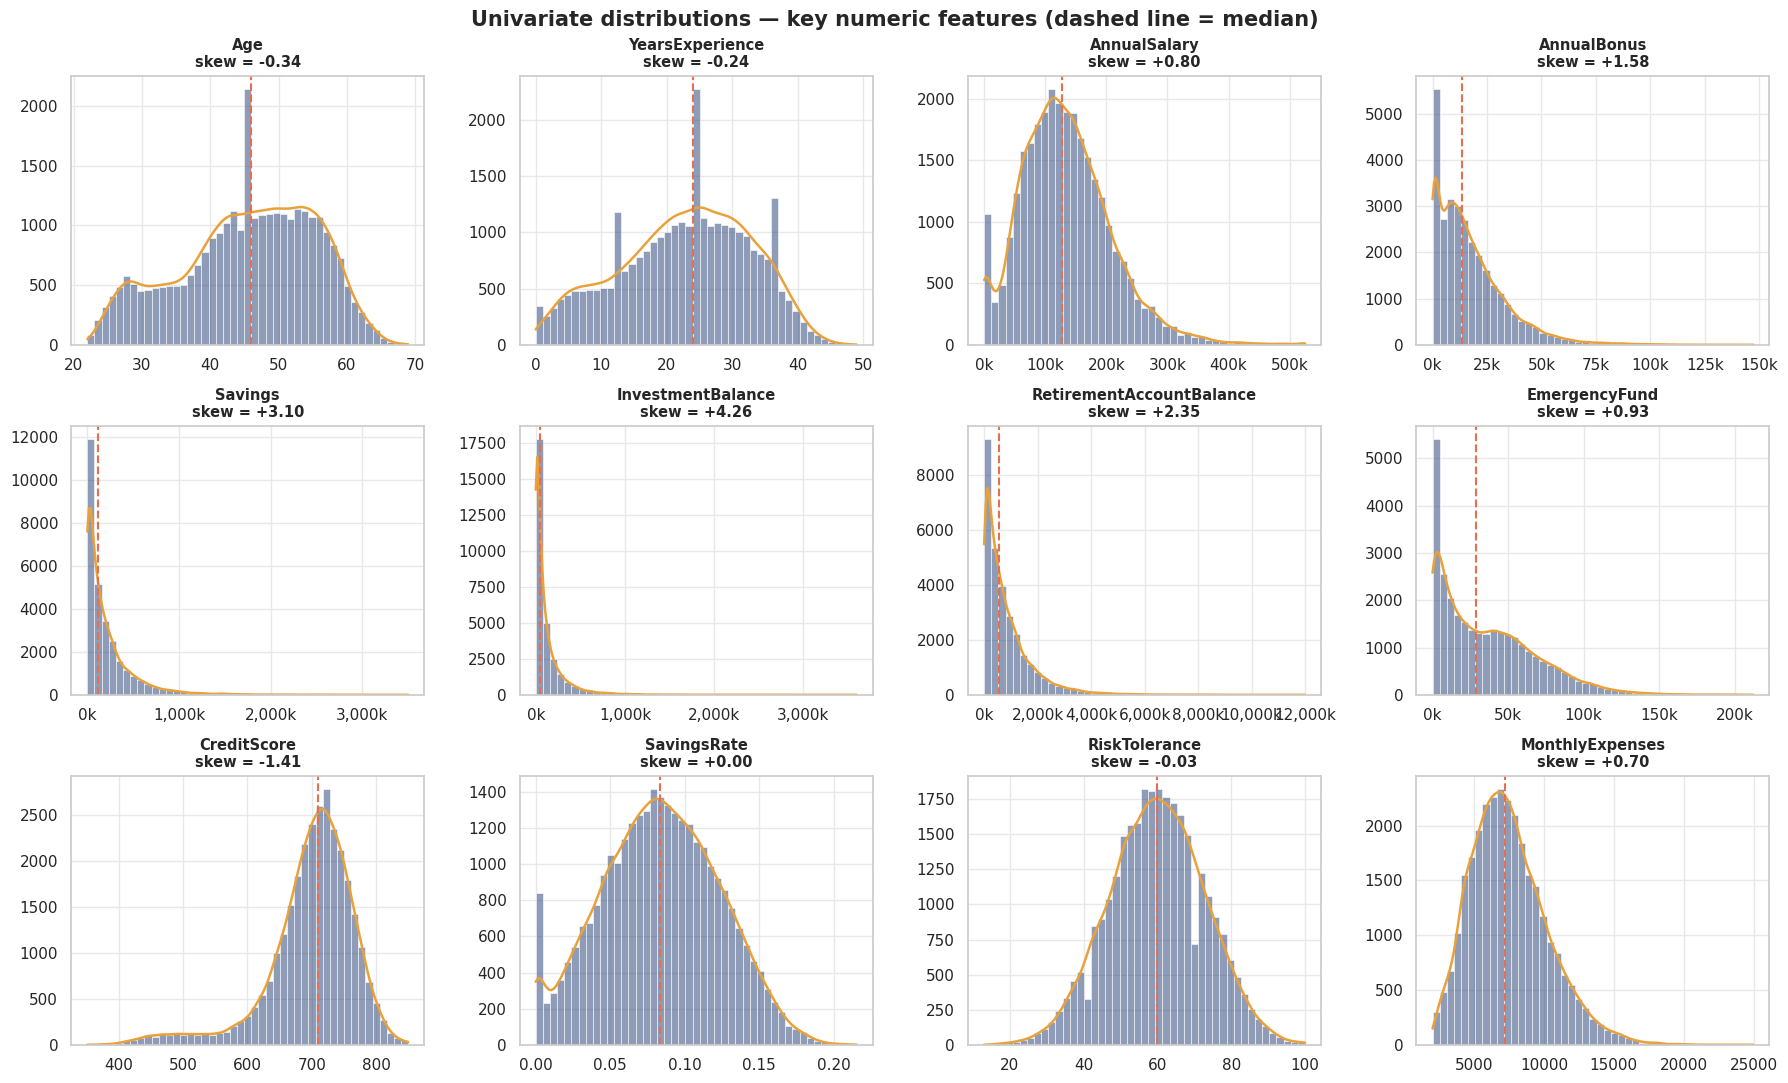

In [21]:
# --- Figure: distributions of the key numeric features --------------------
# Histogram + KDE for the twelve variables that matter most for modelling.
key_numeric = [
    "Age", "YearsExperience", "AnnualSalary", "AnnualBonus",
    "Savings", "InvestmentBalance", "RetirementAccountBalance", "EmergencyFund",
    "CreditScore", "SavingsRate", "RiskTolerance", "MonthlyExpenses",
]

fig, axes = plt.subplots(3, 4, figsize=(18, 11))

for ax, column in zip(axes.flat, key_numeric):
    values = df[column].dropna()
    sns.histplot(values, bins=45, kde=True, ax=ax, color=NAVY,
                 edgecolor="white", linewidth=0.4, line_kws={"linewidth": 1.8})
    ax.lines[0].set_color(AMBER)
    ax.axvline(values.median(), color=CORAL, ls="--", lw=1.5)
    ax.set_title(f"{column}\nskew = {values.skew():+.2f}", fontsize=10.5)
    ax.set_xlabel("")
    ax.set_ylabel("")
    # Large dollar values are unreadable in full; abbreviate to thousands.
    if values.max() > 100_000:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))

fig.suptitle("Univariate distributions — key numeric features "
             "(dashed line = median)", fontsize=15, fontweight="bold")
save_fig("04_numeric_distributions")
plt.show()

### What we learned

### What this tells us Reading the grid left to right, top to bottom:

- **`Age` and `YearsExperience`** are broad and flat, not bell-shaped. `Age` spans 22–69 with
  negative excess kurtosis (−0.72), so the generator sampled close to uniformly across the
  working-age range. This is good for modelling — we have coverage at every career stage rather
  than a crowd of 45-year-olds.
- **`Savings`, `InvestmentBalance`, `RetirementAccountBalance`** all show the same wealth shape:
  a tall spike at the low end and a tail running to the millions. `InvestmentBalance` is the most
  extreme, with a median of USD 52,915 against a maximum of USD 3.60M.
- **`EmergencyFund` has a visible spike at exactly zero** — 2,649 customers (8.83%). This is not
  noise; it is a distinct sub-population with no financial buffer at all, and it becomes a
  business finding in its own right (Section 13).
- **`SavingsRate`** is the most symmetric variable here (skew +0.00), spanning 0% to 21.5% with a
  median of 8.34%. Its 634 zeros are again a real group: customers saving nothing.
- **`CreditScore`** shows the left skew described above, with the tail extending down to 351.
- **`RiskTolerance`** is broad and effectively symmetric, centred at 60/100.

**Why it matters — the recurring pattern worth naming: spikes at zero.** Six variables —
`EmergencyFund` (2,649 zeros), `Savings` (2,643), `Debt` (8,680), `MortgageBalance` (11,627),
`InvestmentBalance` (1,195), and `SavingsRate` (634) — are *mixtures*: a point mass at zero plus
a continuous distribution above it. Treating them as ordinary continuous features throws away
the distinction between "has none" and "has a little", which is often the more predictive signal.

Note the contrast: **`CheckingBalance` and `RetirementAccountBalance` have no zeros at all.**
That difference turns out to matter enormously in Section 6.

### ML takeaway Six variables need a paired binary indicator alongside their
amount (Section 10). Two do not. Applying a blanket transform to all of them would be a mistake,
and Section 6 demonstrates exactly why.


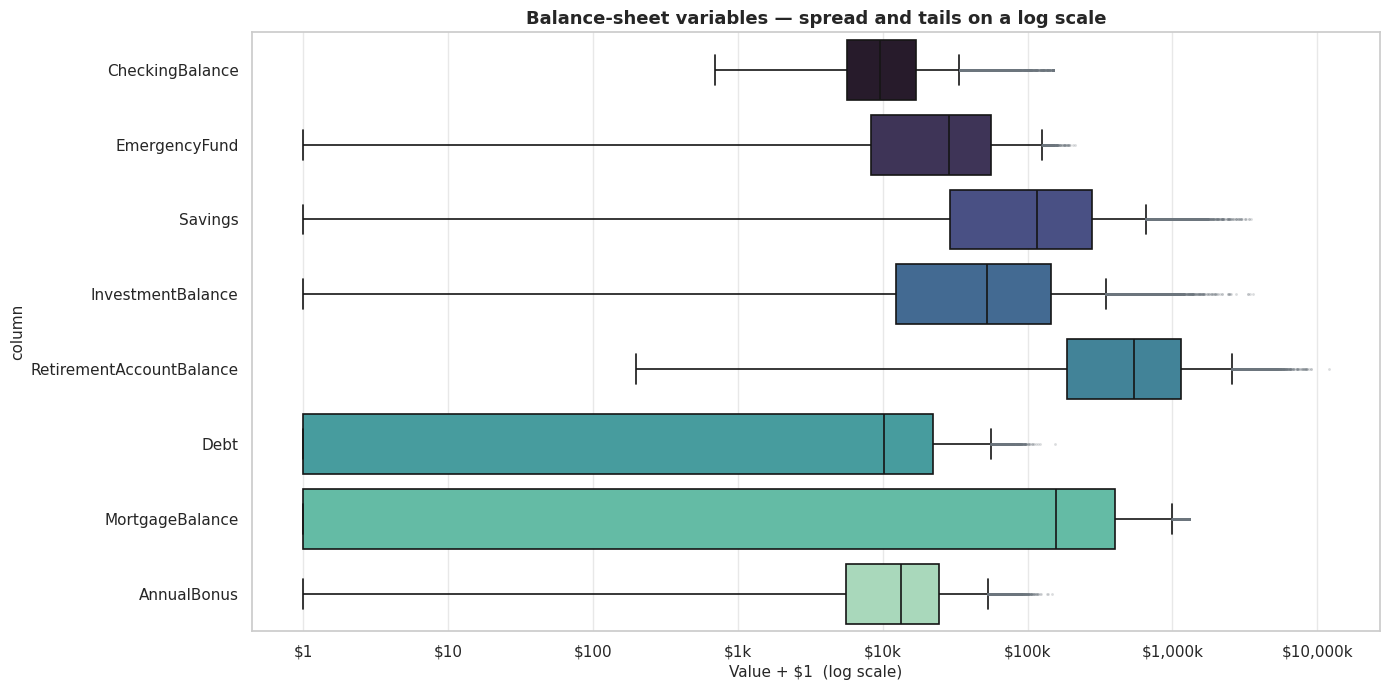

In [22]:
# --- Figure: boxplots on a shared log scale -------------------------------
# A log scale is the only way to see these eight variables side by side; on a
# linear axis the low-value boxes collapse into a single line at the left edge.
balance_cols = ["CheckingBalance", "EmergencyFund", "Savings", "InvestmentBalance",
                "RetirementAccountBalance", "Debt", "MortgageBalance", "AnnualBonus"]

fig, ax = plt.subplots(figsize=(14, 7))

# log(0) is undefined, so we shift by $1. This keeps the structural zeros
# visible at the bottom of the axis rather than silently dropping them.
shifted_balances = df[balance_cols] + 1

sns.boxplot(data=shifted_balances, orient="h", ax=ax, palette=SEQUENTIAL_CMAP,
            hue=None, fliersize=2, linewidth=1.2,
            flierprops={"alpha": 0.25, "markerfacecolor": SLATE,
                        "markeredgecolor": "none"})
ax.set_xscale("log")
ax.set_xlabel("Value + $1  (log scale)")
ax.set_title("Balance-sheet variables — spread and tails on a log scale")
ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(
    lambda v, _: f"${v:,.0f}" if v < 1000 else f"${v/1000:,.0f}k"))

save_fig("05_balance_sheet_boxplots")
plt.show()

### What we learned

### What this tells us The log axis compresses four orders of magnitude into one readable view
and exposes two distinct behaviours.

**`Debt`, `MortgageBalance`, `Savings`, `EmergencyFund`, and `InvestmentBalance` have whiskers
running to the left edge.** That is the structural-zero population again — 8,680 debt-free
customers and 11,627 without a mortgage. Their boxes are wide because they straddle a point mass
at zero *and* a continuous upper range. A single "median debt" statistic is close to meaningless
for these columns; they need to be analysed as two groups.

**`RetirementAccountBalance` sits an order of magnitude above everything else** — median
USD 541,361 versus USD 52,915 for `InvestmentBalance` and USD 9,649 for `CheckingBalance`. This is the
dominant asset on the customer balance sheet, which is intuitive given the domain but worth
confirming rather than assuming.

**`CheckingBalance` is the tightest distribution** (median USD 9,649, IQR USD 5,655–USD 16,962) and also
the one with the hardest visible ceiling — 55 customers sit at exactly USD 150,000. Even on a log
scale the flier cluster at the top edge is distinctly rectangular rather than tapering, which is
the visual signature of clipping rather than a natural tail.

### Why it matters The two groups behave differently under transformation, which is the subject
of Section 6.

### ML takeaway `RetirementAccountBalance` being the dominant asset means the
engineered `CurrentBalanceProjected` feature (Section 10) is likely to be among the strongest
predictors available.


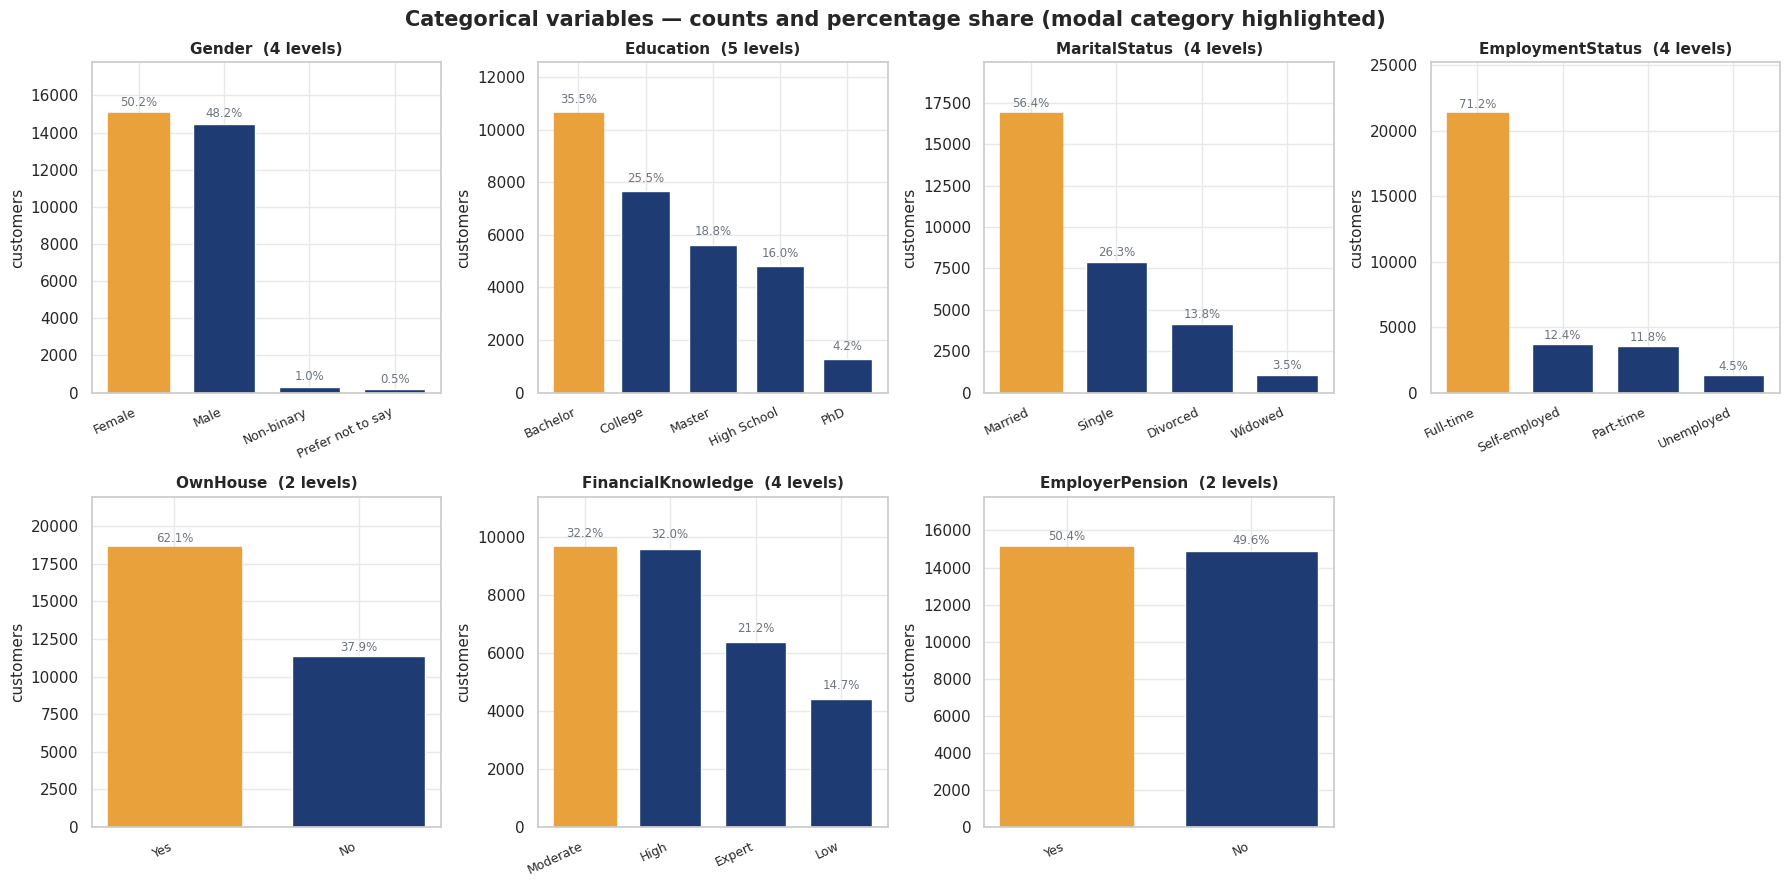

In [23]:
# --- Figure: categorical variables, counts and shares ---------------------
categorical_cols = df.select_dtypes(include="object").columns.tolist()

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for ax, column in zip(axes.flat, categorical_cols):
    counts = df[column].value_counts()
    shares = df[column].value_counts(normalize=True) * 100

    bars = ax.bar(range(len(counts)), counts.values, color=NAVY,
                  edgecolor="white", width=0.72)
    bars[0].set_color(AMBER)   # highlight the modal category

    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(counts.index, rotation=25, ha="right", fontsize=9)
    ax.set_title(f"{column}  ({df[column].nunique()} levels)", fontsize=11)
    ax.set_ylabel("customers")
    for i, (count, pct) in enumerate(zip(counts.values, shares.values)):
        ax.text(i, count + len(df) * 0.012, f"{pct:.1f}%",
                ha="center", fontsize=8.5, color=SLATE)
    ax.set_ylim(0, counts.max() * 1.18)

# Hide any unused panels if the grid is larger than the column count.
for ax in axes.flat[len(categorical_cols):]:
    ax.set_visible(False)

fig.suptitle("Categorical variables — counts and percentage share "
             "(modal category highlighted)", fontsize=15, fontweight="bold")
save_fig("06_categorical_distributions")
plt.show()

In [24]:
# --- The same information as a table, for precision -----------------------
categorical_rows = []
for column in categorical_cols:
    counts = df[column].value_counts()
    shares = (df[column].value_counts(normalize=True) * 100).round(2)
    categorical_rows.append({
        "column": column,
        "n_levels": df[column].nunique(),
        "modal_level": counts.index[0],
        "modal_pct": shares.iloc[0],
        "rarest_level": counts.index[-1],
        "rarest_n": counts.iloc[-1],
        "rarest_pct": shares.iloc[-1],
    })

pd.DataFrame(categorical_rows).set_index("column")

,n_levels,modal_level,modal_pct,rarest_level,rarest_n,rarest_pct
column,,,,,,
Gender,4,Female,50.2400,Prefer not to say,163,0.5400
Education,5,Bachelor,35.4800,PhD,1262,4.2100
MaritalStatus,4,Married,56.4000,Widowed,1055,3.5200
EmploymentStatus,4,Full-time,71.2300,Unemployed,1347,4.4900
OwnHouse,2,Yes,62.0800,No,11376,37.9200
FinancialKnowledge,4,Moderate,32.1600,Low,4406,14.6900
EmployerPension,2,Yes,50.3500,No,14894,49.6500


### What we learned

### What this tells us All seven categorical variables are low-cardinality (2–5 levels), so
one-hot encoding is straightforward and adds only **18 dummy columns** under `drop_first=True`.
But two levels need attention before encoding.

**Rare levels that will produce unstable estimates.** `Gender` has 163 "Prefer not to say"
(0.54%) and 290 "Non-binary" (0.97%). Under 5-fold cross-validation, a fold could contain roughly
33 "Prefer not to say" customers. Any coefficient learned for that level is estimated from a
handful of observations and will swing between folds.

**A group small enough to warrant separate error reporting.** `EmploymentStatus` has 1,347
unemployed customers (4.49%) — enough to encode reliably, but small enough that a pooled metric
will not reflect how well the model serves them.

**Everything else is well populated.** `Education`, `MaritalStatus`, `FinancialKnowledge`,
`OwnHouse`, and `EmployerPension` all have their smallest level above 1,000 customers, which is
ample. `MaritalStatus`'s smallest level (Widowed, n = 1,055) is the tightest of these.

### Why it matters Rare-level instability is a silent failure mode: the model trains fine, the
average metric looks fine, and predictions for a small group are unreliable.

### ML takeaway Group the two smallest `Gender` levels into "Other/Undisclosed" —
but only after checking they do not differ on the target. Section 8 does that check, and they do
not (medians within 8%), so the grouping loses nothing.


# 5. Missing Value Analysis

### What are we doing?

Missing values are only a problem if they can distort the analysis or the model. This section checks how missingness behaves before we choose an imputation strategy.


In [25]:
# --- Test 1: Do missing values cluster in the same rows? ------------------
missing_cols = df.columns[df.isna().any()].tolist()
missing_flags = df[missing_cols].isna()

gaps_per_row = missing_flags.sum(axis=1)
print("Missing values per row:")
print(gaps_per_row.value_counts().sort_index().to_string())

# If each column's missingness is independent, the number of fully complete
# rows should equal n * PRODUCT(1 - p_missing) across columns. Comparing the
# observed count to that expectation is a direct test of independence.
probability_present = [1 - df[c].isna().mean() for c in missing_cols]
expected_complete = len(df) * np.prod(probability_present)
observed_complete = int((~missing_flags.any(axis=1)).sum())

print(f"\nComplete rows, observed:                {observed_complete:,}")
print(f"Complete rows, expected if independent: {expected_complete:,.0f}")
print(f"Difference: {observed_complete - expected_complete:+,.0f} rows "
      f"({(observed_complete - expected_complete) / expected_complete * 100:+.3f}%)")

Missing values per row:
0    25028
1     4564
2      391
3       17

Complete rows, observed:                25,028
Complete rows, expected if independent: 25,026
Difference: +2 rows (+0.006%)


### What are we checking?

This step turns the previous EDA observation into a modeling decision. The result below is kept in context rather than treated as a standalone statistic.

**Result: 25,028 complete rows observed versus 25,026 expected under independence — a difference
of two rows, or +0.006%.**

This is a strong result. If a shared cause were driving missingness (an incomplete questionnaire,
a failed data feed, a customer segment with poor record-keeping), rows with many simultaneous
gaps would be over-represented and the observed count of complete rows would fall *below* the
independent expectation. It does not.


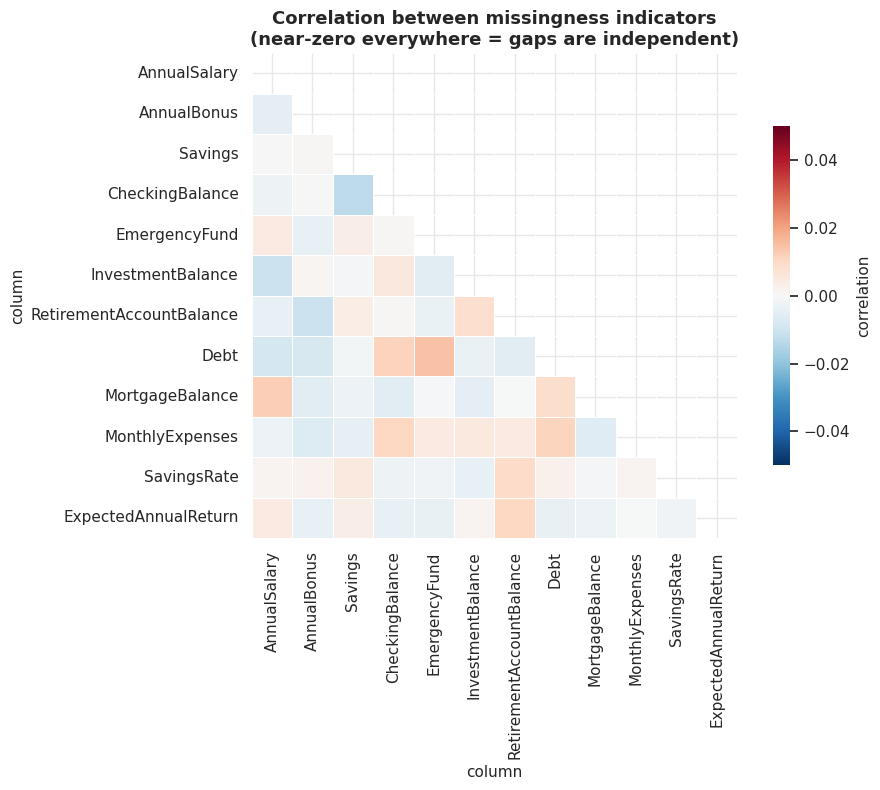

Strongest correlation between any two indicators: +0.0145
Weakest: -0.0129
Mean absolute correlation: 0.0047


In [26]:
# --- Test 2: Are the missingness indicators correlated with each other? ---
flag_correlation = missing_flags.astype(int).corr()

fig, ax = plt.subplots(figsize=(10, 8))
upper_triangle_mask = np.triu(np.ones_like(flag_correlation, dtype=bool))
sns.heatmap(flag_correlation, mask=upper_triangle_mask, cmap="RdBu_r", center=0,
            vmin=-0.05, vmax=0.05, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.7, "label": "correlation"}, ax=ax)
ax.set_title("Correlation between missingness indicators\n"
             "(near-zero everywhere = gaps are independent)")

save_fig("07_missingness_correlation")
plt.show()

off_diagonal = flag_correlation.values[np.triu_indices(len(missing_cols), k=1)]
print(f"Strongest correlation between any two indicators: {off_diagonal.max():+.4f}")
print(f"Weakest: {off_diagonal.min():+.4f}")
print(f"Mean absolute correlation: {np.abs(off_diagonal).mean():.4f}")

### What are we checking?

This step turns the previous EDA observation into a modeling decision. The result below is kept in context rather than treated as a standalone statistic.

**Result: the strongest correlation between any pair of missingness indicators is +0.0145, and
the mean absolute correlation is 0.0047.**

The heatmap is uniformly pale, which is the point. Knowing that a customer's `AnnualSalary` is
missing tells us essentially nothing about whether their `Savings` is also missing. Combined with
Test 1, we can rule out a shared cause.


In [27]:
# --- Test 3: Does missingness depend on the TARGET? (the MNAR check) -----
# This is the test that matters most. If high-value customers were more likely
# to have a blank income field, imputing the median would bias the model.
#
# A raw difference in medians is not enough - with ~450 missing rows per column,
# some difference will appear by chance. So we build a null distribution by
# repeatedly drawing random subsets of the SAME SIZE and measuring the gap.
# That tells us how big a gap is "normal" under pure randomness.
rng = np.random.default_rng(seed=42)
N_PERMUTATIONS = 400
overall_median_target = df[TARGET].median()

permutation_rows = []
for column in missing_cols:
    is_missing = df[column].isna()
    n_missing = int(is_missing.sum())

    observed_gap = (df.loc[is_missing, TARGET].median() /
                    df.loc[~is_missing, TARGET].median()) - 1

    # Null distribution: gaps we would see from random subsets of the same size.
    null_gaps = []
    for _ in range(N_PERMUTATIONS):
        random_rows = rng.choice(len(df), size=n_missing, replace=False)
        random_median = df[TARGET].iloc[random_rows].median()
        null_gaps.append(random_median / overall_median_target - 1)
    null_gaps = np.array(null_gaps)

    # p-value: how often does pure chance produce a gap this large?
    p_value = float((np.abs(null_gaps) >= abs(observed_gap)).mean())

    permutation_rows.append({
        "column": column,
        "n_missing": n_missing,
        "target_gap_pct": round(observed_gap * 100, 2),
        "null_sd_pct": round(null_gaps.std() * 100, 2),
        "p_value": round(p_value, 3),
    })

permutation_test = pd.DataFrame(permutation_rows).set_index("column")
permutation_test = permutation_test.sort_values("p_value")

# With 12 tests we must correct for multiple comparisons, or we will "find"
# significance by chance alone. Bonferroni is the strictest, simplest choice.
BONFERRONI_ALPHA = 0.05 / len(missing_cols)
permutation_test["significant_after_bonferroni"] = (
    permutation_test.p_value < BONFERRONI_ALPHA)

print(f"Permutation test, {N_PERMUTATIONS} draws per column")
print(f"Bonferroni-corrected threshold: p < {BONFERRONI_ALPHA:.4f}\n")
permutation_test

Permutation test, 400 draws per column
Bonferroni-corrected threshold: p < 0.0042



,n_missing,target_gap_pct,null_sd_pct,p_value,significant_after_bonferroni
column,,,,,
AnnualBonus,457,-10.4700,4.5400,0.0250,False
Savings,441,-10.3500,4.6600,0.0250,False
RetirementAccountBalance,438,-6.7200,4.6300,0.1550,False
Debt,447,6.3900,4.4500,0.1700,False
InvestmentBalance,436,-4.7800,4.6300,0.3070,False
MortgageBalance,420,4.3400,4.4400,0.3400,False
AnnualSalary,472,-3.1400,4.3200,0.4600,False
EmergencyFund,445,-2.9000,4.5500,0.5170,False
MonthlyExpenses,473,-1.2500,4.4200,0.7800,False


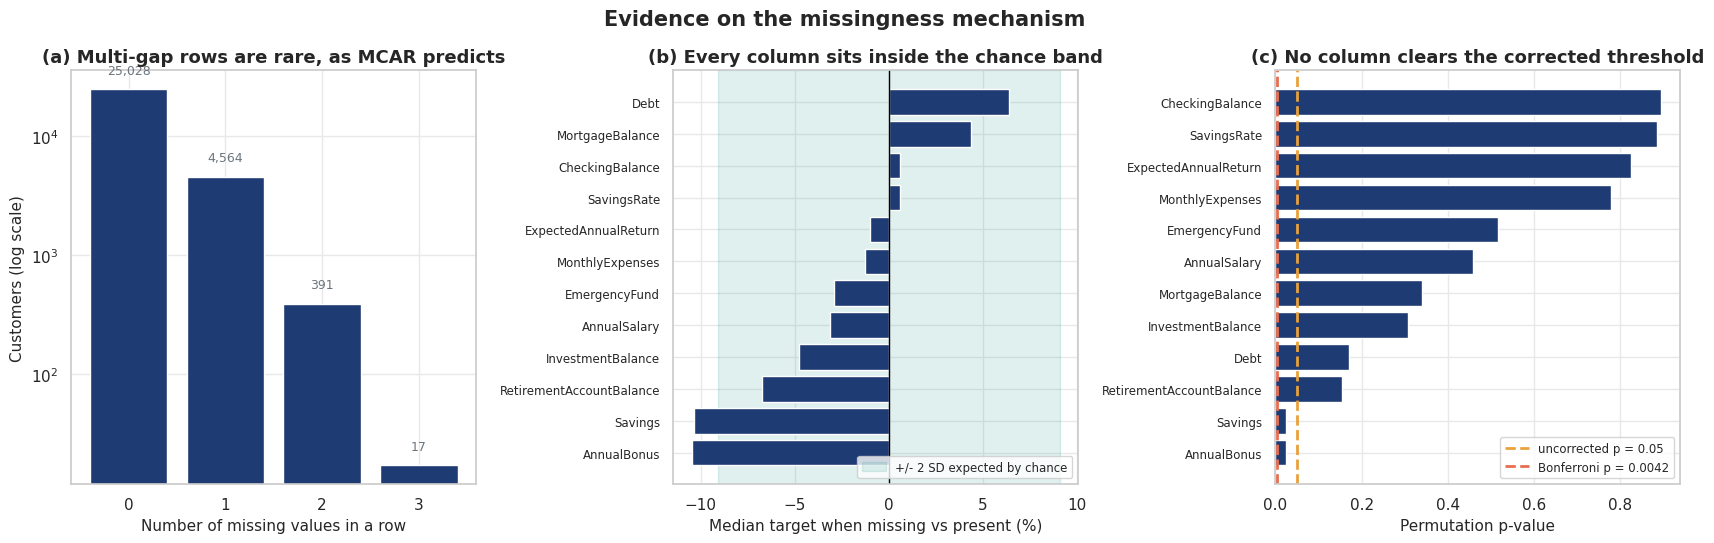

In [28]:
# --- Figure: the evidence for MCAR, in three panels ----------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# (a) Distribution of gaps per row. Under MCAR, multi-gap rows are rare.
row_gap_counts = gaps_per_row.value_counts().sort_index()
axes[0].bar(row_gap_counts.index, row_gap_counts.values, color=NAVY,
            edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_xlabel("Number of missing values in a row")
axes[0].set_ylabel("Customers (log scale)")
axes[0].set_title("(a) Multi-gap rows are rare, as MCAR predicts")
for x, count in zip(row_gap_counts.index, row_gap_counts.values):
    axes[0].text(x, count * 1.35, f"{count:,}", ha="center", fontsize=9,
                 color=SLATE)

# (b) Observed target gap per column, against the +/- 2 SD band we would
#     expect from chance alone. Bars inside the band are indistinguishable
#     from random.
plot_order = permutation_test.sort_values("target_gap_pct")
typical_null_sd = permutation_test.null_sd_pct.mean()
axes[1].axvspan(-2 * typical_null_sd, 2 * typical_null_sd, color=TEAL,
                alpha=0.15, label="+/- 2 SD expected by chance")
bar_colors = np.where(plot_order.significant_after_bonferroni, CORAL, NAVY)
axes[1].barh(plot_order.index, plot_order.target_gap_pct, color=bar_colors,
             edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Median target when missing vs present (%)")
axes[1].set_title("(b) Every column sits inside the chance band")
axes[1].tick_params(axis="y", labelsize=8.5)
axes[1].legend(fontsize=8.5, loc="lower right")

# (c) p-values against the corrected threshold.
p_order = permutation_test.sort_values("p_value")
axes[2].barh(p_order.index, p_order.p_value, color=NAVY, edgecolor="white")
axes[2].axvline(0.05, color=AMBER, ls="--", lw=2, label="uncorrected p = 0.05")
axes[2].axvline(BONFERRONI_ALPHA, color=CORAL, ls="--", lw=2,
                label=f"Bonferroni p = {BONFERRONI_ALPHA:.4f}")
axes[2].set_xlabel("Permutation p-value")
axes[2].set_title("(c) No column clears the corrected threshold")
axes[2].tick_params(axis="y", labelsize=8.5)
axes[2].legend(fontsize=8.5)

fig.suptitle("Evidence on the missingness mechanism", fontsize=15,
             fontweight="bold")
save_fig("08_missingness_mechanism")
plt.show()

### Verdict: the evidence is consistent with MCAR

### What this tells us All three tests point the same way.

| Test | What MAR/MNAR would look like | What we observe |
|---|---|---|
| Rows with multiple gaps | More than independence predicts | 25,028 complete vs 25,026 expected (**+0.006%**) |
| Correlation between gap indicators | Clear positive blocks | Max **+0.0145**, mean absolute **0.0047** |
| Target shift when a feature is missing | A consistent, significant shift | **10 of 12 columns have p > 0.05**; the two smallest p-values (`AnnualBonus` and `Savings`, both p = 0.025) do **not** survive Bonferroni correction (p < 0.0042) |

**The third test deserves a note on honesty.** Two of twelve columns show a target gap of about
−10% when the value is missing, and taken alone each would look "significant" at the conventional
0.05 threshold. But running 12 tests at α = 0.05 means we expect roughly 0.6 false positives by
chance; finding 2 marginal ones is unremarkable. Neither clears the corrected threshold of
0.0042. Panel (b) shows every column's gap falling inside the ±2 SD band that pure chance
produces.

Reporting "we found two significant MNAR signals" here would be a multiple-comparisons error.
Reporting "the data is consistent with MCAR, with two marginal cases worth re-checking on a
larger sample" is the accurate statement.

### Why it matters Under MCAR, median imputation is *unbiased*. Under MAR or MNAR it is not, and
we would need conditional imputation or missingness indicators to avoid distorting the model.

### ML takeaway Low complexity, high confidence. One honest caveat:
**MCAR cannot be proven, only failed to be rejected** — these tests only detect dependence on
variables we observe.

### Recommended imputation strategy

| Variable(s) | Strategy | Reasoning |
|---|---|---|
| `Savings`, `InvestmentBalance`, `RetirementAccountBalance`, `CheckingBalance`, `EmergencyFund`, `AnnualBonus` | **Median** | Skew of +0.9 to +4.3 makes the mean unrepresentative. `InvestmentBalance` has a median of USD 52,915 against a mean of USD 119,898 — imputing the mean would insert values above the 70th percentile. |
| `AnnualSalary`, `MonthlyExpenses` | **Median** | Only mildly skewed, but median keeps the approach uniform and costs nothing. |
| `Debt`, `MortgageBalance` | **Zero, plus a `WasMissing` flag** | 28.9% and 38.8% of these are *already* zero. For a genuinely debt-free customer whose value was blanked, zero is the more likely truth than the USD 10,244 median. Flag the imputation so the model can learn whether it matters. |
| `SavingsRate` | **Median (0.0834)** | Near-symmetric; median and mean agree to three decimals. |
| `ExpectedAnnualReturn` | **Median (0.0843)**, or predict from `RiskTolerance` | The one column where conditional imputation is defensible: it correlates **+0.84** with the fully observed `RiskTolerance`, so a regression imputation would be materially more accurate. With only 1.49% missing, the benefit is small — but it is a real option. |

**Two implementation rules that matter more than the choice of statistic:**

1. **Fit the imputer on the training fold only.** Computing a median over the full dataset before
   splitting leaks test-set information into training. A small leak, but an avoidable one.
2. **Do not drop incomplete rows.** Listwise deletion would discard 4,972 customers (16.6%) to
   fix 0.56% of cells. Under MCAR that loses statistical power for no reduction in bias.


# 6. Outlier Analysis

### What are we doing?

Extreme values are not automatically errors. In financial data, a very large balance may describe a legitimate customer. We therefore investigate the extremes before deciding what to do with them.


In [29]:
# --- Outlier counts under the 1.5 x IQR rule ------------------------------
outlier_rows = []
for column in numeric_cols:
    values = df[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    n_below = int((values < lower_fence).sum())
    n_above = int((values > upper_fence).sum())

    outlier_rows.append({
        "column": column,
        "n_below": n_below,
        "n_above": n_above,
        "pct_flagged": round((n_below + n_above) / len(values) * 100, 2),
        "upper_fence": round(upper_fence),
        "max_value": round(values.max()),
        "skewness": round(values.skew(), 2),
    })

outliers = pd.DataFrame(outlier_rows).set_index("column")
outliers = outliers.sort_values("pct_flagged", ascending=False)
outliers.head(15)

,n_below,n_above,pct_flagged,upper_fence,max_value,skewness
column,,,,,,
InvestmentBalance,0,2545,8.6100,346426,3597319,4.2600
CheckingBalance,0,2442,8.2700,33922,150000,3.7300
Savings,0,1932,6.5400,658093,3500000,3.1000
RetirementAccountBalance,0,1549,5.2400,2569472,12000000,2.3500
Funding_Gap,157,1385,5.1400,5315964,32543308,1.5900
CreditScore,1495,23,5.0600,848,850,-1.4100
Expected_Retirement_Fund,0,1234,4.1100,10644432,40078282,1.8500
Readiness_Score,0,1069,3.5600,3,9,1.5600
AnnualBonus,0,985,3.3300,53194,147242,1.5800


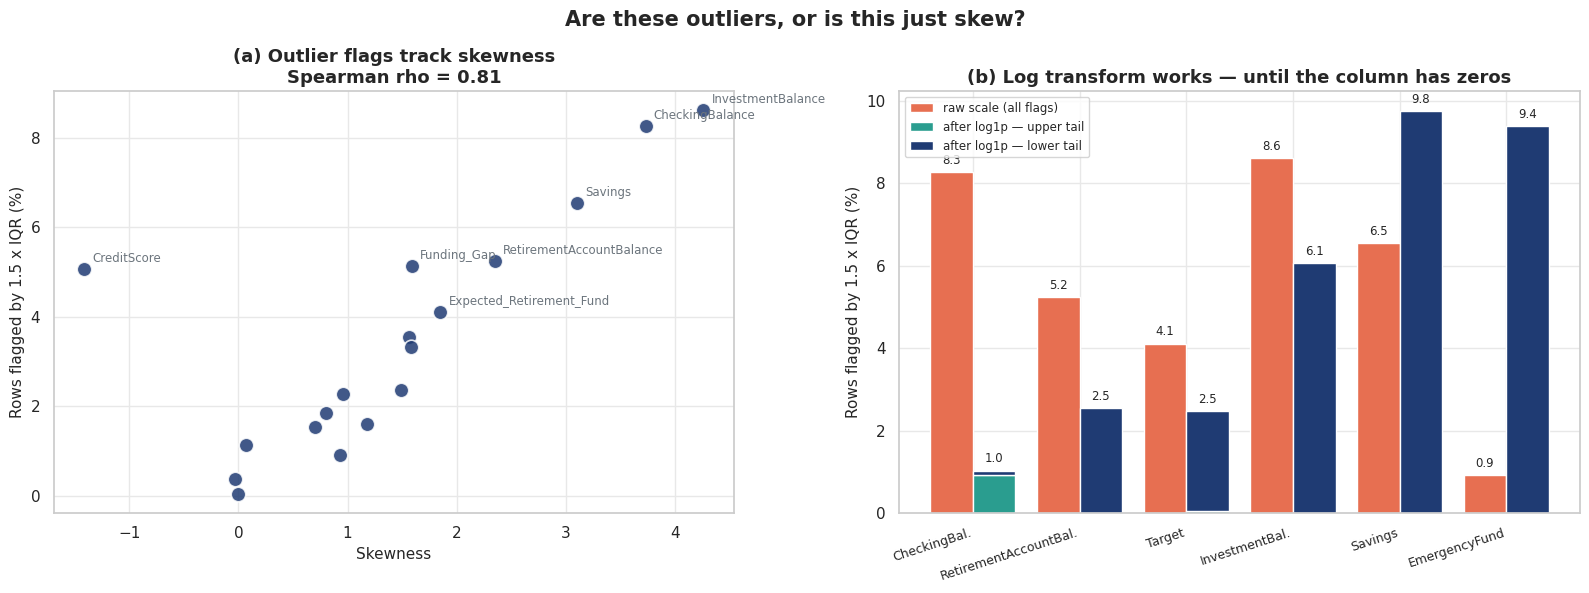

In [30]:
# --- Figure: does the IQR rule flag skew, or genuine anomalies? ----------
flagged = outliers[outliers.pct_flagged > 0]
rank_correlation = flagged[["skewness", "pct_flagged"]].corr(
    method="spearman").iloc[0, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# (a) If outlier counts track skewness, then "outlier count" is largely a
#     restatement of asymmetry rather than a finding about the data.
axes[0].scatter(flagged.skewness, flagged.pct_flagged, s=110, color=NAVY,
                alpha=0.85, edgecolor="white", linewidth=1.2, zorder=3)
for name, row in flagged.iterrows():
    if row.pct_flagged > 4 or abs(row.skewness) > 2.5:
        axes[0].annotate(name, (row.skewness, row.pct_flagged), fontsize=8.5,
                         xytext=(6, 5), textcoords="offset points", color=SLATE)
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Rows flagged by 1.5 x IQR (%)")
axes[0].set_title(f"(a) Outlier flags track skewness\n"
                  f"Spearman rho = {rank_correlation:.2f}")

# (b) The same data before and after log1p. We split the "after" bar into
#     lower- and upper-tail flags, because the two behave very differently
#     and that difference is the real finding.
transform_test_cols = ["CheckingBalance", "RetirementAccountBalance",
                       "Expected_Retirement_Fund", "InvestmentBalance",
                       "Savings", "EmergencyFund"]
before_pct, after_low_pct, after_high_pct = [], [], []
for column in transform_test_cols:
    values = df[column].dropna()
    before_pct.append(outliers.loc[column, "pct_flagged"])

    logged = np.log1p(values)
    q1, q3 = logged.quantile([0.25, 0.75])
    iqr = q3 - q1
    after_low_pct.append(round((logged < q1 - 1.5 * iqr).mean() * 100, 2))
    after_high_pct.append(round((logged > q3 + 1.5 * iqr).mean() * 100, 2))

x_positions = np.arange(len(transform_test_cols))
axes[1].bar(x_positions - 0.2, before_pct, 0.4, label="raw scale (all flags)",
            color=CORAL, edgecolor="white")
axes[1].bar(x_positions + 0.2, after_high_pct, 0.4,
            label="after log1p — upper tail", color=TEAL, edgecolor="white")
axes[1].bar(x_positions + 0.2, after_low_pct, 0.4, bottom=after_high_pct,
            label="after log1p — lower tail", color=NAVY, edgecolor="white")

short_labels = [c.replace("Balance", "Bal.").replace("Expected_Retirement_Fund", "Target")
                for c in transform_test_cols]
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(short_labels, rotation=18, ha="right", fontsize=9)
axes[1].set_ylabel("Rows flagged by 1.5 x IQR (%)")
axes[1].set_title("(b) Log transform works — until the column has zeros")
axes[1].legend(fontsize=8.5)
for i, (raw, low, high) in enumerate(zip(before_pct, after_low_pct, after_high_pct)):
    axes[1].text(i - 0.2, raw + 0.2, f"{raw:.1f}", ha="center", fontsize=8.5)
    axes[1].text(i + 0.2, low + high + 0.2, f"{low + high:.1f}", ha="center",
                 fontsize=8.5)

fig.suptitle("Are these outliers, or is this just skew?", fontsize=15,
             fontweight="bold")
save_fig("09_outlier_analysis")
plt.show()

### What we learned

### What this tells us Panel (a) confirms the first argument: **Spearman ρ = 0.81** between a
variable's skewness and the share of rows the IQR rule flags. Outlier counts here are
substantially a restatement of asymmetry, not a discovery about the data.

Panel (b) was expected to close the case by showing `log1p` collapsing every flag rate. It does
not, and the exception is more interesting than the rule. Note that the six columns are ordered
deliberately — the first three have **no zeros**, the last three do:

| Variable | Zeros | Raw flagged | After `log1p` | Upper-tail | Lower-tail |
|---|---|---|---|---|---|
| `CheckingBalance` | **0** | 8.27% | **1.03%** | 275 | 29 |
| `RetirementAccountBalance` | **0** | 5.24% | **2.54%** | 0 | 750 |
| `Expected_Retirement_Fund` | **0** | 4.11% | **2.48%** | 12 | 732 |
| `InvestmentBalance` | 1,195 | 8.61% | **6.06%** | **0** | **1,793** |
| `Savings` | 2,643 | 6.54% | **9.75% (worse)** | **0** | **2,883** |
| `EmergencyFund` | 2,649 | 0.92% | **9.39% (far worse)** | **0** | **2,774** |

**The upper tail vanishes for five of the six variables.** Not a single high-side flag survives
the transform in `Savings`, `InvestmentBalance`, `RetirementAccountBalance`, or `EmergencyFund`.
The multi-million-dollar balances were never anomalies; they were an artefact of measuring an
asymmetric variable with a symmetric ruler.

**But `EmergencyFund` goes from 0.92% flagged to 9.39% — a tenfold increase.** The mechanism is
the zero-inflation identified in Section 4. `log1p(0) = 0`, so the 2,649 customers with no
emergency fund all collapse onto a single point at the bottom of the transformed scale while
everyone else spreads out above them. The distribution flips from right-skewed to left-skewed,
and the IQR rule dutifully flags the new tail — **2,774 low-side flags, of which 2,649 are
customers whose emergency fund is exactly zero.**

### Why it matters The rule generalises cleanly and is worth remembering beyond this dataset:

> **`log1p` fixes right skew. It does not fix zero-inflation — it relocates it.**

Columns with no zeros (`CheckingBalance`, `RetirementAccountBalance`) improve dramatically.
Columns with a large zero mass (`Savings`, `EmergencyFund`) get worse.

### ML takeaway The correct treatment for `Savings`, `InvestmentBalance`,
`EmergencyFund`, `Debt`, and `MortgageBalance` is a **two-part representation** — a binary
`Has*` indicator plus `log1p` of the amount — not a transform alone. `CheckingBalance` and
`RetirementAccountBalance` can take a plain `log1p`. Section 10 develops this.


In [31]:
# --- Who are the extreme customers? ---------------------------------------
# Rather than counting flags, inspect the top 1% of the target and ask whether
# they look like data errors or like a coherent, explainable customer type.
top_1pct_threshold = df[TARGET].quantile(0.99)
top_customers = df[df[TARGET] >= top_1pct_threshold]
other_customers = df[df[TARGET] < top_1pct_threshold]

profile_cols = ["Age", "AnnualSalary", "SavingsRate", "Savings",
                "RetirementAccountBalance", "InvestmentBalance", "CreditScore",
                "ExpectedAnnualReturn", TARGET]

profile = pd.DataFrame({
    "top_1_percent": top_customers[profile_cols].median(),
    "everyone_else": other_customers[profile_cols].median(),
})
profile["ratio"] = (profile.top_1_percent / profile.everyone_else).round(2)

share_of_wealth = top_customers[TARGET].sum() / df[TARGET].sum() * 100
print(f"Top 1% of customers by target: n = {len(top_customers):,}")
print(f"They hold {share_of_wealth:.1f}% of total projected retirement wealth\n")
print("Median profile comparison:")
profile.round(4)

Top 1% of customers by target: n = 300
They hold 4.5% of total projected retirement wealth

Median profile comparison:


,top_1_percent,everyone_else,ratio
column,,,
Age,48.0000,46.0000,1.0400
AnnualSalary,"261,503.2100","126,261.1400",2.0700
SavingsRate,0.1424,0.0829,1.7200
Savings,"742,646.5400","114,917.8900",6.4600
RetirementAccountBalance,"2,217,822.1700","532,759.3100",4.1600
InvestmentBalance,"535,210.1700","51,815.3700",10.3300
CreditScore,763.5000,708.0000,1.0800
ExpectedAnnualReturn,0.0920,0.0841,1.0900
Expected_Retirement_Fund,"17,274,509.3300","3,276,968.4150",5.2700


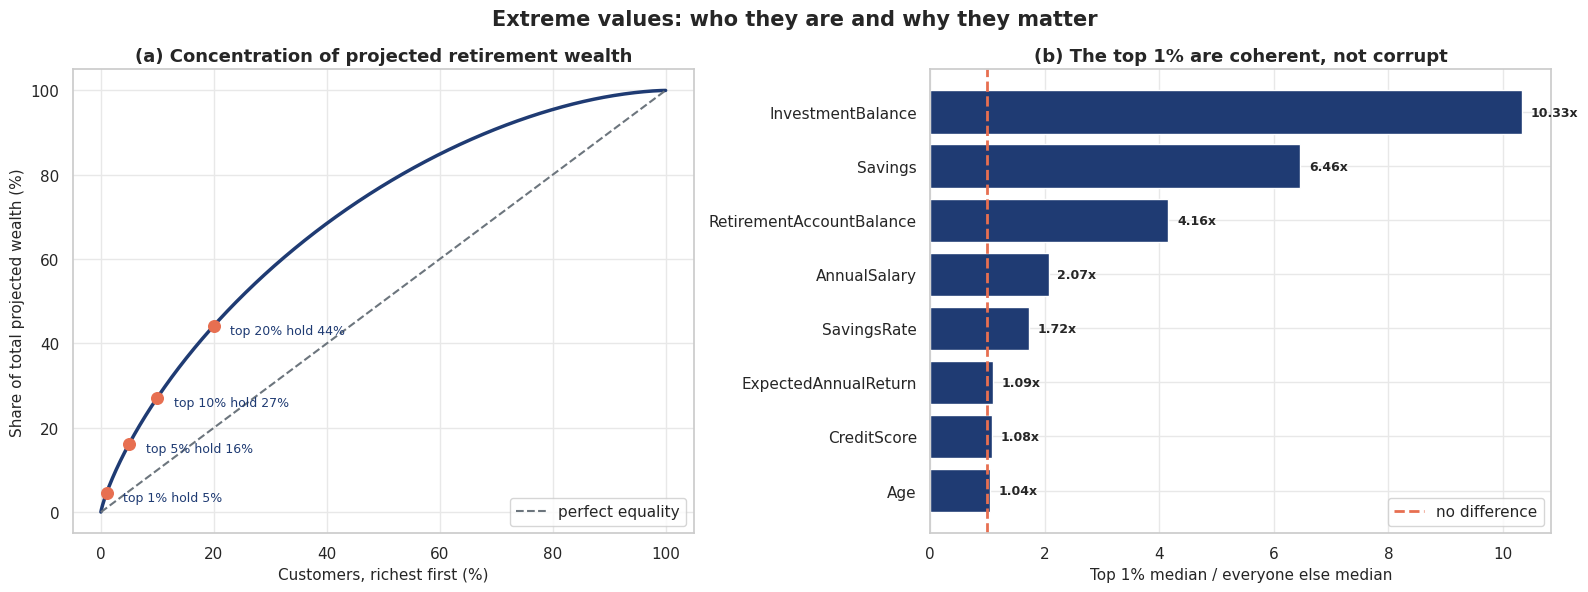

In [32]:
# --- Figure: where does the projected wealth actually sit? ---------------
sorted_target = df[TARGET].sort_values(ascending=False).reset_index(drop=True)
cumulative_share = sorted_target.cumsum() / sorted_target.sum() * 100
customer_share = (np.arange(1, len(sorted_target) + 1) / len(sorted_target)) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(customer_share, cumulative_share, color=NAVY, lw=2.5)
axes[0].plot([0, 100], [0, 100], ls="--", color=SLATE, lw=1.5,
             label="perfect equality")
for pct in [1, 5, 10, 20]:
    index_at_pct = int(len(sorted_target) * pct / 100) - 1
    share_at_pct = cumulative_share.iloc[index_at_pct]
    axes[0].scatter([pct], [share_at_pct], s=70, color=CORAL, zorder=5)
    axes[0].annotate(f"top {pct}% hold {share_at_pct:.0f}%", (pct, share_at_pct),
                     fontsize=9, xytext=(12, -6), textcoords="offset points",
                     color=NAVY)
axes[0].set_xlabel("Customers, richest first (%)")
axes[0].set_ylabel("Share of total projected wealth (%)")
axes[0].set_title("(a) Concentration of projected retirement wealth")
axes[0].legend(loc="lower right")

# (b) The top 1% profile as ratios, so "are these errors?" is answerable
#     at a glance: every input moves in the wealth-increasing direction.
ratio_view = profile.drop(index=TARGET).sort_values("ratio")
bars = axes[1].barh(ratio_view.index, ratio_view.ratio, color=NAVY,
                    edgecolor="white")
axes[1].axvline(1.0, color=CORAL, ls="--", lw=2, label="no difference")
axes[1].set_xlabel("Top 1% median / everyone else median")
axes[1].set_title("(b) The top 1% are coherent, not corrupt")
axes[1].legend()
for bar, value in zip(bars, ratio_view.ratio):
    axes[1].text(value + 0.15, bar.get_y() + bar.get_height() / 2,
                 f"{value:.2f}x", va="center", fontsize=9, fontweight="bold")

fig.suptitle("Extreme values: who they are and why they matter",
             fontsize=15, fontweight="bold")
save_fig("10_wealth_concentration")
plt.show()

### Verdict on outliers: keep them all. Here is the evidence.

### What this tells us Panel (b) answers the question directly. The top 1% median profile is
exactly what a high-projection customer *should* look like: salary of **USD 261,503 versus
USD 126,261** for everyone else (2.07×), investment balance **USD 535,210 versus USD 51,815** (10.33×),
savings **USD 742,647 versus USD 114,918** (6.46×), retirement account balance **USD 2.22M versus USD 533K**
(4.16×), and a savings rate of **14.2% versus 8.3%** (1.72×).

**Every single input moves in the direction that would produce a large fund.** If these were data
errors, we would expect at least one input to be inconsistent — a USD 30M projection sitting on a
USD 40K salary. There is no such case. And note that `Age` is essentially unchanged at **1.04×**:
these are not simply older customers who have had longer to save.

Panel (a) shows the commercial stakes: the top 1% (300 customers) hold **4.5%** of all projected
retirement wealth, the top 10% hold **27.2%**, and the top 20% hold **44.2%**.

### Why it matters Deleting the flagged rows would discard 4.1% of customers and, at the top
decile, 27% of the wealth being modelled — to fix a problem created by the diagnostic rather than
by the data.

### ML takeaway

| Approach | Verdict |
|---|---|
| Delete outlier rows | **No.** Discards the most commercially important customers. |
| Winsorize / clip at p99 | **No.** Already applied upstream by the generator (Section 2). |
| Log-transform skewed features and the target | **Yes**, with the zero-inflation caveat above. |
| Use tree-based models | **Yes.** They split on rank order and are inherently robust to magnitude. |
| Report metrics separately for the top decile | **Yes.** If the model degrades there, that is a real finding to surface, not one to hide. |

**The one genuine caution:** the 55 customers at exactly USD 150,000 `CheckingBalance` and the 78 at
exactly USD 1,300,000 `MortgageBalance` are **censored**, not extreme. Their true values are unknown
and at least that large. This warrants an `IsCapped` indicator, and it should be known before
anyone interprets a coefficient on those variables.


# 7. Correlation Analysis

### What are we doing?

Correlation helps us identify redundant predictors and understand how variables move together. We compare linear and rank-based relationships because a strong relationship does not have to be a straight line.


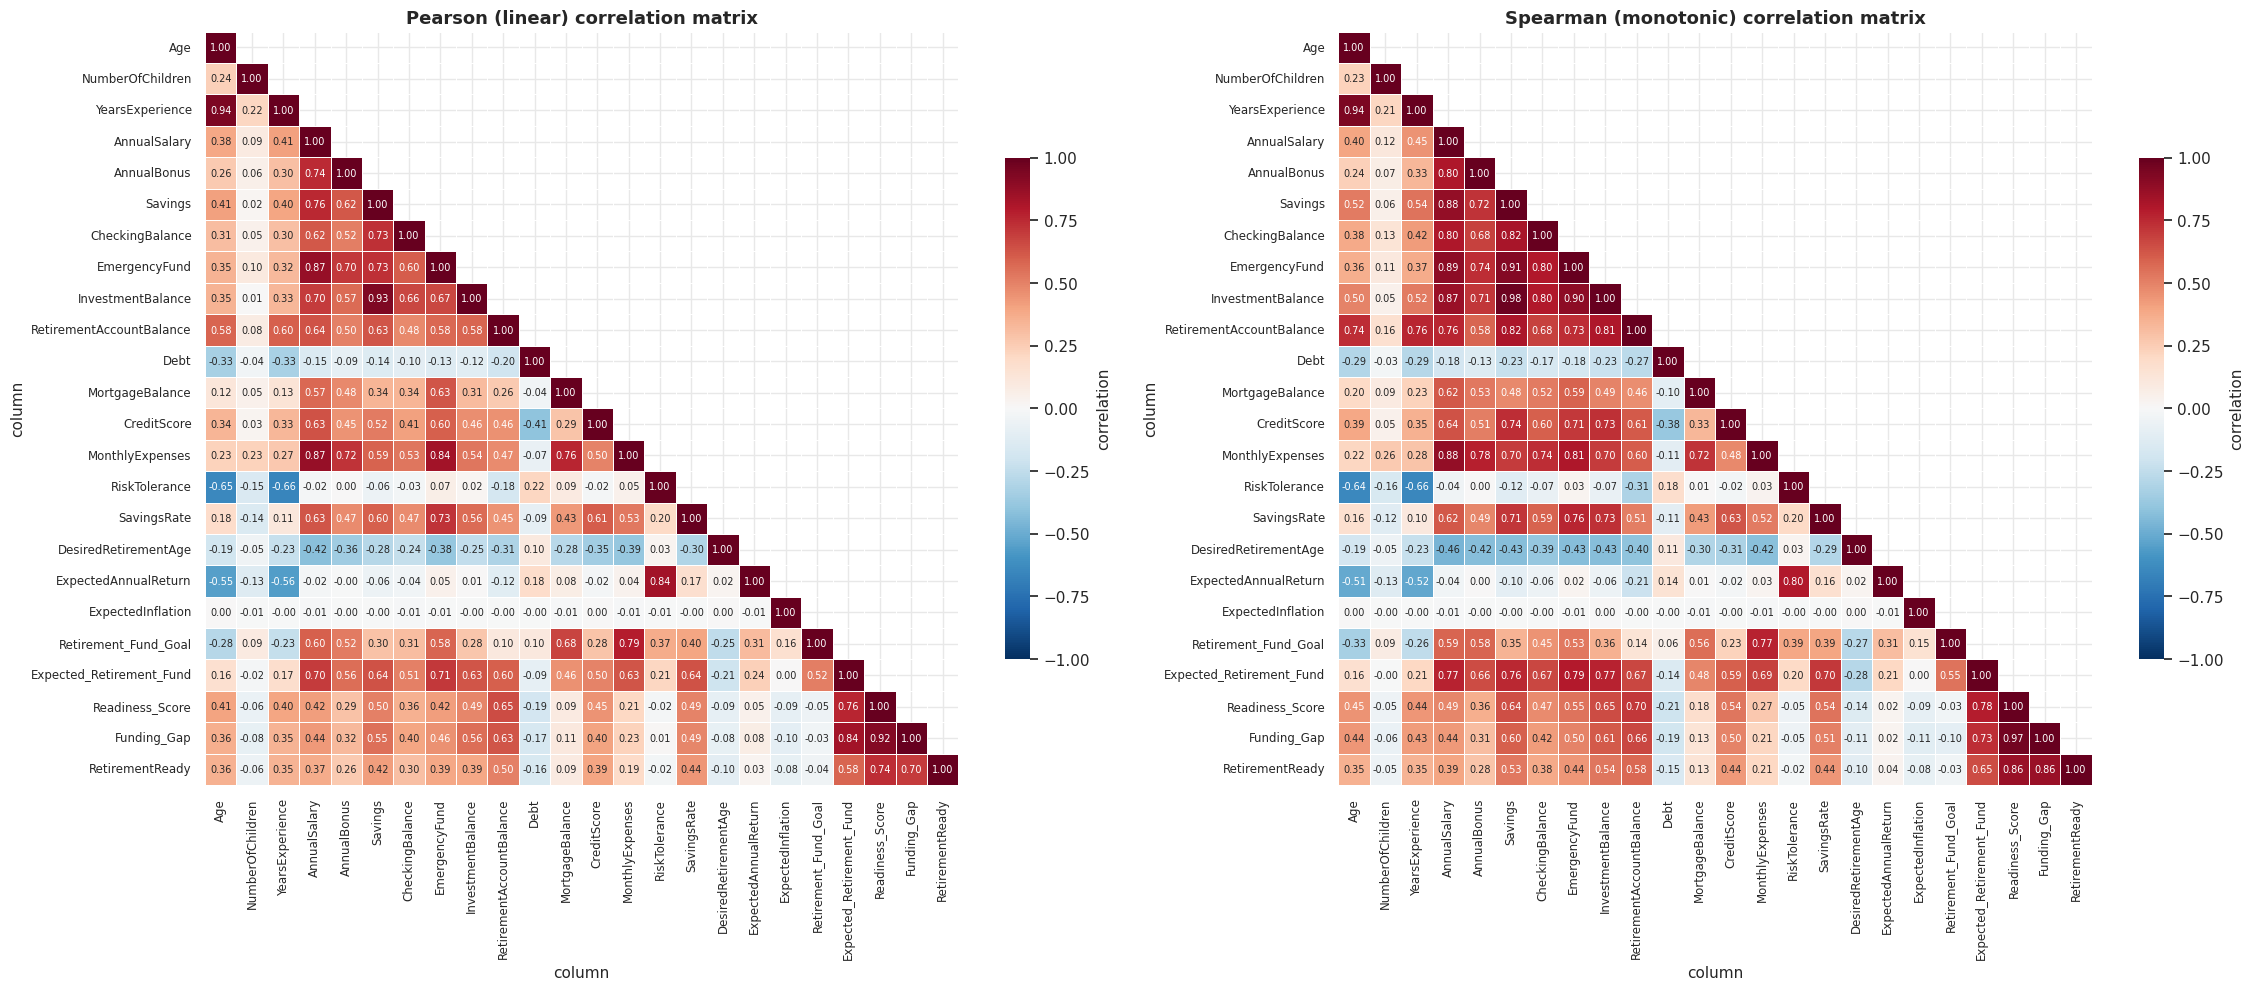

In [33]:
# --- Pearson and Spearman side by side ------------------------------------
# RetirementReady is added back here specifically so its leakage shows up in
# the heatmap. CustomerID stays out - it is a row key, and any correlation it
# shows would be meaningless.
correlation_cols = list(numeric_cols) + ["RetirementReady"]
pearson = df[correlation_cols].corr(method="pearson")
spearman = df[correlation_cols].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(23, 10))
upper_mask = np.triu(np.ones_like(pearson, dtype=bool), k=1)

for ax, matrix, name in [(axes[0], pearson, "Pearson (linear)"),
                         (axes[1], spearman, "Spearman (monotonic)")]:
    sns.heatmap(matrix, mask=upper_mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.4, annot=True, fmt=".2f",
                annot_kws={"size": 7},
                cbar_kws={"shrink": 0.6, "label": "correlation"}, ax=ax)
    ax.set_title(f"{name} correlation matrix", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", labelsize=8.5, rotation=90)
    ax.tick_params(axis="y", labelsize=8.5, rotation=0)

save_fig("11_correlation_heatmap")
plt.show()

### Reading the heatmaps

### What this tells us Three things are visible before we compute a single ranking.

1. **The bottom-right block is the leakage.** `Retirement_Fund_Goal`,
   `Expected_Retirement_Fund`, `Readiness_Score`, `Funding_Gap`, and `RetirementReady` form a
   dense red cluster because four of the five are arithmetic functions of the other. Section 11
   proves this. A block like that in a correlation matrix should always prompt the question
   "which of these is derived from which?"
2. **A wealth block in the middle.** `Savings`, `InvestmentBalance`, `EmergencyFund`,
   `CheckingBalance`, and `AnnualSalary` all co-move — the ordinary structure of financial data,
   where richer customers hold more of everything.
3. **A time block at the top left.** `Age`, `YearsExperience`, and `DesiredRetirementAge` relate
   to each other but show pale cells against the target column, which is the puzzle Section 8
   resolves.

**Why comparing the two panels matters.** Spearman is visibly *stronger* than Pearson for the
skewed balance columns — `Savings` ↔ `EmergencyFund` reads 0.73 in Pearson and 0.92 in Spearman.
That gap is not noise; it means the relationship is monotonic but curved, and it is the
signature a log transform removes.

### ML takeaway The heatmap is the reference for the two decisions that follow:
which columns to drop for redundancy (below) and which to log-transform (Section 6).


In [34]:
# --- Strongest feature-to-feature relationships ---------------------------
# The three KPI columns are computed FROM the target (Section 11), so including
# them here would only restate that fact rather than tell us about the features.
LEAKAGE_COLS = ["Readiness_Score", "Funding_Gap", "RetirementReady"]
feature_cols = [c for c in correlation_cols
                if c not in LEAKAGE_COLS + [TARGET, "Retirement_Fund_Goal"]]

feature_correlation = pearson.loc[feature_cols, feature_cols]
upper_triangle = np.triu(np.ones(feature_correlation.shape), k=1).astype(bool)
pairs = feature_correlation.where(upper_triangle).stack()
pairs = pairs.sort_values(key=abs, ascending=False)

top_pairs = pairs.head(12).rename("pearson_r").to_frame()
top_pairs["spearman_r"] = [spearman.loc[a, b] for a, b in top_pairs.index]

print("Strongest feature-to-feature relationships:\n")
print(top_pairs.round(4).to_string())
print(f"\nPairs with |r| >= 0.90: {(pairs.abs() >= 0.90).sum()}")
print(f"Pairs with |r| >= 0.75: {(pairs.abs() >= 0.75).sum()}")
print(f"Pairs with |r| >= 0.50: {(pairs.abs() >= 0.50).sum()}")
print(f"Total feature pairs examined: {len(pairs)}")

Strongest feature-to-feature relationships:

                                      pearson_r  spearman_r
column          column                                     
Age             YearsExperience          0.9437      0.9394
Savings         InvestmentBalance        0.9309      0.9803
AnnualSalary    MonthlyExpenses          0.8717      0.8806
                EmergencyFund            0.8691      0.8937
RiskTolerance   ExpectedAnnualReturn     0.8435      0.8005
EmergencyFund   MonthlyExpenses          0.8380      0.8100
MortgageBalance MonthlyExpenses          0.7644      0.7209
AnnualSalary    Savings                  0.7575      0.8772
                AnnualBonus              0.7428      0.8048
Savings         CheckingBalance          0.7299      0.8215
                EmergencyFund            0.7286      0.9150
EmergencyFund   SavingsRate              0.7253      0.7584

Pairs with |r| >= 0.90: 2
Pairs with |r| >= 0.75: 8
Pairs with |r| >= 0.50: 46
Total feature pairs examined: 171


In [35]:
# --- Are any columns exact duplicates of each other? ---------------------
# The previous dataset version contained three exact identities. A high
# correlation could be a strong relationship OR an exact identity, and the
# difference matters enormously - so we test the specific hypotheses directly
# instead of inferring from the coefficient.
print("Testing the identities that existed in the PREVIOUS dataset version:\n")

print("1. Is any column equal to (AnnualSalary + AnnualBonus) / 12?")
print(f"   'MonthlyIncome' present in this dataset: "
      f"{'MonthlyIncome' in df.columns}  -> column was REMOVED\n")

print("2. Is any column equal to (DesiredRetirementAge - Age)?")
print(f"   'YearsUntilRetirement' present: "
      f"{'YearsUntilRetirement' in df.columns}  -> column was REMOVED")
print("   (This must now be ENGINEERED - see Section 10.)\n")

print("3. Do any two numeric feature columns agree to within rounding?")
exact_duplicate_pairs = []
for column_a, column_b in pairs.head(30).index:
    both_present = df[[column_a, column_b]].dropna()
    if len(both_present) == 0:
        continue
    max_difference = (both_present[column_a] - both_present[column_b]).abs().max()
    typical_scale = both_present[column_a].abs().median()
    # "Effectively identical" = differences are negligible next to the values.
    if typical_scale > 0 and max_difference / typical_scale < 0.001:
        exact_duplicate_pairs.append((column_a, column_b, max_difference))

if exact_duplicate_pairs:
    for a, b, diff in exact_duplicate_pairs:
        print(f"   IDENTITY FOUND: {a} == {b} (max diff {diff})")
else:
    print("   None. No feature column duplicates another.\n")
    print("   VERDICT: the redesign eliminated all exact-identity redundancy.")

Testing the identities that existed in the PREVIOUS dataset version:

1. Is any column equal to (AnnualSalary + AnnualBonus) / 12?
   'MonthlyIncome' present in this dataset: False  -> column was REMOVED

2. Is any column equal to (DesiredRetirementAge - Age)?
   'YearsUntilRetirement' present: False  -> column was REMOVED
   (This must now be ENGINEERED - see Section 10.)

3. Do any two numeric feature columns agree to within rounding?
   None. No feature column duplicates another.

   VERDICT: the redesign eliminated all exact-identity redundancy.


### What we learned

### What this tells us The redesign fixed the redundancy problem that dominated the previous
version of this analysis. Where the earlier dataset had **three exact mathematical identities**
among its columns, this one has **none**.

**Tier 1: strong but genuine relationships (|r| ≥ 0.90) — only two pairs remain.**

- `Age` ↔ `YearsExperience`: **r = +0.9437**. Related but not identical — the difference
  (`Age − YearsExperience`, i.e. career start age) ranges from 18 upward and carries real
  information, which Section 8 puts to use in explaining the education anomaly.
- `Savings` ↔ `InvestmentBalance`: **r = +0.9309**. Both are discretionary wealth stocks and
  co-move strongly, but neither determines the other.

**Tier 2: strong economic co-movement (r ≈ 0.75 to 0.87).**
`AnnualSalary` ↔ `MonthlyExpenses` (**+0.8717**), `AnnualSalary` ↔ `EmergencyFund` (**+0.8691**),
`EmergencyFund` ↔ `MonthlyExpenses` (**+0.8380**), `MortgageBalance` ↔ `MonthlyExpenses`
(**+0.7644**), `AnnualSalary` ↔ `Savings` (**+0.7575**). These are real and expected — wealth
co-moves — but they still inflate variance in a linear model.

**Tier 3: a designed behavioural link.**
`RiskTolerance` ↔ `ExpectedAnnualReturn` = **+0.8435**. This encodes the standard
financial-planning heuristic that expected return is set from risk appetite. It is a *designed*
chain in the generator, not an empirical discovery about savers, and should be named as such.

### Why it matters Multicollinearity has two distinct consequences that are often conflated:

- **It does not hurt predictive accuracy.** A tree ensemble simply splits on whichever correlated
  feature is convenient. Out-of-sample RMSE is essentially unaffected.
- **It does destroy interpretability.** With two features explaining the same variance, the split
  between their coefficients is determined by noise and can flip sign between cross-validation
  folds.

### ML takeaway Compared with the previous version, this is a substantial upgrade:
**2 pairs above |r| = 0.90 (was 5), 8 above 0.75 (was 20), and 46 above 0.50 (was 68)** out of
171 pairs examined. Linear models are now viable without aggressive pruning. The one
recommendation that remains is to replace the `Age` / `YearsExperience` pair with `Age` plus an
engineered `CareerStartAge = Age − YearsExperience`, which decorrelates them while keeping the
signal (Section 10).


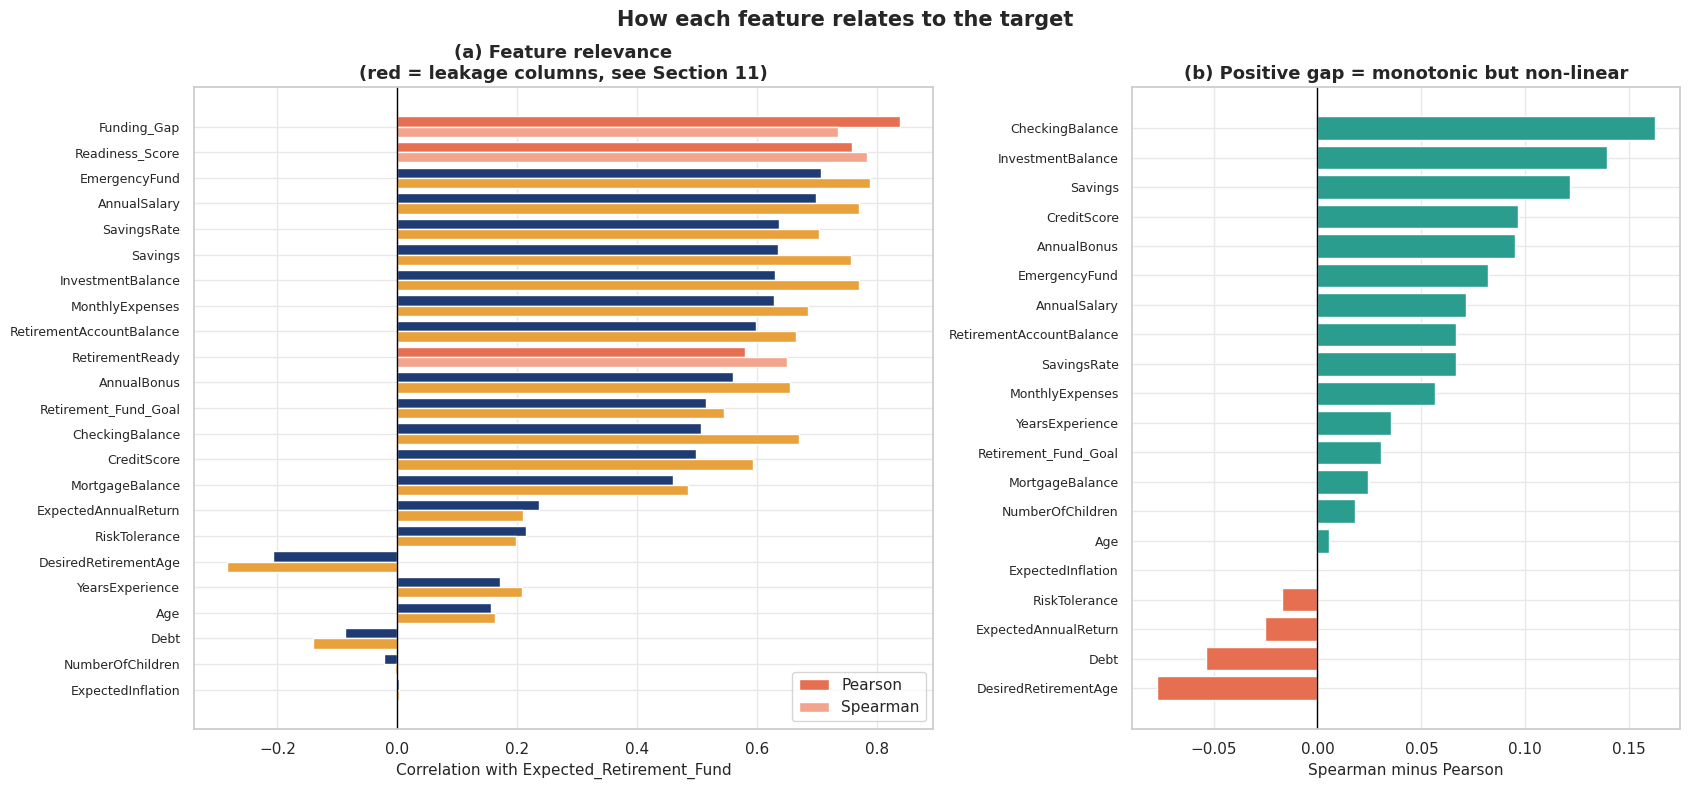

,pearson,spearman,gap
column,,,
Funding_Gap,0.8386,0.7348,-0.1039
Readiness_Score,0.7583,0.7840,0.0257
EmergencyFund,0.7074,0.7893,0.0819
AnnualSalary,0.6995,0.7710,0.0715
SavingsRate,0.6370,0.7036,0.0665
Savings,0.6360,0.7578,0.1217
InvestmentBalance,0.6304,0.7698,0.1394
MonthlyExpenses,0.6294,0.6860,0.0566
RetirementAccountBalance,0.5987,0.6654,0.0667


In [36]:
# --- Figure: correlation with the target, Pearson vs Spearman ------------
# Where Spearman exceeds Pearson, the relationship is monotonic but curved.
target_correlation = pd.DataFrame({
    "pearson": pearson[TARGET].drop(TARGET),
    "spearman": spearman[TARGET].drop(TARGET),
})
target_correlation["gap"] = (target_correlation.spearman -
                             target_correlation.pearson)
target_correlation = target_correlation.reindex(
    target_correlation.pearson.abs().sort_values(ascending=False).index)

fig, axes = plt.subplots(1, 2, figsize=(17, 8),
                         gridspec_kw={"width_ratios": [1.35, 1]})

# We show the KPI columns here in a contrasting colour, because seeing them at
# the top of the ranking is exactly how leakage announces itself in practice.
plot_data = target_correlation.copy()
is_leakage = plot_data.index.isin(LEAKAGE_COLS)
y_positions = np.arange(len(plot_data))

axes[0].barh(y_positions - 0.2, plot_data.pearson, 0.4, label="Pearson",
             color=np.where(is_leakage, CORAL, NAVY))
axes[0].barh(y_positions + 0.2, plot_data.spearman, 0.4, label="Spearman",
             color=np.where(is_leakage, "#F2A48C", AMBER))
axes[0].set_yticks(y_positions)
axes[0].set_yticklabels(plot_data.index, fontsize=9)
axes[0].invert_yaxis()
axes[0].axvline(0, color="black", lw=1)
axes[0].set_xlabel("Correlation with Expected_Retirement_Fund")
axes[0].set_title("(a) Feature relevance\n(red = leakage columns, see Section 11)")
axes[0].legend(loc="lower right")

# (b) The Spearman-minus-Pearson gap isolates curvature.
gaps = plot_data.drop(index=LEAKAGE_COLS).gap.sort_values()
axes[1].barh(gaps.index, gaps.values,
             color=np.where(gaps >= 0, TEAL, CORAL), edgecolor="white")
axes[1].axvline(0, color="black", lw=1)
axes[1].set_xlabel("Spearman minus Pearson")
axes[1].set_title("(b) Positive gap = monotonic but non-linear")
axes[1].tick_params(axis="y", labelsize=9)

fig.suptitle("How each feature relates to the target", fontsize=15,
             fontweight="bold")
save_fig("12_target_correlations")
plt.show()

target_correlation.round(4)

### What we learned

### What this tells us

**The two strongest "correlations" are not features at all.** `Funding_Gap` (**+0.839**) and
`Readiness_Score` (**+0.758**) top the ranking, shown in red. This is what leakage looks like from
the inside: a column that appears to be an outstanding predictor because it is arithmetically
derived from the answer. Section 11 proves this and removes them.

**Among genuine features, wealth and behaviour lead.** `EmergencyFund` (**+0.707**),
`AnnualSalary` (**+0.700**), `SavingsRate` (**+0.637**), `Savings` (**+0.636**),
`InvestmentBalance` (**+0.630**), `MonthlyExpenses` (**+0.629**), `RetirementAccountBalance`
(**+0.599**).

`SavingsRate` deserves a note: it is a purely *behavioural* variable, and it predicts the outcome
almost as well as raw earning power. How much of your income you set aside matters nearly as much
as how much you earn.

**Weak relationships, stated plainly.** `Debt` (**−0.088**), `NumberOfChildren` (**−0.022**), and
`ExpectedInflation` (**+0.003**) have essentially no linear relationship with the target.
`ExpectedInflation` is worth flagging specifically: in a real projection, inflation directly
erodes the real value of a fund, so a correlation of +0.0027 suggests it was drawn independently
and never used in the target calculation. It is a column that exists in the file but carries no
information.

**Time-related features are weak but not absent.** `Age` (**+0.157**), `YearsExperience`
(**+0.172**), and `DesiredRetirementAge` (**−0.207**) are all small. Section 8 shows this
understates them considerably, because their relationships are curved.

**Where Spearman beats Pearson, expect curvature.** Panel (b) shows the largest gaps for
`CheckingBalance` (**+0.162**), `InvestmentBalance` (**+0.139**), and `Savings` (**+0.122**) — the
three most skewed features. Their relationships with the target are monotonic but compressed at
the low end and stretched at the high end, which is precisely the pattern a log transform fixes.

### ML takeaway Two actions follow. First, the red bars must be dropped before
training. Second, the features with large Spearman–Pearson gaps should be log-transformed so a
linear model can use them properly.


# 8. Relationship with the Target

### What are we doing?

A strong predictor can still have a curved relationship with the target. This section checks both the strength and the shape of important relationships so the model family can be chosen deliberately.


In [37]:
# --- Measuring how much signal a straight line would miss ----------------
# r^2   = share of target variance explained by the best straight line.
# eta^2 = share explained by the bin means - a flexible step function that can
#         follow ANY shape, including humps and plateaus.
#
# The gap (eta^2 - r^2) is variance a curve can capture but a line cannot.
# A large gap is direct evidence of a non-linear relationship.

def correlation_ratio(feature, target, n_bins=20):
    "Share of target variance explained by binned feature means (eta-squared)."
    # Drop rows where the feature is missing, so bins are built on real values.
    observed = feature.notna()
    x_values = feature[observed]
    y_values = target[observed]

    # Equal-sized bins (qcut, not cut) so every bin has the same support.
    bins = pd.qcut(x_values, n_bins, duplicates="drop")
    grand_mean = y_values.mean()

    bin_stats = y_values.groupby(bins, observed=True).agg(["mean", "size"])
    between_group_ss = (bin_stats["size"] *
                        (bin_stats["mean"] - grand_mean) ** 2).sum()
    total_ss = ((y_values - grand_mean) ** 2).sum()
    return between_group_ss / total_ss


shape_check_features = [
    "EmergencyFund", "AnnualSalary", "SavingsRate", "MonthlyExpenses",
    "Savings", "InvestmentBalance", "RetirementAccountBalance", "CheckingBalance",
    "CreditScore", "RiskTolerance", "ExpectedAnnualReturn", "AnnualBonus",
    "MortgageBalance", "Age", "YearsExperience", "DesiredRetirementAge",
    "Debt", "NumberOfChildren", "ExpectedInflation",
]

shape_rows = []
for column in shape_check_features:
    r = df[column].corr(df[TARGET])
    eta_squared = correlation_ratio(df[column], df[TARGET])
    shape_rows.append({
        "feature": column,
        "pearson_r": round(r, 4),
        "r_squared": round(r ** 2, 4),
        "eta_squared": round(eta_squared, 4),
        "nonlinearity_gap": round(eta_squared - r ** 2, 4),
    })

shape_check = pd.DataFrame(shape_rows).set_index("feature")
shape_check.sort_values("nonlinearity_gap", ascending=False)

,pearson_r,r_squared,eta_squared,nonlinearity_gap
feature,,,,
CheckingBalance,0.5077,0.2578,0.3570,0.0992
InvestmentBalance,0.6304,0.3974,0.4948,0.0973
Savings,0.6360,0.4046,0.4727,0.0681
Age,0.1569,0.0246,0.0845,0.0599
YearsExperience,0.1721,0.0296,0.0739,0.0443
CreditScore,0.4977,0.2477,0.2752,0.0275
AnnualBonus,0.5607,0.3144,0.3383,0.0239
RiskTolerance,0.2149,0.0462,0.0679,0.0217
RetirementAccountBalance,0.5987,0.3585,0.3763,0.0178


### The result: curvature is concentrated in two groups

### What this tells us

| Feature | r² (line) | η² (curve) | Gap | Interpretation |
|---|---|---|---|---|
| `CheckingBalance` | 0.2578 | 0.3570 | **+0.0992** | Strong linearly, 38% stronger with curvature. |
| `InvestmentBalance` | 0.3974 | 0.4948 | **+0.0973** | Same pattern. |
| `Savings` | 0.4046 | 0.4727 | **+0.0681** | Same pattern. |
| `Age` | **0.0246** | **0.0845** | **+0.0599** | A line explains 2.5% of variance; a curve explains 8.5% — **3.4× more**. |
| `YearsExperience` | 0.0296 | 0.0739 | **+0.0443** | 2.5× more. |

Two distinct groups produce these gaps, and they need different fixes:

**Group 1 — skewed wealth stocks** (`CheckingBalance`, `InvestmentBalance`, `Savings`). Their
relationships with the target are monotonic but compressed at the low end. A **log transform**
straightens them out.

**Group 2 — time variables** (`Age`, `YearsExperience`). Their relationships are genuinely
*hump-shaped*, not merely curved, so no monotonic transform can fix them. They need polynomial
terms, splines, or a tree-based model. The next figure shows why.

### Why it matters `Age` looks nearly useless in the Section 7 correlation ranking at
r = +0.157. That understates it by a factor of 3.4. A practitioner doing correlation-based
feature selection would rank `Age` near the bottom and be wrong.

**At the other end**, `EmergencyFund` (gap +0.0048), `AnnualSalary` (+0.0034),
`MonthlyExpenses` (−0.0049), and `MortgageBalance` (−0.0022) are essentially perfectly linear. A
linear model exploits these fully with no help at all.

**Two genuinely weak features stay weak under both measures**: `NumberOfChildren`
(η² = 0.0013) and `ExpectedInflation` (η² = 0.0006). Their relationships are not hidden by
curvature — there is simply nothing there. Stated plainly: these two carry no usable signal.

### ML takeaway This is the single strongest argument for **tree-based models** in
the notebook. Trees partition the age range natively and represent the hump without being told
it exists. A linear model needs an explicit `Age²` term or a spline basis to compete.


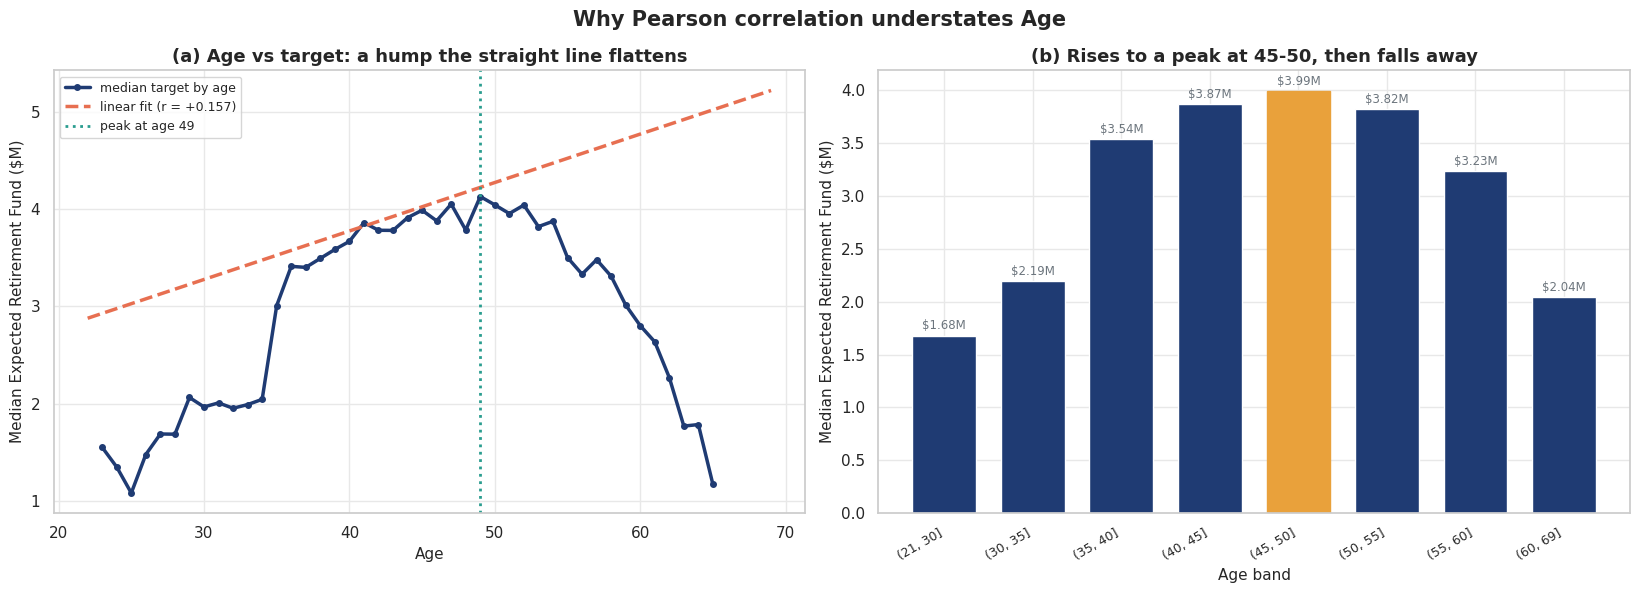

In [38]:
# --- Figure: the curve a straight line cannot see ------------------------
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6))

# (a) Median target by age, with the linear fit drawn for comparison.
age_profile = df.groupby("Age")[TARGET].agg(["median", "size"])
age_profile = age_profile[age_profile["size"] >= 30]   # ignore sparse ages

axes[0].plot(age_profile.index, age_profile["median"] / 1e6, color=NAVY, lw=2.5,
             marker="o", markersize=4, label="median target by age")

# The straight line a linear model would fit to exactly the same data.
slope, intercept = np.polyfit(df.Age, df[TARGET], 1)
age_grid = np.linspace(df.Age.min(), df.Age.max(), 100)
axes[0].plot(age_grid, (slope * age_grid + intercept) / 1e6, color=CORAL,
             ls="--", lw=2.5,
             label=f"linear fit (r = {df.Age.corr(df[TARGET]):+.3f})")

peak_age = age_profile["median"].idxmax()
axes[0].axvline(peak_age, color=TEAL, ls=":", lw=2, label=f"peak at age {peak_age}")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Median Expected Retirement Fund ($M)")
axes[0].set_title("(a) Age vs target: a hump the straight line flattens")
axes[0].legend(fontsize=9)

# (b) The same relationship as banded medians, which makes the rise-and-fall
#     easy to read off precisely.
age_bands = pd.cut(df.Age, [21, 30, 35, 40, 45, 50, 55, 60, 69])
band_medians = df.groupby(age_bands, observed=True)[TARGET].median()

bars = axes[1].bar(range(len(band_medians)), band_medians.values / 1e6,
                   color=NAVY, edgecolor="white", width=0.72)
bars[int(np.argmax(band_medians.values))].set_color(AMBER)
axes[1].set_xticks(range(len(band_medians)))
axes[1].set_xticklabels([str(interval) for interval in band_medians.index],
                        rotation=30, ha="right", fontsize=9)
axes[1].set_xlabel("Age band")
axes[1].set_ylabel("Median Expected Retirement Fund ($M)")
axes[1].set_title("(b) Rises to a peak at 45-50, then falls away")
for i, value in enumerate(band_medians.values / 1e6):
    axes[1].text(i, value + 0.06, f"${value:.2f}M", ha="center", fontsize=8.5,
                 color=SLATE)

fig.suptitle("Why Pearson correlation understates Age", fontsize=15,
             fontweight="bold")
save_fig("13_age_nonlinearity")
plt.show()

### What we learned

### What this tells us Panel (a) is the clearest illustration in the notebook of why correlation
is not relationship. The median projected fund **rises steeply from age 22 into the late
forties, plateaus, then falls away through the sixties**. The dashed line is what a linear model
fits to the same data: a gentle upward slope that misses both the peak and the decline entirely.

Panel (b) reads the shape off precisely. The median rises from **USD 1.68M** in the 22–30 band to a
peak of **USD 3.99M** at 45–50, then falls to **USD 2.04M** by 60–69 — a **49% decline** from peak.

**Why the curve has this shape — two forces working against each other:**

1. **Younger customers have more time but less money.** A 25-year-old has ~35 years to compound
   but a median salary of USD 66,637 and a retirement balance near USD 29,645.
2. **Older customers have more money but less time.** A 55-year-old has a median salary of
   USD 161,116 and a balance over USD 1.13M, but only ~8 years of compounding left.

The projected fund peaks where the *product* of these two is largest — the late forties. This is
a sensible financial dynamic, not a data artefact.

### Why it matters A linear model given raw `Age` will fit a slope through a hump and capture
almost none of the available signal. Worse, it will produce actively misleading coefficients: it
implies every additional year of age increases the projected fund, which is false for anyone over
50.

### ML takeaway Either use tree-based models (which handle this natively), or
engineer `Age²` / spline terms explicitly (Section 10). Do not feed raw `Age` to a linear model
and assume it has been used.


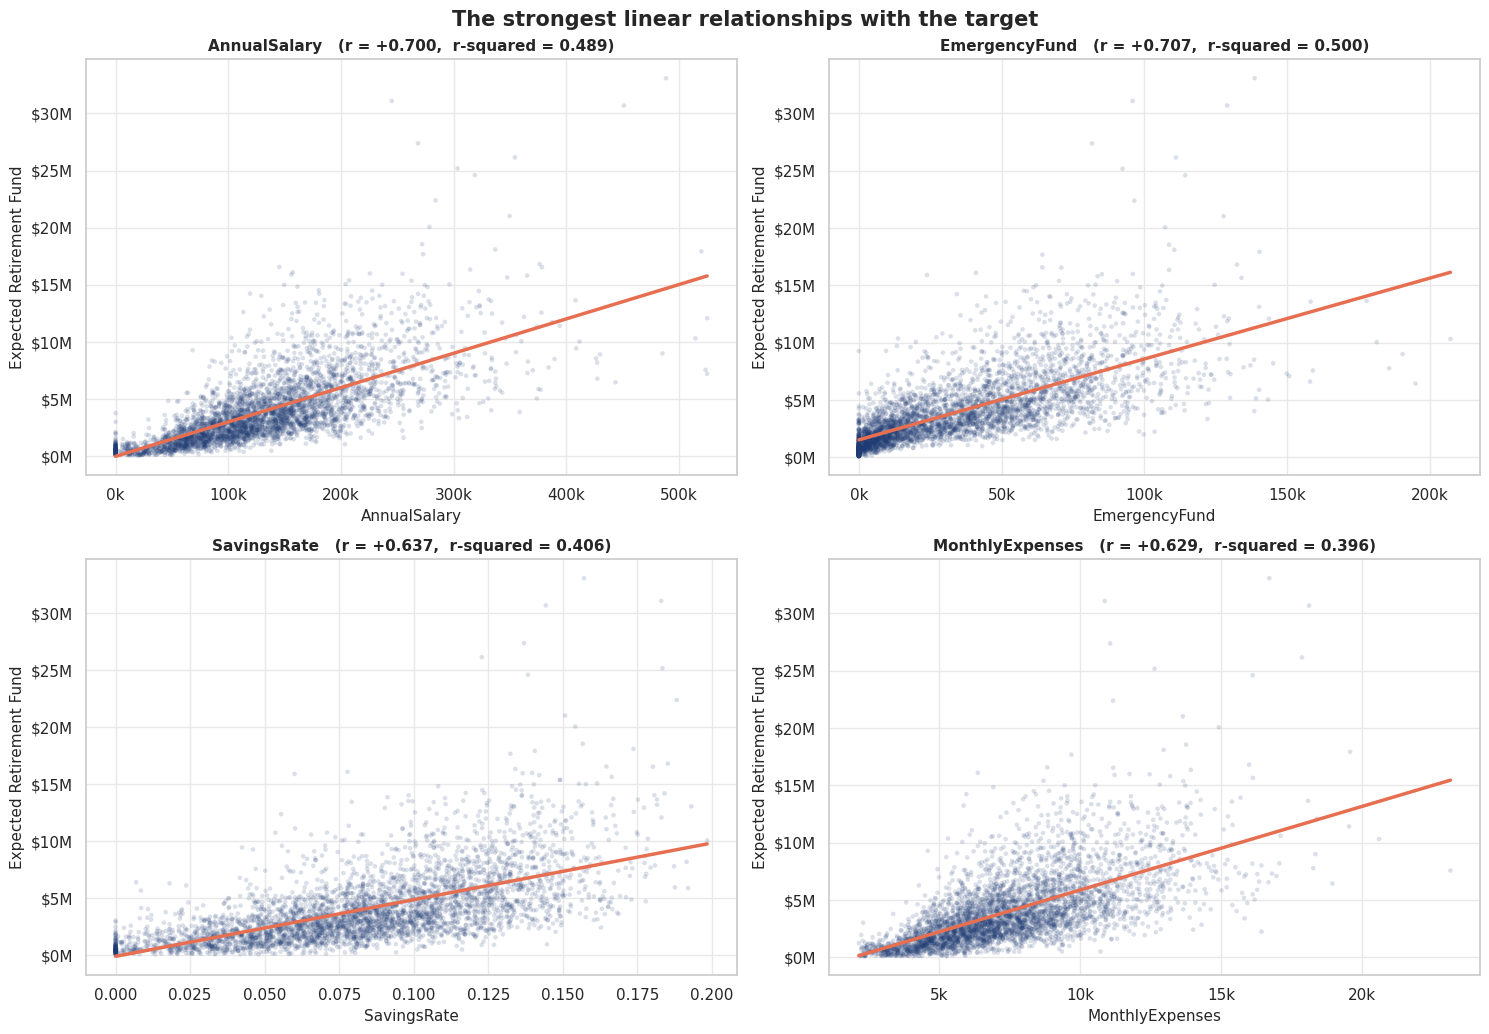

In [39]:
# --- Figure: scatter and regression views of the linear relationships ----
# With 30,000 points a plain scatter becomes a solid block, so we plot a
# transparent sample for the cloud and fit the line on the full dataset.
linear_features = ["AnnualSalary", "EmergencyFund", "SavingsRate", "MonthlyExpenses"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10.5))
plot_sample = df.sample(4000, random_state=7)

for ax, column in zip(axes.flat, linear_features):
    sns.regplot(data=plot_sample, x=column, y=TARGET, ax=ax,
                scatter_kws={"alpha": 0.16, "s": 11, "color": NAVY,
                             "edgecolor": "none"},
                line_kws={"color": CORAL, "lw": 2.5},
                ci=None, lowess=False)
    r = df[column].corr(df[TARGET])
    ax.set_title(f"{column}   (r = {r:+.3f},  r-squared = {r**2:.3f})",
                 fontsize=11)
    ax.set_ylabel("Expected Retirement Fund")
    ax.yaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.0f}M"))
    if df[column].max() > 1000:
        ax.xaxis.set_major_formatter(
            matplotlib.ticker.FuncFormatter(lambda v, _: f"{v/1000:,.0f}k"))

fig.suptitle("The strongest linear relationships with the target",
             fontsize=15, fontweight="bold")
save_fig("14_salary_vs_target")
plt.show()

### What we learned

### What this tells us All four relationships are positive and visibly linear, but they share one
feature that matters for modelling: **the spread of the point cloud widens as the feature
increases.**

This is heteroscedasticity, and it is most obvious for `AnnualSalary`. At a salary of USD 50K the
projected funds cluster tightly; at USD 300K they range across many millions.

On the individual relationships: `EmergencyFund` (r = +0.707) and `AnnualSalary` (r = +0.700) are
the two strongest single predictors in the dataset. `SavingsRate` (r = +0.637) is notable because
it is *behavioural* rather than a wealth stock — how much of your income you set aside is nearly
as predictive as how much you earn. `MonthlyExpenses` (r = +0.629) is positive, which seems
backwards until you note that expenses proxy lifestyle and therefore income: it correlates
**+0.872** with `AnnualSalary`. It is not telling us that spending more makes you richer.

### Why it matters Heteroscedasticity has two consequences. Ordinary least squares remains
*unbiased* but is no longer *efficient*, and its standard errors are understated — any confidence
interval from an untransformed linear model here would be too narrow.

### ML takeaway Log-transforming the target largely fixes this, because the spread
grows roughly in proportion to the level, which is exactly the condition under which a log
transform stabilises variance. This is an additional, independent argument for the transform
recommended in Section 3.


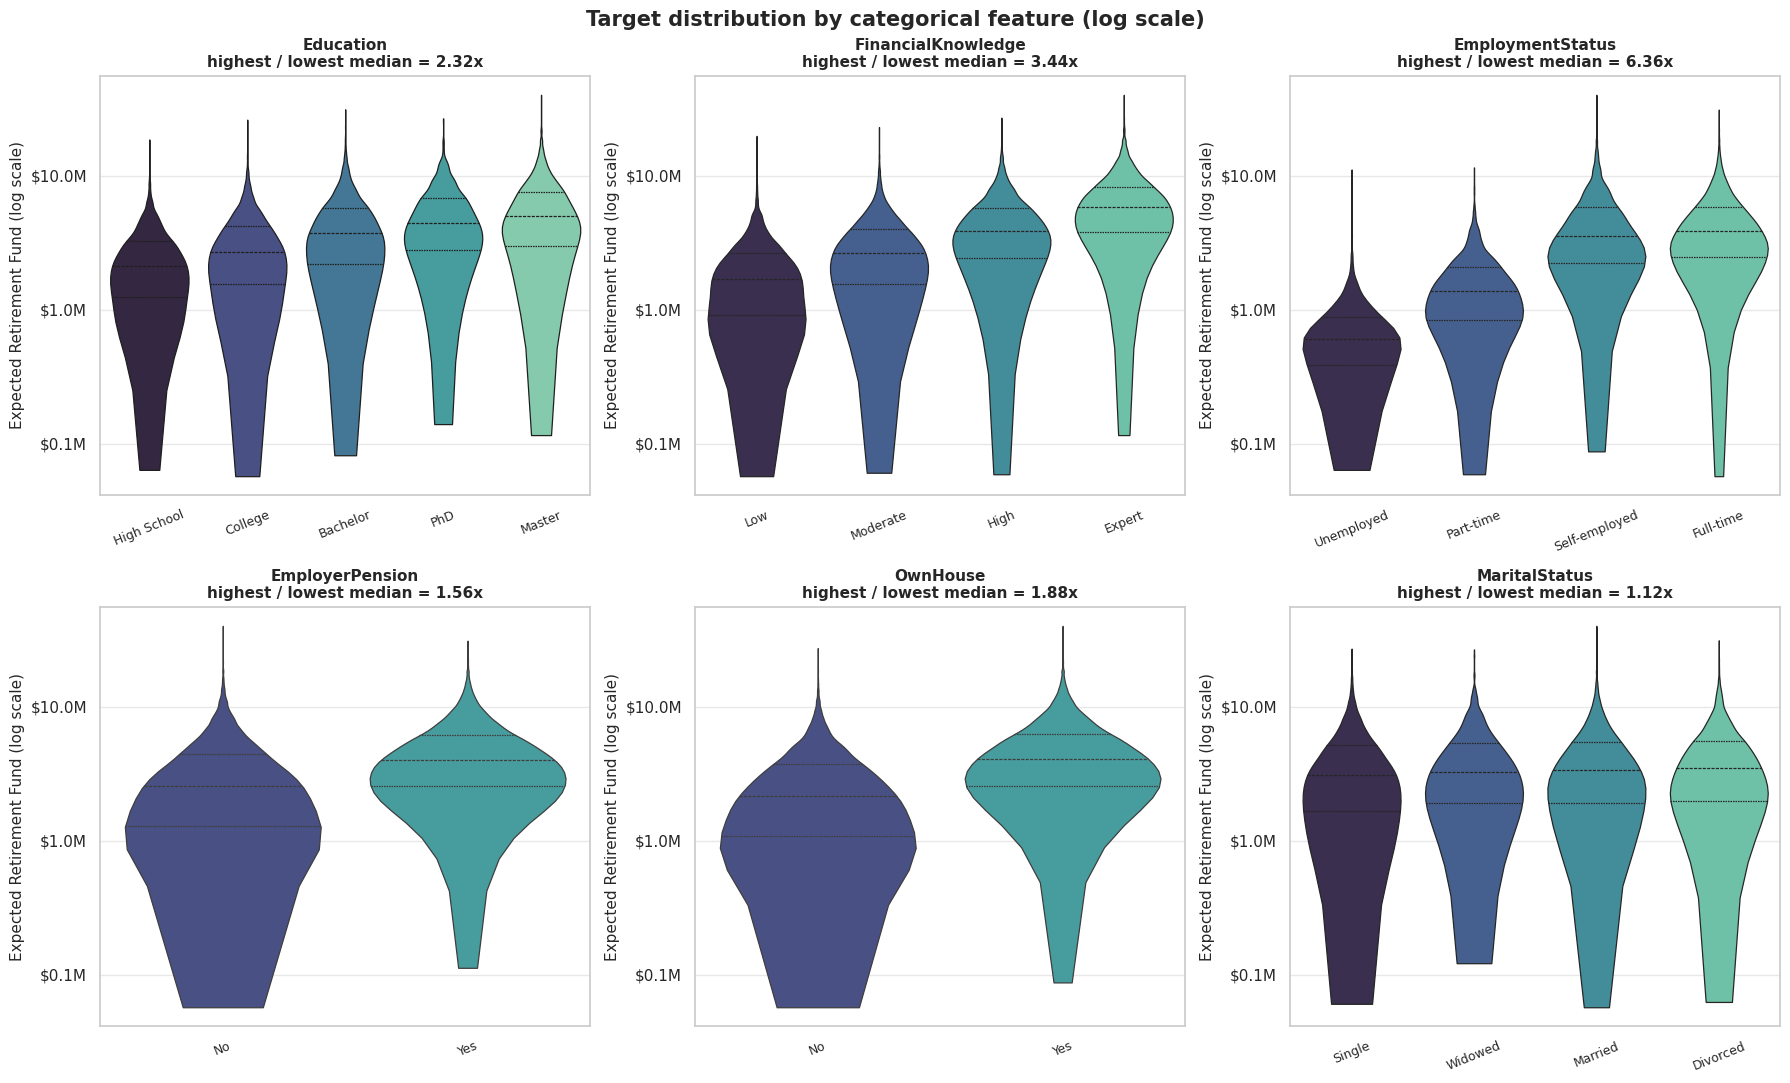

In [40]:
# --- Figure: categorical features vs the target --------------------------
# Violin plots show the full conditional distribution, not just the median -
# which matters here because several groups have very different spreads.
categorical_features = ["Education", "FinancialKnowledge", "EmploymentStatus",
                        "EmployerPension", "OwnHouse", "MaritalStatus"]

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for ax, column in zip(axes.flat, categorical_features):
    level_order = df.groupby(column)[TARGET].median().sort_values().index
    sns.violinplot(data=df, x=column, y=TARGET, order=level_order, ax=ax,
                   hue=column, hue_order=level_order, legend=False,
                   palette=SEQUENTIAL_CMAP, cut=0, linewidth=0.9,
                   inner="quartile")
    ax.set_yscale("log")
    ax.set_ylabel("Expected Retirement Fund (log scale)")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=22, labelsize=9)
    ax.yaxis.set_major_formatter(
        matplotlib.ticker.FuncFormatter(lambda v, _: f"${v/1e6:,.1f}M"))

    # Quantify the separation so "strong" and "weak" are not just visual claims.
    level_medians = df.groupby(column)[TARGET].median()
    spread_ratio = level_medians.max() / level_medians.min()
    ax.set_title(f"{column}\nhighest / lowest median = {spread_ratio:.2f}x",
                 fontsize=11)

fig.suptitle("Target distribution by categorical feature (log scale)",
             fontsize=15, fontweight="bold")
save_fig("15_target_by_category")
plt.show()

In [41]:
# --- The same comparison as numbers, ranked by separation ----------------
separation_rows = []
for column in df.select_dtypes(include="object").columns:
    level_stats = df.groupby(column)[TARGET].agg(["size", "median", "mean"])
    level_stats = level_stats.sort_values("median", ascending=False)
    separation_rows.append({
        "feature": column,
        "n_levels": len(level_stats),
        "top_level": level_stats.index[0],
        "top_median": round(level_stats["median"].iloc[0]),
        "bottom_level": level_stats.index[-1],
        "bottom_median": round(level_stats["median"].iloc[-1]),
        "spread_ratio": round(level_stats["median"].iloc[0] /
                              level_stats["median"].iloc[-1], 2),
    })

separation = pd.DataFrame(separation_rows).set_index("feature")
separation = separation.sort_values("spread_ratio", ascending=False)
print("How much does each categorical feature separate the target?\n")
separation

How much does each categorical feature separate the target?



,n_levels,top_level,top_median,bottom_level,bottom_median,spread_ratio
feature,,,,,,
EmploymentStatus,4,Full-time,3864773,Unemployed,607410,6.3600
FinancialKnowledge,4,Expert,5799740,Low,1687106,3.4400
Education,5,Master,4970243,High School,2138149,2.3200
OwnHouse,2,Yes,4071193,No,2161926,1.8800
EmployerPension,2,Yes,4006032,No,2575337,1.5600
MaritalStatus,4,Divorced,3474535,Single,3111658,1.1200
Gender,4,Non-binary,3553568,Female,3296161,1.0800


### What we learned

### What this tells us

**Strong separators (encode carefully):**

- **`EmploymentStatus` — 6.36× spread.** Full-time customers have a median projection of
  **USD 3.86M** against **USD 607K** for the unemployed. The largest single categorical effect, and
  unsurprising: employment status determines whether contributions happen at all.
- **`FinancialKnowledge` — 3.44× spread.** Expert **USD 5.80M** versus Low **USD 1.69M**, and the
  progression is perfectly monotonic across all four levels. This is the most interesting
  categorical in the dataset because it is the only one that is genuinely *modifiable* — a
  customer cannot change their age, but financial literacy responds to intervention.
- **`Education` — 2.32× spread.** High School **USD 2.14M** rising to Master **USD 4.97M**.
- **`OwnHouse` — 1.88× spread.** Owners **USD 4.07M** versus non-owners **USD 2.16M**.
- **`EmployerPension` — 1.56× spread.** With **USD 4.01M** versus without **USD 2.58M**.

**Weak separators — stated plainly rather than dressed up:**

- **`MaritalStatus` — 1.12× spread.** Divorced USD 3.47M down to Single USD 3.11M, with all four levels
  within 12% of each other and violin plots that overlap almost entirely. This feature carries
  very little information about the target.
- **`Gender` — 1.08× spread.** Medians run from USD 3.30M (Female) to USD 3.55M (Non-binary), with Male
  and Female nearly identical at USD 3.32M and USD 3.30M. The two extremes are also the two smallest
  groups (n = 290 and n = 163), so the apparent spread is most likely sampling noise.
  **There is no meaningful gender effect on the target in this dataset.** That is a useful
  negative result: grouping the rare `Gender` levels (recommended in Section 4) discards nothing.


In [42]:
# --- Resolving the education anomaly -------------------------------------
# PhD holders out-earn Master's holders but project to LESS. That inverts the
# pattern everywhere else in the data, so it is worth explaining rather than
# noting. Hypothesis: PhDs start their careers later and lose compounding years.
education_profile = df.groupby("Education").agg(
    n=("Age", "size"),
    median_salary=("AnnualSalary", "median"),
    median_target=(TARGET, "median"),
    median_age=("Age", "median"),
    median_years_experience=("YearsExperience", "median"),
)
# Career start age is the cleanest way to test the hypothesis directly.
education_profile["median_career_start_age"] = (
    df.assign(career_start=df.Age - df.YearsExperience)
      .groupby("Education")["career_start"].median()
)
education_profile = education_profile.sort_values("median_salary")
education_profile.round(1)

,n,median_salary,median_target,median_age,median_years_experience,median_career_start_age
Education,,,,,,
High School,4809,"102,939.3000","2,138,149.1000",49.0000,29.0000,19.0000
College,7661,"113,804.0000","2,719,350.5000",47.0000,25.0000,21.0000
Bachelor,10643,"135,038.8000","3,728,102.7000",46.0000,22.0000,23.0000
Master,5625,"163,885.0000","4,970,242.7000",46.0000,20.0000,25.0000
PhD,1262,"177,514.6000","4,446,418.5000",46.0000,17.0000,28.0000


### The education anomaly, explained

### What this tells us The `Education` ordering breaks at the top: **PhD holders have a higher
median salary than Master's holders (USD 177,515 vs USD 163,885) but a *lower* median projected fund
(USD 4.45M vs USD 4.97M)**. Every other pattern in this dataset says higher income produces a larger
fund, so this inversion needs an explanation.

The table provides one. Median career start age rises monotonically with education:

| Education | Median career start age | Median salary | Median target |
|---|---|---|---|
| High School | **19** | USD 102,939 | USD 2.14M |
| College | **21** | USD 113,804 | USD 2.72M |
| Bachelor | **23** | USD 135,039 | USD 3.73M |
| Master | **25** | USD 163,885 | **USD 4.97M** |
| PhD | **28** | **USD 177,515** | USD 4.45M |

**PhD holders start work at 28 — three years later than Master's holders and nine years later
than the High School group — while having the same median age of 46.** They earn the most per
year but have the fewest years to compound it.

### Why it matters This resolves what would otherwise be an unexplained inconsistency, and it
has a direct modelling consequence: **the education gradient is not monotonic in the target**, so
ordinal integer encoding (High School = 1 … PhD = 5) would impose an ordering the data does not
support.

### ML takeaway One-hot encode `Education` rather than treating it as ordinal. And
engineer `CareerStartAge = Age − YearsExperience` (Section 10) — it captures the mechanism
directly, and as a bonus it decorrelates the `Age` / `YearsExperience` pair flagged in Section 7.


# 9. Retirement Horizon Analysis

### What are we doing?

Age alone does not describe where a customer is in the retirement journey. Years until retirement gives the model and the business a more useful way to describe that stage.


In [43]:
# --- Derive the retirement horizon ---------------------------------------
# This column does not exist in the dataset; the previous version supplied it,
# the final version does not. Section 2 confirmed DesiredRetirementAge > Age
# for all 30,000 rows, so this is always positive and needs no clipping.
horizon = df.copy()
horizon["YearsUntilRetirement"] = horizon.DesiredRetirementAge - horizon.Age

# Four bands chosen to mirror how a retirement provider actually talks about
# customers: early career, mid career, pre-retirement, and imminent.
horizon["HorizonBand"] = pd.cut(
    horizon.YearsUntilRetirement,
    bins=[0, 10, 20, 30, 50],
    labels=["1-10 yrs (imminent)", "11-20 yrs (pre-retirement)",
            "21-30 yrs (mid career)", "31+ yrs (early career)"],
)

print(f"YearsUntilRetirement: min {horizon.YearsUntilRetirement.min()}, "
      f"max {horizon.YearsUntilRetirement.max()}, "
      f"median {horizon.YearsUntilRetirement.median():.0f}")
print(f"Correlation with target: "
      f"{horizon.YearsUntilRetirement.corr(horizon[TARGET]):+.4f}\n")

horizon_summary = horizon.groupby("HorizonBand", observed=True).agg(
    customers=("CustomerID", "size"),
    median_age=("Age", "median"),
    median_salary=("AnnualSalary", "median"),
    median_savings_rate=("SavingsRate", "median"),
    median_retirement_balance=("RetirementAccountBalance", "median"),
    median_goal=("Retirement_Fund_Goal", "median"),
    median_expected_fund=(TARGET, "median"),
    median_funding_gap=("Funding_Gap", "median"),
    pct_on_track=("RetirementReady", "mean"),
)
horizon_summary["pct_on_track"] *= 100

# pd.cut orders bands by ascending years-to-retirement, which puts customers
# CLOSEST to retirement first. For a "journey" narrative we want the opposite:
# early career on the left, imminent retirement on the right. Reversing here
# means every chart below reads left-to-right in chronological order.
horizon_summary = horizon_summary.iloc[::-1]
horizon_summary.round(2)

YearsUntilRetirement: min 1, max 47, median 17
Correlation with target: -0.1946



,customers,median_age,median_salary,median_savings_rate,median_retirement_balance,median_goal,median_expected_fund,median_funding_gap,pct_on_track
HorizonBand,,,,,,,,,
31+ yrs (early career),4727,29.0000,"71,175.5000",0.0600,"44,235.4900","3,653,316.8600","1,787,554.4200","-1,767,509.0800",15.2700
21-30 yrs (mid career),6594,40.0000,"109,116.9500",0.0800,"266,098.2900","4,020,658.0000","3,263,662.5700","-703,455.1400",36.0800
11-20 yrs (pre-retirement),10207,48.0000,"147,569.1900",0.0900,"704,568.5400","3,823,766.3900","3,969,030.2600","147,423.3000",53.1800
1-10 yrs (imminent),8472,56.0000,"161,393.1600",0.0900,"1,301,400.4200","2,898,130.6400","3,513,022.3600","552,689.6000",66.2900


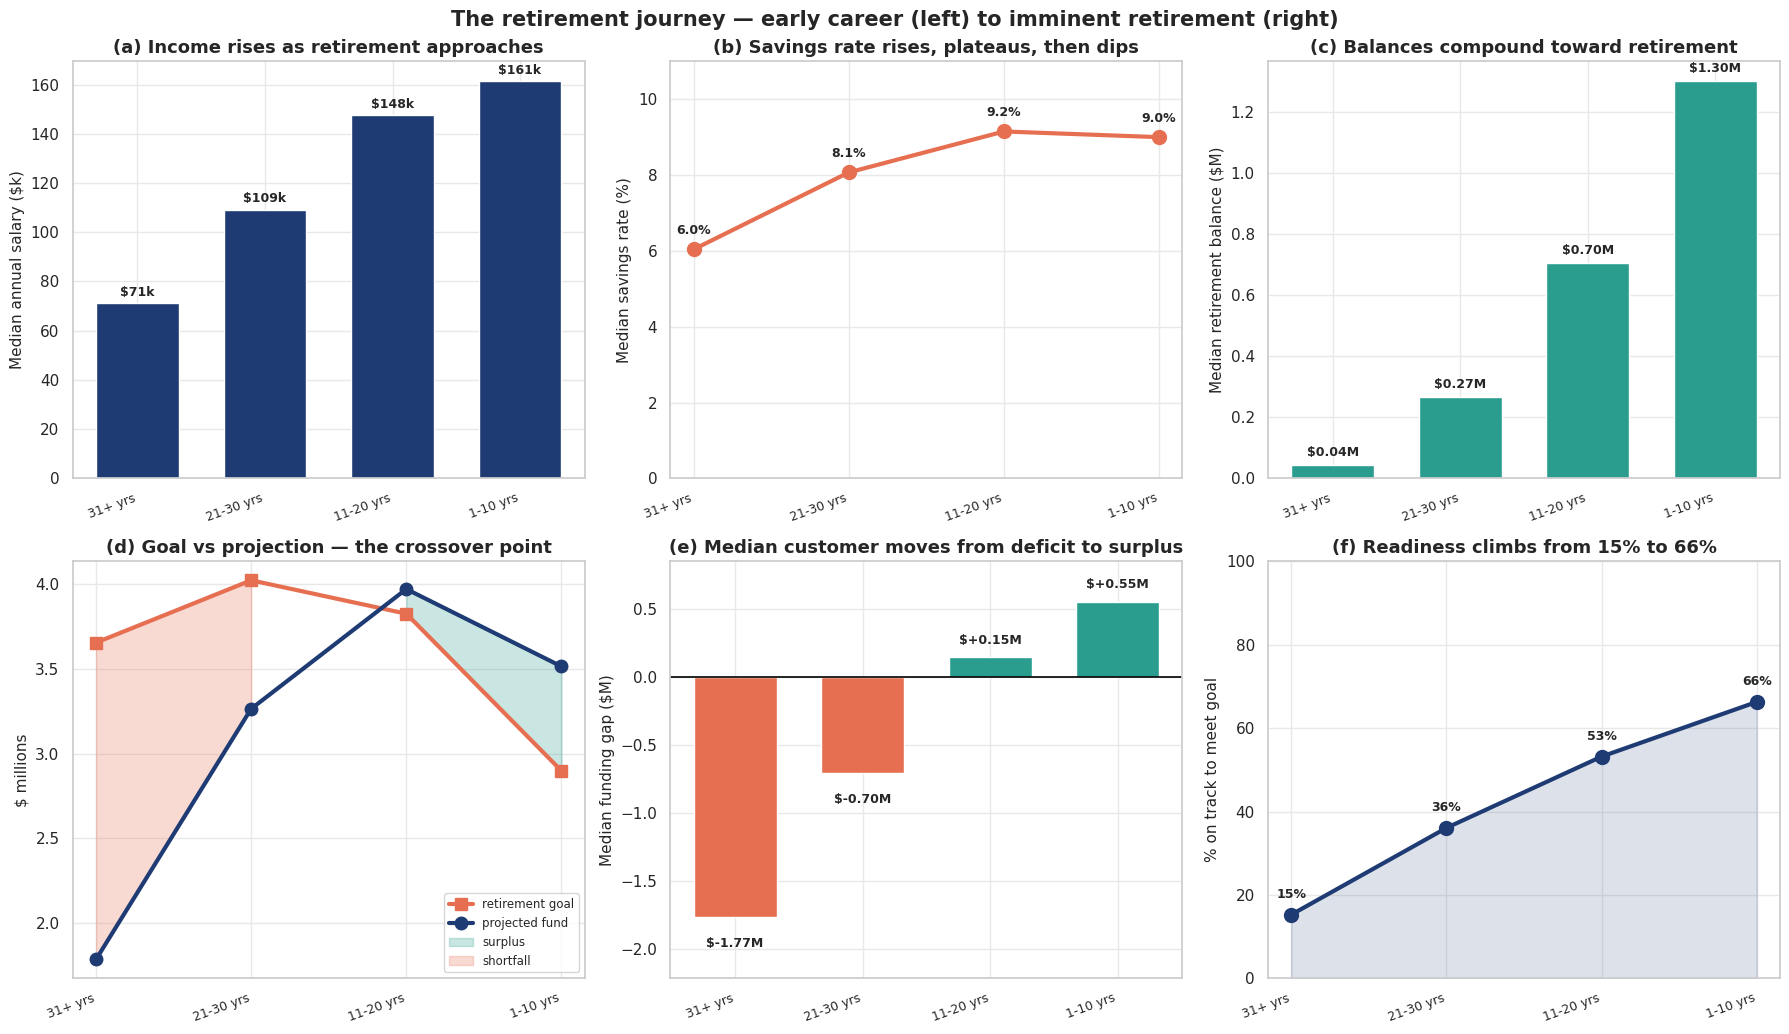

In [44]:
# --- Figure: the retirement journey in five views ------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10.5))
band_labels = list(horizon_summary.index)
x_positions = np.arange(len(band_labels))
short_labels = [label.split(" (")[0] for label in band_labels]

# (a) Income peaks in the pre-retirement years, then flattens.
axes[0, 0].bar(x_positions, horizon_summary.median_salary / 1000, color=NAVY,
               edgecolor="white", width=0.65)
axes[0, 0].set_ylabel("Median annual salary ($k)")
axes[0, 0].set_title("(a) Income rises as retirement approaches")
for i, value in enumerate(horizon_summary.median_salary / 1000):
    axes[0, 0].text(i, value + 3, f"${value:.0f}k", ha="center",
                    fontweight="bold", fontsize=9)

# (b) Savings RATE, which behaves differently from income.
axes[0, 1].plot(x_positions, horizon_summary.median_savings_rate * 100,
                color=CORAL, lw=3, marker="o", markersize=10)
axes[0, 1].set_ylabel("Median savings rate (%)")
axes[0, 1].set_ylim(0, 11)
axes[0, 1].set_title("(b) Savings rate rises, plateaus, then dips")
for i, value in enumerate(horizon_summary.median_savings_rate * 100):
    axes[0, 1].text(i, value + 0.4, f"{value:.1f}%", ha="center",
                    fontweight="bold", fontsize=9)

# (c) Retirement balances accumulate steadily - the compounding effect.
axes[0, 2].bar(x_positions, horizon_summary.median_retirement_balance / 1e6,
               color=TEAL, edgecolor="white", width=0.65)
axes[0, 2].set_ylabel("Median retirement balance ($M)")
axes[0, 2].set_title("(c) Balances compound toward retirement")
for i, value in enumerate(horizon_summary.median_retirement_balance / 1e6):
    axes[0, 2].text(i, value + 0.03, f"${value:.2f}M", ha="center",
                    fontweight="bold", fontsize=9)

# (d) Goal vs projected fund. The crossover is the story.
axes[1, 0].plot(x_positions, horizon_summary.median_goal / 1e6, color=CORAL,
                lw=3, marker="s", markersize=9, label="retirement goal")
axes[1, 0].plot(x_positions, horizon_summary.median_expected_fund / 1e6,
                color=NAVY, lw=3, marker="o", markersize=9,
                label="projected fund")
axes[1, 0].fill_between(x_positions, horizon_summary.median_goal / 1e6,
                        horizon_summary.median_expected_fund / 1e6,
                        where=(horizon_summary.median_expected_fund >=
                               horizon_summary.median_goal),
                        color=TEAL, alpha=0.25, label="surplus")
axes[1, 0].fill_between(x_positions, horizon_summary.median_goal / 1e6,
                        horizon_summary.median_expected_fund / 1e6,
                        where=(horizon_summary.median_expected_fund <
                               horizon_summary.median_goal),
                        color=CORAL, alpha=0.25, label="shortfall")
axes[1, 0].set_ylabel("$ millions")
axes[1, 0].set_title("(d) Goal vs projection — the crossover point")
axes[1, 0].legend(fontsize=8.5)

# (e) The funding gap itself, which is the cleanest single summary.
gap_colors = np.where(horizon_summary.median_funding_gap >= 0, TEAL, CORAL)
axes[1, 1].bar(x_positions, horizon_summary.median_funding_gap / 1e6,
               color=gap_colors, edgecolor="white", width=0.65)
axes[1, 1].axhline(0, color="black", lw=1.2)
axes[1, 1].set_ylabel("Median funding gap ($M)")
axes[1, 1].set_title("(e) Median customer moves from deficit to surplus")
# Add headroom so the value labels above and below the bars are not clipped.
gap_values = horizon_summary.median_funding_gap / 1e6
axes[1, 1].set_ylim(gap_values.min() - 0.45, gap_values.max() + 0.30)
for i, value in enumerate(gap_values):
    offset = 0.10 if value >= 0 else -0.22
    axes[1, 1].text(i, value + offset, f"${value:+.2f}M", ha="center",
                    fontweight="bold", fontsize=9)

# (f) Readiness rate.
axes[1, 2].plot(x_positions, horizon_summary.pct_on_track, color=NAVY, lw=3,
                marker="o", markersize=10)
axes[1, 2].fill_between(x_positions, horizon_summary.pct_on_track, alpha=0.15,
                        color=NAVY)
axes[1, 2].set_ylabel("% on track to meet goal")
axes[1, 2].set_ylim(0, 100)
axes[1, 2].set_title("(f) Readiness climbs from 15% to 66%")
for i, value in enumerate(horizon_summary.pct_on_track):
    axes[1, 2].text(i, value + 4, f"{value:.0f}%", ha="center",
                    fontweight="bold", fontsize=9)

for ax in axes.flat:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(short_labels, rotation=20, ha="right", fontsize=9)
    ax.set_xlabel("")

fig.suptitle("The retirement journey — early career (left) to imminent retirement (right)",
             fontsize=15, fontweight="bold")
save_fig("16_retirement_horizon")
plt.show()

### What we learned

### What this tells us Reading left to right — early career to imminent retirement — the
population moves through a coherent and interpretable journey.

| Band | n | Median age | Median salary | Savings rate | Retirement balance | Median gap | On track |
|---|---|---|---|---|---|---|---|
| **31+ yrs (early career)** | 4,727 | 29 | USD 71,176 | 6.0% | USD 44,235 | **−USD 1.77M** | **15.3%** |
| **21–30 yrs (mid career)** | 6,594 | 40 | USD 109,117 | 8.1% | USD 266,098 | **−USD 703K** | **36.1%** |
| **11–20 yrs (pre-retirement)** | 10,207 | 48 | USD 147,569 | 9.2% | USD 704,569 | **+USD 147K** | **53.2%** |
| **1–10 yrs (imminent)** | 8,472 | 56 | USD 161,393 | 9.0% | USD 1,301,400 | **+USD 553K** | **66.3%** |

**The crossover in panel (d) is the headline.** The median customer's projected fund overtakes
their goal somewhere in the **11–20 year** band. Before that point the typical customer is behind;
after it, ahead. That single fact is more useful for campaign targeting than any aggregate
readiness percentage.

**Panel (b) contains the one counterintuitive result.** Income rises monotonically across the
horizon (USD 71K → USD 161K), and balances rise steeply (USD 44K → USD 1.30M). But the savings *rate* rises
from 6.0% to a plateau of ~9.2% and then **dips slightly to 9.0%** in the final decade. The
customers with the least time remaining — and therefore the most to gain from a final push — are
not saving at a higher rate than the group a decade behind them.

**Panel (e) reframes readiness in dollars rather than a binary flag.** The early-career median
customer is **USD 1.77M short**; the imminent-retirement median customer is **USD 553K ahead**. Dollars
are far more actionable for a business audience than "15% ready".

**Why it matters — and the interpretive trap to avoid.** Low readiness in the early-career band
is **not** a warning sign. Readiness is measured against a goal that assumes a full career of
contributions, so a 29-year-old scoring 15% is not behind — they are 29. Reading panel (f) as
"85% of our young customers are failing" would be a serious misreading.

### ML takeaway

- **`YearsUntilRetirement` must be engineered**, because the final dataset no longer supplies it.
  It correlates **−0.195** with the target linearly, but Section 8's logic applies: the
  relationship runs through the same hump as `Age`, so the linear coefficient understates it.
- **Do not build separate models per horizon band.** Unlike the previous dataset's retired
  segment — where a feature had zero variance and the target arguably meant something different —
  these four bands are points on one continuous scale. A single model with
  `YearsUntilRetirement` as a feature captures the progression, and a tree ensemble will discover
  the band boundaries itself if they matter.
- **Do report error metrics by horizon band.** The early-career band has the smallest balances and
  the widest relative uncertainty; a pooled metric will be dominated by the two middle bands,
  which hold 56% of customers.


---

# 10. Feature Engineering Opportunities

**No features are created in this notebook.** Feature engineering belongs in the modelling
pipeline, where it can be fitted inside cross-validation folds and cannot leak. This section
documents *what* to build and, more importantly, *what evidence in the EDA justifies each one*.

Every recommendation below traces back to a specific finding in Sections 3–9.


# 10. Feature Engineering Opportunities

### What are we doing?

The EDA has shown several relationships that can be represented more directly. This section turns those findings into candidate features for the preprocessing pipeline.


---

# 11. Data Leakage Assessment

Leakage is the failure mode that produces a model with an excellent validation score and no
value. It is worth being precise about the definition: a feature leaks if it **would not be
available, in that form, at the moment a real prediction is needed** — or if it is
**mathematically derived from the target**.

This dataset contains three columns of the second kind, and one of them is more severe than
anything in the previous version. We test rather than assume.


In [45]:
# --- LEAKAGE TEST 1: Funding_Gap -----------------------------------------
# Hypothesis: Funding_Gap is simply the target minus the goal.
implied_gap = df[TARGET] - df.Retirement_Fund_Goal
deviation = (implied_gap - df.Funding_Gap).abs()

print("HYPOTHESIS:  Funding_Gap == Expected_Retirement_Fund - Retirement_Fund_Goal\n")
print(f"   rows tested:                {len(df):,}")
print(f"   maximum absolute deviation: ${deviation.max():.10f}")
print(f"   rows deviating by over $1:  {(deviation > 1).sum()}")
print("\n   VERDICT: CONFIRMED. The deviation is at floating-point precision,")
print("            i.e. these are the same number.")

HYPOTHESIS:  Funding_Gap == Expected_Retirement_Fund - Retirement_Fund_Goal

   rows tested:                30,000
   maximum absolute deviation: $0.0000000037
   rows deviating by over $1:  0

   VERDICT: CONFIRMED. The deviation is at floating-point precision,
            i.e. these are the same number.


In [46]:
# --- LEAKAGE TEST 2: Readiness_Score -------------------------------------
# Hypothesis: Readiness_Score is the target divided by the goal.
implied_readiness = df[TARGET] / df.Retirement_Fund_Goal
readiness_deviation = (implied_readiness - df.Readiness_Score).abs()

print("HYPOTHESIS:  Readiness_Score == Expected_Retirement_Fund / Retirement_Fund_Goal\n")
print(f"   correlation with actual column:   "
      f"{implied_readiness.corr(df.Readiness_Score):.10f}")
print(f"   maximum absolute deviation:       {readiness_deviation.max():.8f}")
print(f"   rows deviating by over 0.001:     {(readiness_deviation > 0.001).sum()}")
print("\n   VERDICT: CONFIRMED. The deviation is consistent with the column")
print("            having been rounded to 4 decimal places.")

HYPOTHESIS:  Readiness_Score == Expected_Retirement_Fund / Retirement_Fund_Goal

   correlation with actual column:   0.9999999991
   maximum absolute deviation:       0.00005000
   rows deviating by over 0.001:     0

   VERDICT: CONFIRMED. The deviation is consistent with the column
            having been rounded to 4 decimal places.


In [47]:
# --- LEAKAGE TEST 3: RetirementReady -------------------------------------
# Two equivalent hypotheses, since Funding_Gap >= 0 and Readiness >= 1.0
# describe the same condition. We test both to show they agree.
print("HYPOTHESIS A:  RetirementReady == 1 if Readiness_Score >= threshold\n")
print("   threshold    exact match rate")
for threshold in [0.90, 0.95, 1.00, 1.05, 1.10]:
    predicted = (df.Readiness_Score >= threshold).astype(int)
    match_rate = (predicted == df.RetirementReady).mean()
    print(f"   {threshold:>6.2f}       {match_rate:>12.6%}")

gap_rule_match = ((df.Funding_Gap >= 0).astype(int) == df.RetirementReady).mean()
print(f"\nHYPOTHESIS B:  RetirementReady == 1 if Funding_Gap >= 0")
print(f"   exact match rate: {gap_rule_match:.6%}")
print("\n   VERDICT: BOTH CONFIRMED at 100.000000% across all 30,000 rows.")
print("            RetirementReady is the target, binarised against the goal.")

HYPOTHESIS A:  RetirementReady == 1 if Readiness_Score >= threshold

   threshold    exact match rate
     0.90         93.250000%
     0.95         96.773333%
     1.00        100.000000%
     1.05         96.766667%
     1.10         93.576667%

HYPOTHESIS B:  RetirementReady == 1 if Funding_Gap >= 0
   exact match rate: 100.000000%

   VERDICT: BOTH CONFIRMED at 100.000000% across all 30,000 rows.
            RetirementReady is the target, binarised against the goal.


In [48]:
# --- What leakage would do to a model: a demonstration -------------------
# We do not need to train anything to make the point. If these columns are
# available, the target is recoverable by arithmetic - exactly, not approximately.
reconstruction_methods = {
    "Funding_Gap + Retirement_Fund_Goal": df.Funding_Gap + df.Retirement_Fund_Goal,
    "Readiness_Score x Retirement_Fund_Goal": df.Readiness_Score * df.Retirement_Fund_Goal,
}

print("Reconstructing the target from each leakage column:\n")
reconstruction_rows = []
for method_name, reconstructed in reconstruction_methods.items():
    error_pct = (reconstructed - df[TARGET]).abs() / df[TARGET] * 100
    reconstruction_rows.append({
        "method": method_name,
        "median_error_pct": round(error_pct.median(), 8),
        "max_error_pct": round(error_pct.max(), 6),
        "pct_rows_within_0.1pct": round((error_pct < 0.1).mean() * 100, 4),
    })
    print(f"   {method_name}")
    print(f"      median absolute error: {error_pct.median():.8f}%")
    print(f"      maximum error:         {error_pct.max():.6f}%")
    print(f"      rows within 0.1%:      {(error_pct < 0.1).mean():.4%}\n")

print("A model given either column would report near-perfect accuracy while")
print("having learned nothing. Neither can exist before Expected_Retirement_Fund")
print("is known - both are computed FROM it.")
pd.DataFrame(reconstruction_rows).set_index("method")

Reconstructing the target from each leakage column:

   Funding_Gap + Retirement_Fund_Goal
      median absolute error: 0.00000000%
      maximum error:         0.000000%
      rows within 0.1%:      100.0000%

   Readiness_Score x Retirement_Fund_Goal
      median absolute error: 0.00238841%
      maximum error:         0.206648%
      rows within 0.1%:      99.9567%

A model given either column would report near-perfect accuracy while
having learned nothing. Neither can exist before Expected_Retirement_Fund
is known - both are computed FROM it.


,median_error_pct,max_error_pct,pct_rows_within_0.1pct
method,,,
Funding_Gap + Retirement_Fund_Goal,0.0000,0.0000,100.0000
Readiness_Score x Retirement_Fund_Goal,0.0024,0.2066,99.9567


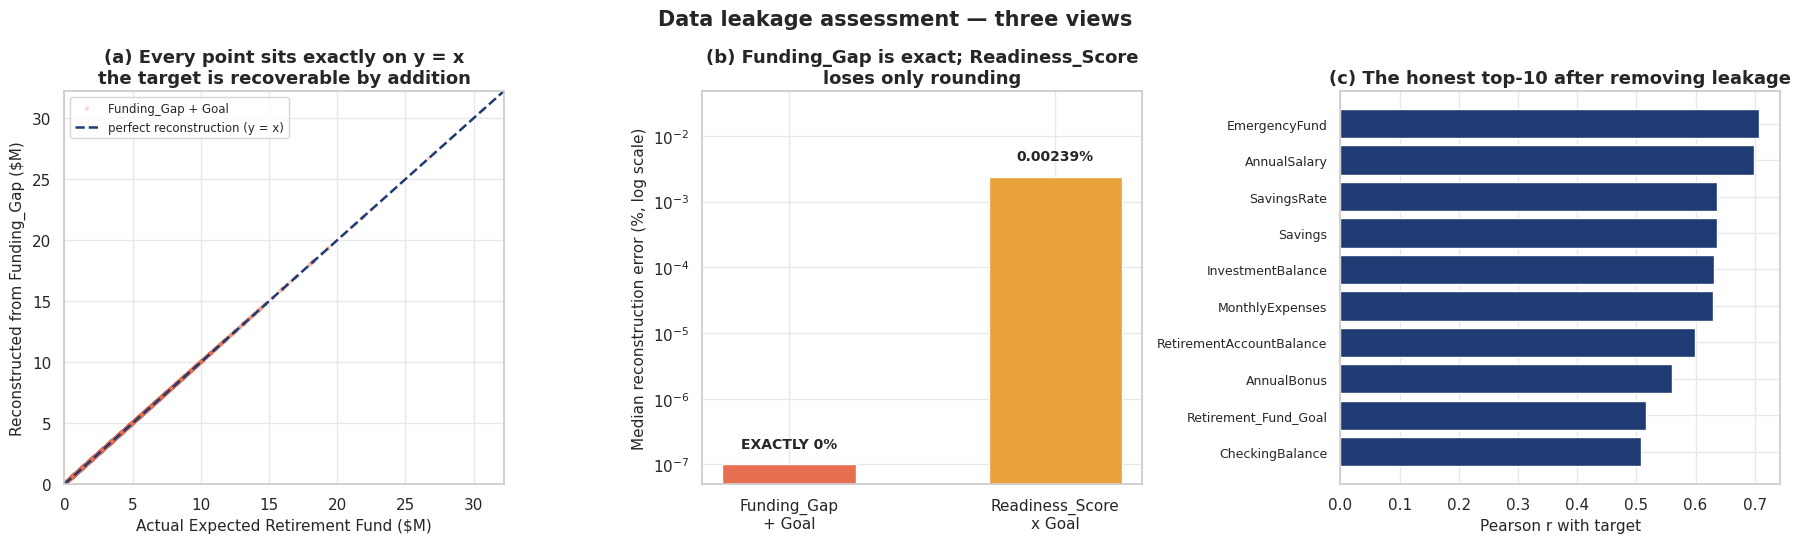

In [49]:
# --- Figure: what leakage looks like -------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) The decisive view: reconstruct the target from the leakage column and
#     plot it against the truth. A perfect diagonal means the "prediction"
#     is arithmetic, not learned.
sample = df.sample(4000, random_state=3)
reconstructed_sample = sample.Funding_Gap + sample.Retirement_Fund_Goal

axes[0].scatter(sample[TARGET] / 1e6, reconstructed_sample / 1e6, s=10,
                alpha=0.25, color=CORAL, edgecolor="none",
                label="Funding_Gap + Goal")
axis_limit = sample[TARGET].max() / 1e6 * 1.05
axes[0].plot([0, axis_limit], [0, axis_limit], ls="--", color=NAVY, lw=1.8,
             label="perfect reconstruction (y = x)")
axes[0].set_xlim(0, axis_limit)
axes[0].set_ylim(0, axis_limit)
axes[0].set_xlabel("Actual Expected Retirement Fund ($M)")
axes[0].set_ylabel("Reconstructed from Funding_Gap ($M)")
axes[0].set_title("(a) Every point sits exactly on y = x\n"
                  "the target is recoverable by addition")
axes[0].legend(fontsize=8.5, loc="upper left")

# (b) Reconstruction error, which is the decisive evidence.
reconstruction_labels = ["Funding_Gap\n+ Goal", "Readiness_Score\nx Goal"]
median_errors = [
    ((df.Funding_Gap + df.Retirement_Fund_Goal - df[TARGET]).abs()
     / df[TARGET] * 100).median(),
    ((df.Readiness_Score * df.Retirement_Fund_Goal - df[TARGET]).abs()
     / df[TARGET] * 100).median(),
]
# A zero-height bar would look like missing data rather than a finding, so we
# plot on a log scale with an explicit floor and label the exact-zero case.
ERROR_FLOOR = 1e-7          # so a true zero is still visible as a stub
plotted_errors = [max(error, ERROR_FLOOR) for error in median_errors]

bars = axes[1].bar(reconstruction_labels, plotted_errors, color=[CORAL, AMBER],
                   edgecolor="white", width=0.5)
axes[1].set_yscale("log")
axes[1].set_ylim(ERROR_FLOOR / 2, max(median_errors) * 20)
axes[1].set_ylabel("Median reconstruction error (%, log scale)")
axes[1].set_title("(b) Funding_Gap is exact; Readiness_Score\nloses only rounding")
for bar, actual_error in zip(bars, median_errors):
    label = "EXACTLY 0%" if actual_error == 0 else f"{actual_error:.5f}%"
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 max(actual_error, ERROR_FLOOR) * 1.8,
                 label, ha="center", fontweight="bold", fontsize=10)

# (c) The corrected feature ranking, once the KPI columns are removed.
clean_correlations = target_correlation.drop(index=LEAKAGE_COLS).pearson
clean_correlations = clean_correlations.reindex(
    clean_correlations.abs().sort_values(ascending=False).index).head(10)
axes[2].barh(clean_correlations.index, clean_correlations.values, color=NAVY,
             edgecolor="white")
axes[2].invert_yaxis()
axes[2].set_xlabel("Pearson r with target")
axes[2].set_title("(c) The honest top-10 after removing leakage")
axes[2].tick_params(axis="y", labelsize=9)

fig.suptitle("Data leakage assessment — three views", fontsize=15,
             fontweight="bold")
save_fig("17_leakage_assessment")
plt.show()

### What we learned

### What this tells us Panel (b) is the decisive evidence and the reason `Funding_Gap` is the
most dangerous column in the file:

| Reconstruction method | Median error | Max error | Rows within 0.1% |
|---|---|---|---|
| **`Funding_Gap` + `Retirement_Fund_Goal`** | **0.00000000%** | **0.000000%** | **100.0000%** |
| `Readiness_Score` × `Retirement_Fund_Goal` | 0.0024% | 0.207% | 99.96% |

`Readiness_Score` reconstructs the target to within rounding error. **`Funding_Gap` reconstructs
it exactly** — it is an additive rather than multiplicative transform of the target, so it does
not even lose precision to rounding. A model given `Funding_Gap` and `Retirement_Fund_Goal` would
achieve an R² of exactly 1.0.

Panel (a) makes the point visually. Plotting the reconstruction against the truth puts **every
one of the 4,000 sampled points exactly on the y = x line** — no scatter, no residual spread.
That is the signature of an arithmetic relationship, not an empirical one. A genuine predictor
produces a cloud around the diagonal; this produces the diagonal itself.

Panel (c) shows the honest picture once the KPI columns are removed. The top predictors become
`EmergencyFund`, `AnnualSalary`, and `SavingsRate` — economically sensible features with
correlations in the 0.6–0.7 range rather than 0.84.

### Why it matters Leakage is the difference between a portfolio project that demonstrates
competence and one that demonstrates its absence. A model reporting R² = 0.99 on this dataset is
not a good model; it is a model that has been handed the answer.

### ML takeaway Three columns must be dropped before training, plus the identifier.


# 11. Machine Learning Features vs Business KPIs

### What are we doing?

Not every useful business measure is a valid model input. This section separates variables that describe the outcome from variables that can legitimately be used to predict it.


---

# 12. Machine Learning Readiness

Everything above feeds one decision: **is this dataset fit for supervised regression, and what
must happen first?**

We score it against seven criteria, each with a verdict grounded in a specific finding rather
than a general impression.


In [50]:
# --- A readiness scorecard, computed rather than asserted ----------------
# Scores run 1 (blocking issue) to 5 (no action needed). Writing the evidence
# as f-strings means the scorecard cannot drift out of sync with the data.
n_leakage_columns = len(LEAKAGE_COLS)
n_pairs_above_half = int((pairs.abs() >= 0.50).sum())

readiness_checks = [
    {
        "criterion": "Sample size",
        "evidence": f"{len(df):,} rows, 27 usable features after cleaning",
        "verdict": "PASS",
        "score": 5,
    },
    {
        "criterion": "Target quality",
        "evidence": f"0 missing, 0 non-positive, skew {df[TARGET].skew():.2f} "
                    f"(log skew {np.log(df[TARGET]).skew():.2f})",
        "verdict": "PASS after log transform",
        "score": 4,
    },
    {
        "criterion": "Missing values",
        "evidence": f"{df.isna().sum().sum():,} cells "
                    f"({df.isna().sum().sum() / df.size * 100:.2f}%), MCAR, 12 columns",
        "verdict": "PASS with median imputation",
        "score": 4,
    },
    {
        "criterion": "Duplicates",
        "evidence": f"{df.duplicated().sum()} exact duplicate rows sharing CustomerID",
        "verdict": "FIX before splitting",
        "score": 3,
    },
    {
        "criterion": "Outliers",
        "evidence": "Already winsorized by the generator; extremes are coherent",
        "verdict": "PASS, keep all rows",
        "score": 5,
    },
    {
        "criterion": "Multicollinearity",
        "evidence": f"No exact identities; 2 pairs above |r|=0.90, "
                    f"{n_pairs_above_half} above 0.50",
        "verdict": "MINOR - one pair worth resolving",
        "score": 4,
    },
    {
        "criterion": "Data leakage",
        "evidence": "Funding_Gap, Readiness_Score, RetirementReady all derived "
                    "from the target",
        "verdict": f"CRITICAL - must drop {n_leakage_columns} columns",
        "score": 1,
    },
]

scorecard = pd.DataFrame(readiness_checks).set_index("criterion")
print(f"Overall readiness: {scorecard.score.mean():.1f} / 5.0")
print("(1 = blocking issue, 5 = no action needed)\n")
scorecard

Overall readiness: 3.7 / 5.0
(1 = blocking issue, 5 = no action needed)



,evidence,verdict,score
criterion,,,
Sample size,"30,000 rows, 27 usable features after cleaning",PASS,5
Target quality,"0 missing, 0 non-positive, skew 1.85 (log skew...",PASS after log transform,4
Missing values,"5,397 cells (0.56%), MCAR, 12 columns",PASS with median imputation,4
Duplicates,150 exact duplicate rows sharing CustomerID,FIX before splitting,3
Outliers,Already winsorized by the generator; extremes ...,"PASS, keep all rows",5
Multicollinearity,"No exact identities; 2 pairs above |r|=0.90, 4...",MINOR - one pair worth resolving,4
Data leakage,"Funding_Gap, Readiness_Score, RetirementReady ...",CRITICAL - must drop 3 columns,1


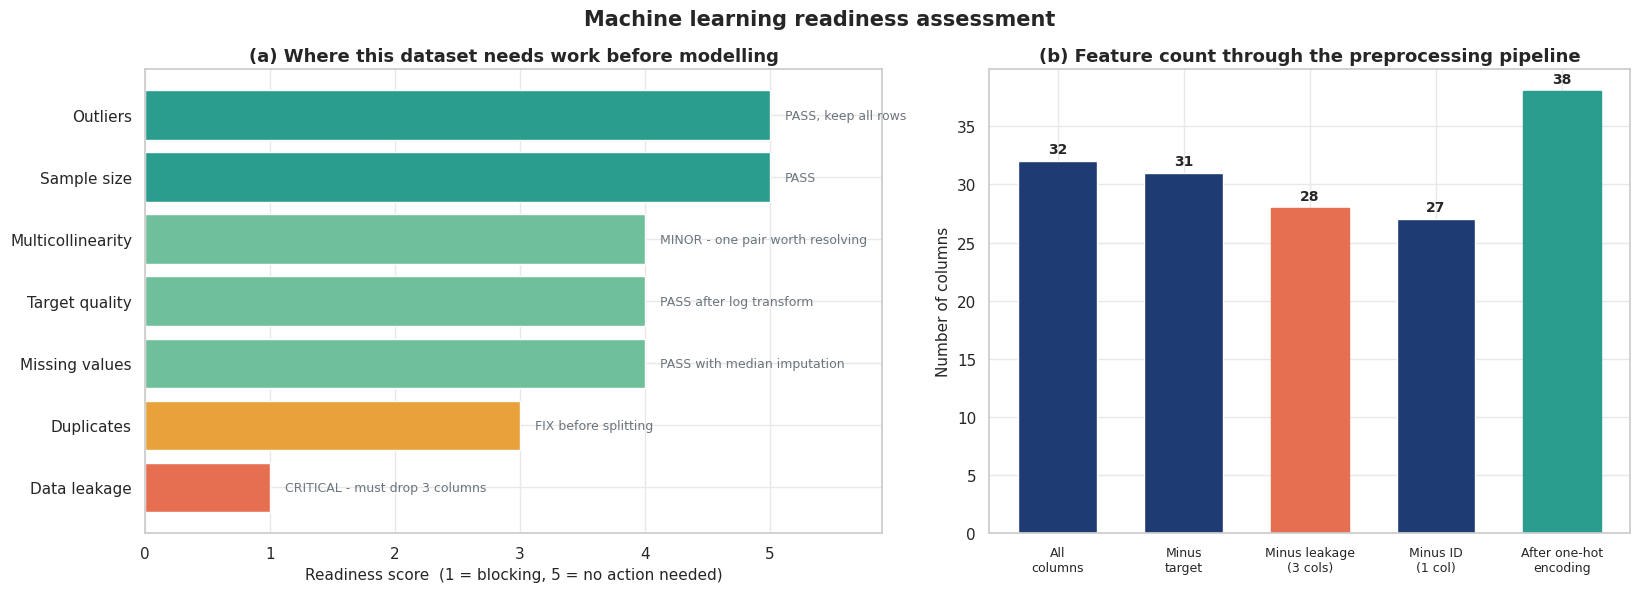

In [51]:
# --- Figure: the readiness scorecard and its practical consequence -------
fig, axes = plt.subplots(1, 2, figsize=(16.5, 6),
                         gridspec_kw={"width_ratios": [1.15, 1]})

score_order = scorecard.sort_values("score")
score_colors = {1: CORAL, 2: "#E98C6B", 3: AMBER, 4: "#6FBF9B", 5: TEAL}
bars = axes[0].barh(score_order.index, score_order.score,
                    color=[score_colors[s] for s in score_order.score],
                    edgecolor="white")
axes[0].set_xlim(0, 5.9)
axes[0].set_xlabel("Readiness score  (1 = blocking, 5 = no action needed)")
axes[0].set_title("(a) Where this dataset needs work before modelling")
for bar, (criterion, row) in zip(bars, score_order.iterrows()):
    axes[0].text(row.score + 0.12, bar.get_y() + bar.get_height() / 2,
                 row.verdict, va="center", fontsize=9, color=SLATE)

# (b) How many columns survive each preprocessing filter. Building the counts
#     step by step (rather than hard-coding them) keeps this honest.
n_all_columns = df.shape[1]
n_after_target = n_all_columns - 1
n_after_leakage = n_after_target - len(LEAKAGE_COLS)
n_after_identifier = n_after_leakage - 1          # drop CustomerID

# One-hot expansion: each categorical becomes (levels - 1) dummy columns.
n_dummy_columns = sum(df[c].nunique() - 1 for c in categorical_cols)
n_after_encoding = n_after_identifier - len(categorical_cols) + n_dummy_columns

pipeline_stages = ["All\ncolumns", "Minus\ntarget", "Minus leakage\n(3 cols)",
                   "Minus ID\n(1 col)", "After one-hot\nencoding"]
pipeline_counts = [n_all_columns, n_after_target, n_after_leakage,
                   n_after_identifier, n_after_encoding]

bars = axes[1].bar(range(len(pipeline_stages)), pipeline_counts, color=NAVY,
                   edgecolor="white", width=0.62)
bars[2].set_color(CORAL)     # the leakage step, the one that matters most
bars[-1].set_color(TEAL)
axes[1].set_xticks(range(len(pipeline_stages)))
axes[1].set_xticklabels(pipeline_stages, fontsize=9)
axes[1].set_ylabel("Number of columns")
axes[1].set_title("(b) Feature count through the preprocessing pipeline")
for i, count in enumerate(pipeline_counts):
    axes[1].text(i, count + 0.7, str(count), ha="center", fontweight="bold")

fig.suptitle("Machine learning readiness assessment", fontsize=15,
             fontweight="bold")
save_fig("18_ml_readiness")
plt.show()

# 12. Machine Learning Readiness

### What are we doing?

We now bring the EDA decisions together. The question is whether the dataset is ready for supervised regression and what the preprocessing pipeline must do before training.


# 13. Business Insights

### What are we doing?

The EDA also gives us a business view of the simulated customer population. These findings are associations in synthetic data, not causal claims about real customers.


In [52]:
# --- Segment the book by income, the most natural business cut ------------
# We work on a copy so the original `df` stays untouched for later cells.
business = df.copy()
business["IncomeQuintile"] = pd.qcut(
    business.AnnualSalary, 5,
    labels=["Q1 (lowest)", "Q2", "Q3", "Q4", "Q5 (highest)"])

# A named helper makes the intent obvious in the aggregation below. Writing it
# out is clearer than an inline lambda that a reader has to decode.
def pct_with_no_emergency_fund(emergency_fund_values):
    "Share of a group holding exactly zero emergency savings."
    return (emergency_fund_values == 0).mean() * 100


quintile_view = business.groupby("IncomeQuintile", observed=True).agg(
    customers=("CustomerID", "size"),
    median_salary=("AnnualSalary", "median"),
    median_savings_rate=("SavingsRate", "median"),
    pct_no_emergency_fund=("EmergencyFund", pct_with_no_emergency_fund),
    pct_on_track=("RetirementReady", "mean"),
    median_expected_fund=(TARGET, "median"),
    median_funding_gap=("Funding_Gap", "median"),
)
quintile_view["pct_on_track"] *= 100
quintile_view.round(2)

,customers,median_salary,median_savings_rate,pct_no_emergency_fund,pct_on_track,median_expected_fund,median_funding_gap
IncomeQuintile,,,,,,,
Q1 (lowest),5906,"48,660.6500",0.0500,38.3000,17.4200,"1,031,102.7600","-1,034,368.0300"
Q2,5905,"92,342.6100",0.0700,4.6600,35.8200,"2,431,123.5000","-537,705.0100"
Q3,5906,"127,127.3500",0.0800,1.1300,49.3600,"3,392,091.7300","-34,490.3900"
Q4,5905,"165,136.9800",0.1000,0.1000,59.8000,"4,474,059.5500","505,317.6100"
Q5 (highest),5906,"227,655.3400",0.1200,0.0300,73.3200,"6,662,475.7800","1,578,177.5500"


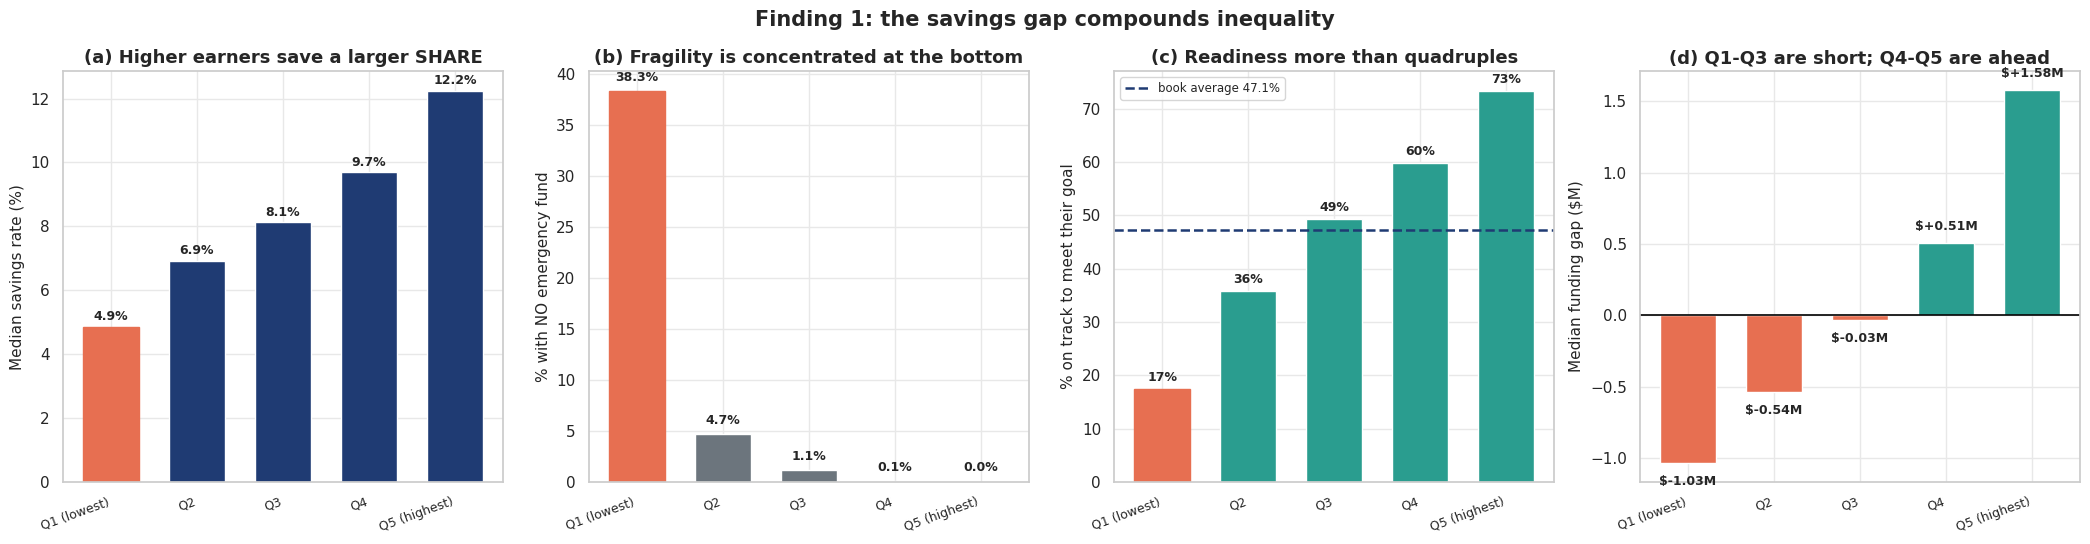

In [53]:
# --- Figure: the savings gap across the income distribution --------------
fig, axes = plt.subplots(1, 4, figsize=(21, 5.5))
quintile_labels = list(quintile_view.index)
x_positions = np.arange(len(quintile_labels))

# (a) Savings RATE rises with income - the regressive pattern.
bars = axes[0].bar(x_positions, quintile_view.median_savings_rate * 100,
                   color=NAVY, edgecolor="white", width=0.65)
bars[0].set_color(CORAL)
axes[0].set_ylabel("Median savings rate (%)")
axes[0].set_title("(a) Higher earners save a larger SHARE")
for i, value in enumerate(quintile_view.median_savings_rate * 100):
    axes[0].text(i, value + 0.2, f"{value:.1f}%", ha="center",
                 fontweight="bold", fontsize=9)

# (b) Emergency fund coverage - financial fragility.
bars = axes[1].bar(x_positions, quintile_view.pct_no_emergency_fund,
                   color=SLATE, edgecolor="white", width=0.65)
bars[0].set_color(CORAL)
axes[1].set_ylabel("% with NO emergency fund")
axes[1].set_title("(b) Fragility is concentrated at the bottom")
for i, value in enumerate(quintile_view.pct_no_emergency_fund):
    axes[1].text(i, value + 1, f"{value:.1f}%", ha="center",
                 fontweight="bold", fontsize=9)

# (c) Retirement readiness.
bars = axes[2].bar(x_positions, quintile_view.pct_on_track, color=TEAL,
                   edgecolor="white", width=0.65)
bars[0].set_color(CORAL)
axes[2].axhline(df.RetirementReady.mean() * 100, color=NAVY, ls="--", lw=1.8,
                label=f"book average {df.RetirementReady.mean()*100:.1f}%")
axes[2].set_ylabel("% on track to meet their goal")
axes[2].set_title("(c) Readiness more than quadruples")
axes[2].legend(fontsize=8.5)
for i, value in enumerate(quintile_view.pct_on_track):
    axes[2].text(i, value + 1.5, f"{value:.0f}%", ha="center",
                 fontweight="bold", fontsize=9)

# (d) The funding gap in dollars - the most actionable framing.
gap_colors = np.where(quintile_view.median_funding_gap >= 0, TEAL, CORAL)
axes[3].bar(x_positions, quintile_view.median_funding_gap / 1e6,
            color=gap_colors, edgecolor="white", width=0.65)
axes[3].axhline(0, color="black", lw=1.2)
axes[3].set_ylabel("Median funding gap ($M)")
axes[3].set_title("(d) Q1-Q3 are short; Q4-Q5 are ahead")
for i, value in enumerate(quintile_view.median_funding_gap / 1e6):
    offset = 0.09 if value >= 0 else -0.15
    axes[3].text(i, value + offset, f"${value:+.2f}M", ha="center",
                 fontweight="bold", fontsize=9)

for ax in axes:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(quintile_labels, rotation=20, ha="right", fontsize=9)

fig.suptitle("Finding 1: the savings gap compounds inequality",
             fontsize=15, fontweight="bold")
save_fig("19_savings_gap_by_income")
plt.show()

## Finding 1 — The Savings Gap Increases Across Income Levels

### What the data shows

Retirement readiness differs substantially across income groups.

Customers in the highest income quintile not only earn considerably more than those in the lowest quintile, but also save a larger proportion of their income. The combination of higher earnings and higher saving rates produces a large difference in long-term retirement outcomes.

| | Q1 (Lowest) | Q5 (Highest) | Difference |
|---|---:|---:|---:|
| Median Annual Salary | USD 48,661 | USD 227,655 | 4.7× |
| Median Savings Rate | 4.9% | 12.2% | 2.5× |
| Customers with No Emergency Fund | 38.3% | 0.03% | — |
| Retirement Ready | 17.4% | 73.3% | 4.2× |
| Median Expected Retirement Fund | USD 1.03M | USD 6.66M | 6.5× |
| Median Funding Gap | −USD 1.03M | +USD 1.58M | — |

### What we learned

The data suggests that retirement readiness is influenced by both income and saving behaviour.

Higher-income customers generally save a larger percentage of their income, accumulate larger emergency funds, and are considerably more likely to achieve their retirement goals.

One particularly notable observation is the difference in emergency savings. More than one-third of customers in the lowest income quintile have no emergency fund, whereas this situation is almost nonexistent among the highest-income group. Although this dataset is synthetic, the pattern illustrates how limited financial reserves may reduce long-term financial resilience.

The funding gap also changes substantially across income groups. Median customers in the lowest quintile remain more than USD 1 million below their retirement goal, while customers in the highest quintile exceed their target by approximately USD 1.6 million.

### ML takeaway

These results suggest that income-related variables capture important differences in retirement outcomes.

They also indicate that model performance should be evaluated across different customer groups rather than relying solely on an overall error metric. Reporting model performance by income quintile will help determine whether the model performs consistently across customers with different financial profiles.


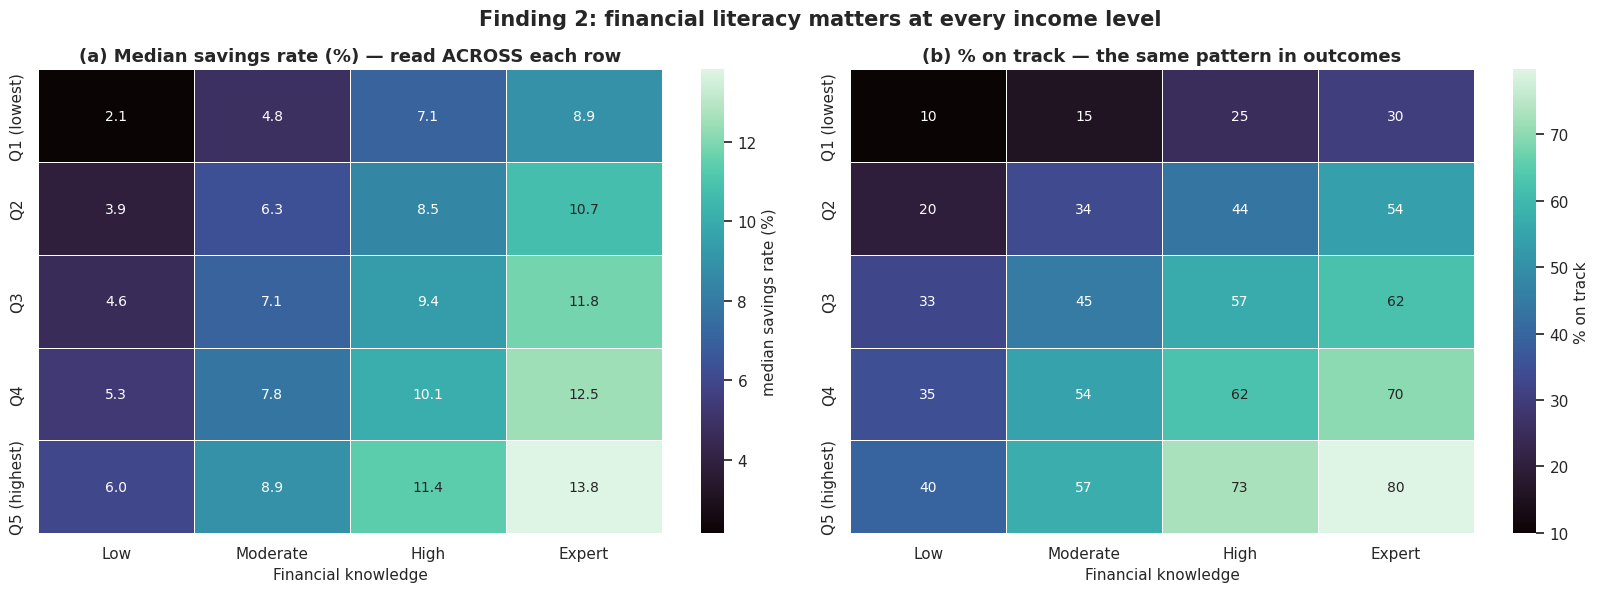

In [54]:
# --- Figure: does financial literacy matter, or is it just income? -------
# The obvious objection to "literacy predicts outcomes" is that Expert
# customers simply earn more. We test it by comparing literacy levels WITHIN
# each income quintile - if the effect survives, it is not just an income proxy.
knowledge_order = ["Low", "Moderate", "High", "Expert"]

savings_by_knowledge = business.pivot_table(
    index="IncomeQuintile", columns="FinancialKnowledge",
    values="SavingsRate", aggfunc="median", observed=True)[knowledge_order]

readiness_by_knowledge = business.pivot_table(
    index="IncomeQuintile", columns="FinancialKnowledge",
    values="RetirementReady", aggfunc="mean", observed=True)[knowledge_order]

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6))

sns.heatmap(savings_by_knowledge * 100, annot=True, fmt=".1f",
            cmap=SEQUENTIAL_CMAP, ax=axes[0], linewidths=0.6,
            cbar_kws={"label": "median savings rate (%)"})
axes[0].set_title("(a) Median savings rate (%) — read ACROSS each row")
axes[0].set_xlabel("Financial knowledge")
axes[0].set_ylabel("")

sns.heatmap(readiness_by_knowledge * 100, annot=True, fmt=".0f",
            cmap=SEQUENTIAL_CMAP, ax=axes[1], linewidths=0.6,
            cbar_kws={"label": "% on track"})
axes[1].set_title("(b) % on track — the same pattern in outcomes")
axes[1].set_xlabel("Financial knowledge")
axes[1].set_ylabel("")

fig.suptitle("Finding 2: financial literacy matters at every income level",
             fontsize=15, fontweight="bold")
save_fig("20_literacy_effect")
plt.show()

## Finding 2 — Financial Knowledge Is Associated with Better Retirement Outcomes

### What the data shows

Customers with higher levels of financial knowledge consistently achieve stronger retirement outcomes.

At first glance, this relationship could simply reflect differences in income. Customers classified as **Expert** earn considerably more than those with **Low** financial knowledge.

However, the relationship remains visible even after controlling for income.

Within the **lowest income quintile**, Expert customers save **8.9%** of their income compared with **2.2%** for customers with Low financial knowledge—a difference of more than four times among customers with similar earnings.

The same pattern appears across every income quintile, indicating that financial knowledge is associated with stronger saving behaviour regardless of income level.

### What we learned

The data suggests that retirement readiness depends not only on how much customers earn, but also on how they manage their finances.

Customers with greater financial knowledge consistently save a larger proportion of their income and are more likely to reach their retirement goals.

This matters because this analysis identifies an association rather than a causal relationship. Customers with stronger financial habits may naturally consider themselves more financially knowledgeable, making the direction of causality impossible to determine from this dataset alone.

### ML takeaway

FinancialKnowledge provides useful predictive information beyond income alone and should be retained as an important feature during model development.

The observed relationship also suggests that interaction effects between FinancialKnowledge and income-related variables may improve model performance.

### Business takeaway

Unlike age or income, financial knowledge is potentially modifiable.

Although this synthetic dataset cannot demonstrate causality, it illustrates how financial education initiatives may improve long-term retirement readiness, particularly among lower-income customers where the differences are most pronounced.


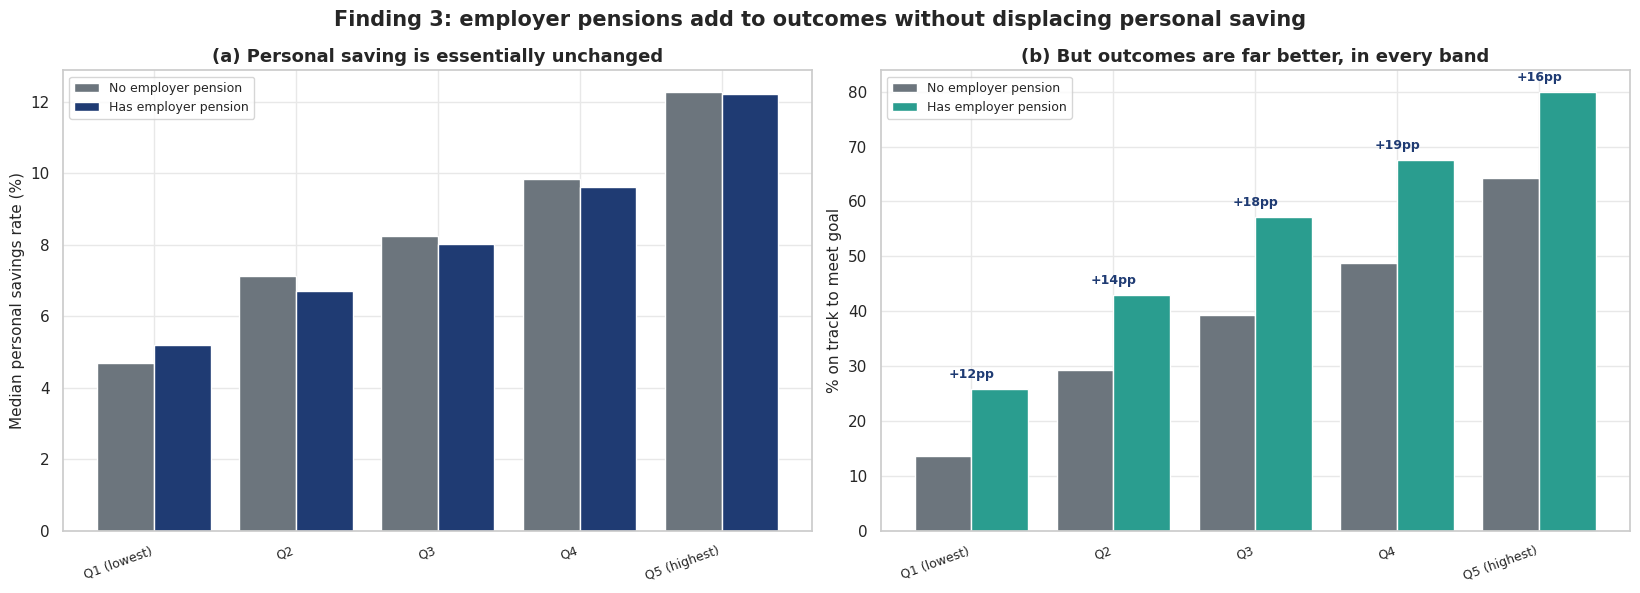

In [55]:
# --- Figure: the employer pension effect ---------------------------------
# Same within-quintile method as Finding 2, applied to pension access.
savings_by_pension = business.pivot_table(
    index="IncomeQuintile", columns="EmployerPension",
    values="SavingsRate", aggfunc="median", observed=True)
readiness_by_pension = business.pivot_table(
    index="IncomeQuintile", columns="EmployerPension",
    values="RetirementReady", aggfunc="mean", observed=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(16.5, 6))
x_positions = np.arange(len(savings_by_pension))

axes[0].bar(x_positions - 0.2, savings_by_pension["No"] * 100, 0.4,
            label="No employer pension", color=SLATE, edgecolor="white")
axes[0].bar(x_positions + 0.2, savings_by_pension["Yes"] * 100, 0.4,
            label="Has employer pension", color=NAVY, edgecolor="white")
axes[0].set_ylabel("Median personal savings rate (%)")
axes[0].set_title("(a) Personal saving is essentially unchanged")
axes[0].legend(fontsize=9)

axes[1].bar(x_positions - 0.2, readiness_by_pension["No"], 0.4,
            label="No employer pension", color=SLATE, edgecolor="white")
axes[1].bar(x_positions + 0.2, readiness_by_pension["Yes"], 0.4,
            label="Has employer pension", color=TEAL, edgecolor="white")
axes[1].set_ylabel("% on track to meet goal")
axes[1].set_title("(b) But outcomes are far better, in every band")
axes[1].legend(fontsize=9)
for i in range(len(x_positions)):
    gap = readiness_by_pension["Yes"].iloc[i] - readiness_by_pension["No"].iloc[i]
    height = max(readiness_by_pension["Yes"].iloc[i],
                 readiness_by_pension["No"].iloc[i])
    axes[1].text(i, height + 2, f"+{gap:.0f}pp", ha="center",
                 fontweight="bold", fontsize=9, color=NAVY)

for ax in axes:
    ax.set_xticks(x_positions)
    ax.set_xticklabels(savings_by_pension.index, rotation=20, ha="right",
                       fontsize=9)

fig.suptitle("Finding 3: employer pensions add to outcomes without "
             "displacing personal saving", fontsize=15, fontweight="bold")
save_fig("21_pension_effect")
plt.show()

## Finding 3 — Employer Pension Plans Improve Retirement Outcomes

### What the data shows

Customers with employer-sponsored pension plans consistently achieve higher projected retirement outcomes than customers without pensions.

Interestingly, personal savings rates remain remarkably similar between the two groups across every income quintile.

Differences in savings rates never exceed half a percentage point, suggesting that pension participation does not substantially reduce personal saving behaviour within this dataset.

At the same time, retirement readiness is consistently higher among customers with employer pensions, particularly within the lower and middle income groups.

### What we learned

The results indicate that employer pension plans complement rather than replace personal retirement savings.

Instead of reducing individual saving behaviour, pension contributions appear to provide additional retirement wealth while customers continue saving at similar rates.

Because this is an observational synthetic dataset, the analysis cannot determine whether pensions directly cause better retirement outcomes or simply reflect differences in employment characteristics associated with pension eligibility.

### ML takeaway

EmployerPension appears to provide meaningful predictive information that is not fully captured by income or savings rate alone.

The feature should therefore remain in the modeling dataset and may interact with employment-related variables during feature engineering.

### Business takeaway

The analysis highlights employer-sponsored pensions as an important contributor to retirement readiness.

Customers without access to pension plans may benefit more from retirement planning tools that encourage additional voluntary contributions, while customers with pensions may require different planning strategies.


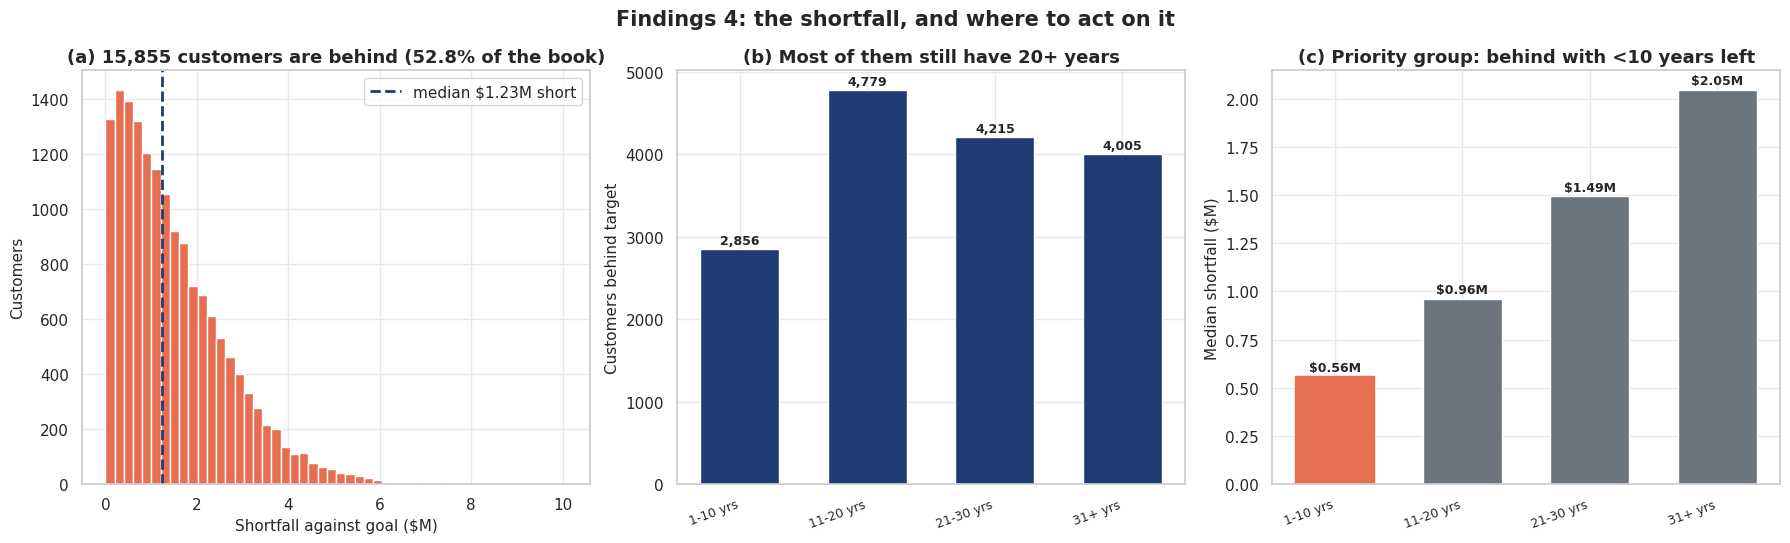

In [66]:
# --- Figure: who is behind, by how much, and where to intervene ---------
not_on_track = df[df.RetirementReady == 0]
shortfall = -not_on_track.Funding_Gap        # positive dollars short

# Build the horizon banding again on the business copy, so this figure is
# self-contained and does not depend on Section 9 having run.
business["YearsUntilRetirement"] = (business.DesiredRetirementAge - business.Age)
business["HorizonBand"] = pd.cut(
    business.YearsUntilRetirement, bins=[0, 10, 20, 30, 50],
    labels=["1-10 yrs", "11-20 yrs", "21-30 yrs", "31+ yrs"])

behind = business[business.RetirementReady == 0]
behind_by_horizon = behind.groupby("HorizonBand", observed=True).agg(
    customers=("CustomerID", "size"),
    median_shortfall=("Funding_Gap", "median"),
)
behind_by_horizon["median_shortfall"] *= -1     # express as a positive shortfall

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# (a) How big is the shortfall for those who are behind?
axes[0].hist(shortfall / 1e6, bins=50, color=CORAL, edgecolor="white")
axes[0].axvline(shortfall.median() / 1e6, color=NAVY, ls="--", lw=2,
                label=f"median ${shortfall.median()/1e6:.2f}M short")
axes[0].set_xlabel("Shortfall against goal ($M)")
axes[0].set_ylabel("Customers")
axes[0].set_title(f"(a) {len(not_on_track):,} customers are behind "
                  f"({len(not_on_track)/len(df)*100:.1f}% of the book)")
axes[0].legend()

# (b) Where do they sit on the retirement horizon?
axes[1].bar(range(len(behind_by_horizon)), behind_by_horizon.customers,
            color=NAVY, edgecolor="white", width=0.62)
axes[1].set_xticks(range(len(behind_by_horizon)))
axes[1].set_xticklabels(behind_by_horizon.index, rotation=20, ha="right",
                        fontsize=9)
axes[1].set_ylabel("Customers behind target")
axes[1].set_title("(b) Most of them still have 20+ years")
for i, count in enumerate(behind_by_horizon.customers):
    axes[1].text(i, count + 60, f"{count:,}", ha="center", fontweight="bold",
                 fontsize=9)

# (c) The urgent group: behind AND close to retirement.
bars = axes[2].bar(range(len(behind_by_horizon)),
                   behind_by_horizon.median_shortfall / 1e6,
                   color=SLATE, edgecolor="white", width=0.62)
bars[0].set_color(CORAL)     # 1-10 yrs = least time to recover
axes[2].set_xticks(range(len(behind_by_horizon)))
axes[2].set_xticklabels(behind_by_horizon.index, rotation=20, ha="right",
                        fontsize=9)
axes[2].set_ylabel("Median shortfall ($M)")
axes[2].set_title("(c) Priority group: behind with <10 years left")
for i, value in enumerate(behind_by_horizon.median_shortfall / 1e6):
    axes[2].text(i, value + 0.03, f"${value:.2f}M", ha="center",
                 fontweight="bold", fontsize=9)

fig.suptitle("Findings 4: the shortfall, and where to act on it",
             fontsize=15, fontweight="bold")
save_fig("22_business_insights")
plt.show()

## Finding 4— Retirement Readiness Varies Significantly Across Customer Groups

### What the data shows

Approximately **53% of customers** are projected to fall short of their retirement goal.

However, this headline figure should be interpreted carefully.

Many customers identified as "not ready" are still decades away from retirement and therefore have substantial time to increase contributions and accumulate additional wealth.

A much smaller group—customers who remain behind schedule while approaching retirement—represents the highest-priority population for intervention.

### What we learned

Retirement readiness should not be interpreted as a binary measure of financial success or failure.

Instead, it reflects progress toward a long-term financial objective at a specific point in time.

Customers early in their careers naturally have lower accumulated wealth and therefore lower readiness scores despite having many years remaining to improve their position.

By contrast, customers approaching retirement with persistent funding gaps have significantly less time to recover and therefore represent a higher level of financial risk.

### ML takeaway

Overall performance metrics should be supplemented with evaluation across different retirement horizon groups.

Reporting prediction error by years remaining until retirement will provide a more complete understanding of model performance across customers at different stages of their financial journey.

### Business takeaway

Rather than applying identical recommendations to every customer, retirement planning strategies should reflect each customer's stage of the retirement journey.

Customers with long investment horizons may benefit most from consistent saving habits and financial education, while customers approaching retirement may require targeted contribution strategies designed to reduce remaining funding gaps.


# 14. Executive Summary

### What should you take from the EDA?

The points below are the decisions and limitations that should carry directly into the preprocessing and modeling stages.

## Overview

This analysis shows that the dataset is well suited for developing a supervised machine learning model to predict a customer's **Expected Retirement Fund**.

The dataset combines realistic demographic, financial, and behavioral information for 30,000 synthetic pre-retirement customers and provides sufficient signal, diversity, and scale for predictive modeling. While several preprocessing steps are required before training, no structural issues were identified that prevent successful model development.

---

## Key Findings

### Data Quality

- The dataset contains **30,000 observations** and **32 features** with excellent overall completeness.
- Missing values are limited, appear consistent with a **Missing Completely At Random (MCAR)** mechanism, and can be handled using standard imputation techniques.
- A small number of duplicate records were intentionally included and should be removed before splitting the data into training and testing sets.
- No significant integrity issues were identified within the final dataset.

---

### Machine Learning Insights

Several important findings will directly influence model development:

- **Target leakage** is the most important risk in the dataset. `Funding_Gap`, `Readiness_Score`, and `RetirementReady` are all derived from the prediction target and must be excluded from model training.
- Financial capacity and saving behaviour are considerably stronger predictors of retirement outcomes than age alone.
- The relationship between age and retirement outcomes is clearly non-linear, suggesting that tree-based algorithms or engineered non-linear features are likely to outperform simple linear models.
- Multicollinearity is limited and unlikely to present significant challenges for most modern machine learning algorithms.
- The dataset contains meaningful opportunities for feature engineering, particularly through financial ratios and retirement planning metrics.

---

### Business Insights

The exploratory analysis highlights several important financial patterns:

- Customers with stronger saving habits consistently project better retirement outcomes regardless of income level.
- Financial knowledge is associated with improved retirement readiness, suggesting that behavioural factors play an important role alongside income and accumulated wealth.
- Emergency savings and long-term investment balances are among the strongest indicators of future retirement success.
- Retirement readiness improves steadily as customers accumulate assets and progress through their working careers.

Although these findings are based on a synthetic dataset, they provide realistic scenarios for developing and evaluating predictive retirement planning models.

---

## Strengths of the Dataset

The dataset provides several advantages for machine learning development:

- Large sample size with diverse customer profiles.
- Consistent business definition of the prediction target.
- High-quality continuous regression target.
- Limited redundancy between predictor variables.
- Manageable missing values and duplicate records.
- Rich combination of demographic, financial, and behavioural features.
- Suitable complexity for comparing both linear and non-linear machine learning models.

---

## Limitations

Several considerations should be kept in mind throughout the modeling phase:

- This synthetic dataset was designed for educational and portfolio purposes and should not be interpreted as representative of any real customer population.
- Target leakage variables must be removed before training.
- Duplicate observations should be removed prior to creating training and testing datasets.
- Some variables may contribute little predictive value and should be evaluated during feature selection.
- Feature engineering is expected to improve predictive performance beyond the original variables alone.

---

## Recommended Preprocessing Workflow

Based on the findings of this notebook, the preprocessing pipeline should include:

1. Remove duplicate records.
2. Separate machine learning features from business KPIs.
3. Split the dataset into training and testing sets.
4. Handle missing values using training-only imputation.
5. Engineer additional financial and retirement-planning features.
6. Encode categorical variables.
7. Apply feature scaling where required.
8. Evaluate target transformation for regression.
9. Build a reproducible preprocessing pipeline using scikit-learn.

---

## Final Assessment

**The dataset is ready for supervised machine learning.**

After removing target leakage variables and performing the recommended preprocessing steps, the dataset provides an excellent foundation for developing and comparing multiple regression models.

The exploratory analysis identified meaningful predictive structure, manageable data quality challenges, and several promising opportunities for feature engineering. Together, these findings establish a clear roadmap for the next stage of the project: building, evaluating, and optimizing machine learning models capable of predicting retirement outcomes with strong accuracy and business relevance.


# 15. Key Considerations Before Model Development

### What should you take from the EDA?

The points below are the decisions and limitations that should carry directly into the preprocessing and modeling stages.

The exploratory analysis confirms that the dataset is suitable for supervised machine learning. Before training the first model, however, several important considerations should guide the preprocessing pipeline, feature engineering, model selection, and evaluation strategy.

These are not unresolved problems with the dataset. Rather, they are design decisions that should be addressed explicitly during the next stage of the project.

---

## 1. Exclude Business KPIs from Model Training

The variables:

- `Funding_Gap`
- `Readiness_Score`
- `RetirementReady`

are deterministic transformations of the prediction target.

Although they are valuable business metrics for reporting customer outcomes, they contain information derived directly from the target and therefore introduce severe target leakage.

**Action:** Remove these columns from the machine learning feature set while retaining them for post-prediction business reporting.

---

## 2. Re-evaluate Low-Information Features

Not every available feature contributes meaningful predictive information.

For example, `ExpectedInflation` exhibits almost no measurable relationship with the target in the current dataset. During preprocessing and model development, its predictive value should be evaluated before deciding whether to retain or remove it.

Feature selection should be driven by validation performance rather than assumptions.

---

## 3. Engineer Additional Financial Features

The EDA identified several opportunities for feature engineering.

Examples include:

- Years until retirement
- Annual retirement contribution
- Debt-to-income ratio
- Net savings after expenses
- Real expected investment return (ExpectedAnnualReturn − ExpectedInflation)

These engineered variables may capture financial relationships more effectively than the original features alone.

---

## 4. Evaluate Non-Linear Relationships

Several variables—particularly **Age**—demonstrate clear non-linear relationships with the target.

This suggests that tree-based algorithms (such as Random Forest or Gradient Boosting) may outperform simple linear regression unless appropriate non-linear terms are engineered.

Model comparison will therefore be an important part of the next stage.

---

## 5. Consider the Effects of Synthetic Data

This dataset was intentionally generated to simulate realistic retirement planning scenarios while remaining suitable for machine learning education.

As a result, some relationships reflect assumptions built into the data generation process rather than naturally occurring market behaviour.

Any business conclusions should therefore be interpreted as insights about this simulated environment rather than universal characteristics of retirement planning.

---

## 6. Investigate the Impact of Feature Limits

Several financial variables contain realistic upper limits introduced during data generation.

Although these limits affect only a small proportion of customers, they may influence model behaviour for high-income or high-net-worth individuals.

Future work may evaluate whether explicit indicators for capped values improve predictive performance.

---

## 7. Select Appropriate Evaluation Metrics

The target variable exhibits a positively skewed distribution.

If a logarithmic transformation is applied during model training, evaluation metrics should be interpreted carefully because optimization in log space emphasizes relative (percentage) error rather than absolute dollar error.

To provide a balanced assessment, model performance should be reported using multiple evaluation metrics, including:

- RMSE
- MAE
- MAPE
- R²

---

## Transition to Data Preprocessing

The exploratory analysis confirms that the dataset is well suited for supervised regression after a small number of preprocessing steps.

The next notebook will focus on:

- Removing duplicate records
- Separating machine learning features from business KPIs
- Handling missing values
- Encoding categorical variables
- Engineering additional predictive features
- Building a reproducible preprocessing pipeline using scikit-learn

Once these steps are complete, the dataset will be ready for model training, validation, and model comparison.
